# PPO Portfolio Optimization: Multiple Synthetic Models vs Real Data

This experiment isolates the effect of the **training data source**:

- One control policy trains on the real 2024 price path.
- One synthetic-only policy trains on each generated dataset under
  `data/synthetic/<dataset_slug>/path*.csv`.
- One real + synthetic policy is added for each generation model. At every
  episode it samples the real source or that model's synthetic source with
  equal probability, without duplicating either dataset.
- Every policy selects its checkpoint using the same real 2024 validation period.
- Every policy is evaluated once on untouched real 2025 data.
- The final backtest compares all PPO policies with the Demo notebook's uniform
  buy-and-hold baseline.

The notebook reads every dataset from CSV. It does not download or generate market
data, and it does not use the older 2011–2022 split.


## Experimental protocol

The default date boundaries use half-open intervals `[start, end)`:

| Block | Default period | Purpose |
|---|---|---|
| Train | 2024-01-01 to 2024-10-01 | Fit each policy and source-specific scaler |
| Validation | 2024-10-01 to 2025-01-01 | Select every checkpoint on real data |
| Test | 2025-01-01 to 2026-01-01 | Final real out-of-sample comparison |

With `M` generation models, the formal matrix contains
`(1 real control + M synthetic-only + M real+synthetic) × 2 commission settings × 3 seeds`.
`RUN_MODE="smoke"` is the safe default; switch to `"full"` only after checking the
discovered-model, data, and scaling summaries.


In [1]:
from __future__ import annotations

import glob
import hashlib
import json
import os
import random
import re
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import stable_baselines3 as sb3
import torch as th
import torch.nn as nn
from matplotlib.lines import Line2D
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import BaseCallback, CallbackList
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
from tqdm.auto import tqdm


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "finrl").is_dir() and (candidate / "examples").is_dir():
            return candidate
    raise RuntimeError("Could not locate the FinRL project root.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from training_cache_fingerprint import (
    TRAINING_DATA_FINGERPRINT_SCHEMA,
    fingerprint_training_sources,
)

from finrl.meta.env_portfolio_optimization.env_portfolio_multipath import MultiPathEnv
from finrl.meta.env_portfolio_optimization.env_portfolio_optimization_gymnasium import (
    PortfolioOptimizationGymnasiumEnv,
)

warnings.filterwarnings("once")
DEVICE = "cpu"
th.set_num_threads(1)
print("project root:", PROJECT_ROOT)
print("device:", DEVICE)


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


project root: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp
device: cpu


## 1. Configuration

Adjust paths and date boundaries only in this cell. Environment variables with the
`FINRL_` prefix can override paths and run mode for automated smoke tests.


In [2]:
REAL_DATA_GLOB = os.getenv(
    "FINRL_REAL_DATA_GLOB", "data/real/*.csv"
)
SYNTHETIC_ROOT = os.getenv(
    "FINRL_SYNTHETIC_ROOT", "data/synthetic"
)
ARTIFACT_DIR = os.getenv(
    "FINRL_ARTIFACT_DIR", "results/ppo_synthetic_vs_real"
)

# All intervals are [start, end): start is included and end is excluded.
TRAIN_START = "2024-01-01"
TRAIN_END = "2024-10-01"
VAL_START = "2024-10-01"
VAL_END = "2025-01-01"
TEST_START = "2025-01-01"
TEST_END = "2026-01-01"

EXPECTED_TICKERS = ["AAPL", "AMZN", "GOOGL", "MSFT", "NVDA"]
PRICE_COLUMNS = ["close", "high", "low"]
REQUIRED_COLUMNS = ["date", "tic", *PRICE_COLUMNS]
SYNTHETIC_MODEL_LABELS = {
    "armd__single_path": "ARMD (single path)",
    "cndiff__50_paths": "CN-Diff (50 paths)",
    "dva__mean_of_50_paths": "DVA (mean of 50 paths)",
    "dva__50_paths": "DVA (50 paths)",
    "nsdiff__50_paths": "NS-Diff (50 paths)",
}


def synthetic_model_label(model_name: str) -> str:
    return SYNTHETIC_MODEL_LABELS[model_name]


def training_group_label(group: str) -> str:
    if group == "real_trained":
        return "Real data (2024)"
    real_synthetic_prefix = "real_synthetic::"
    if group.startswith(real_synthetic_prefix):
        model_name = group[len(real_synthetic_prefix):]
        return f"Real + {synthetic_model_label(model_name)}"
    prefix = "synthetic::"
    if group.startswith(prefix):
        return synthetic_model_label(group[len(prefix):])
    return group

TIME_WINDOW = 50
INITIAL_AMOUNT = 100_000
REWARD_SCALING = 100

RUN_MODE = os.getenv("FINRL_RUN_MODE", "smoke").lower()
# RUN_MODE = 'full'
RUN_SETTINGS = {
    "smoke": {
        "seeds": [0, 1],
        "total_timesteps": 4_096,
        "eval_freq": 2_048,
    },
    "full": {
        "seeds": [0, 1, 2],
        "total_timesteps": 200_000,
        "eval_freq": 20_000,
    },
}
if RUN_MODE not in RUN_SETTINGS:
    raise ValueError(f"RUN_MODE must be one of {sorted(RUN_SETTINGS)}, got {RUN_MODE!r}")

SEEDS = RUN_SETTINGS[RUN_MODE]["seeds"]
TOTAL_TIMESTEPS = RUN_SETTINGS[RUN_MODE]["total_timesteps"]
EVAL_FREQ = RUN_SETTINGS[RUN_MODE]["eval_freq"]
COMMISSION_CONFIGS = {
    "no_fee": 0.0,
    "with_fee": 0.0025,
}
MAX_TRAIN_EVALUATION_PATHS = 3
MAX_SYNTH_VALIDATION_PATHS = 3


def env_flag(name: str, default: bool) -> bool:
    raw = os.getenv(name)
    if raw is None:
        return default
    if raw.lower() in {"1", "true", "yes", "on"}:
        return True
    if raw.lower() in {"0", "false", "no", "off"}:
        return False
    raise ValueError(f"{name} must be a boolean flag, got {raw!r}")


USE_TRAIN_CACHE = env_flag("FINRL_USE_TRAIN_CACHE", True)
FORCE_RETRAIN = env_flag("FINRL_FORCE_RETRAIN", False)


def resolve_project_path(value: str) -> Path:
    path = Path(value).expanduser()
    return path.resolve() if path.is_absolute() else (PROJECT_ROOT / path).resolve()


REAL_DATA_PATTERN = str(resolve_project_path(REAL_DATA_GLOB))
SYNTHETIC_ROOT_PATH = resolve_project_path(SYNTHETIC_ROOT)
ARTIFACT_ROOT = resolve_project_path(ARTIFACT_DIR)
OUTPUT_ROOT = ARTIFACT_ROOT / RUN_MODE
TRAIN_CACHE_ROOT = ARTIFACT_ROOT / "train_cache"
BASE_EXPERIMENT_CONFIG = {
    "train": [TRAIN_START, TRAIN_END],
    "validation": [VAL_START, VAL_END],
    "test": [TEST_START, TEST_END],
    "tickers": EXPECTED_TICKERS,
    "time_window": TIME_WINDOW,
    "run_mode": RUN_MODE,
    "seeds": SEEDS,
    "total_timesteps": TOTAL_TIMESTEPS,
    "eval_freq": EVAL_FREQ,
    "commissions": COMMISSION_CONFIGS,
    "notebook_revision": "balanced_real_synthetic_v1",
}
print("run mode:", RUN_MODE)
print("seeds:", SEEDS)
print("timesteps per run:", f"{TOTAL_TIMESTEPS:,}")
print("real per-ticker pattern:", REAL_DATA_PATTERN)
print("synthetic model root:", SYNTHETIC_ROOT_PATH)
print("output base:", OUTPUT_ROOT)
print("training cache:", "enabled" if USE_TRAIN_CACHE else "disabled")
print("force retrain:", FORCE_RETRAIN)
print("training cache root:", TRAIN_CACHE_ROOT)


run mode: smoke
seeds: [0, 1]
timesteps per run: 4,096
real per-ticker pattern: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/data/real/*.csv
synthetic model root: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/data/synthetic
output base: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke
training cache: enabled
force retrain: False
training cache root: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/train_cache


## 2. Load and validate CSV data

Real data is stored as one adjusted OHLCV CSV per ticker under `data/real/`. The
ticker is read from the filename (`AAPL.csv`, `AMZN.csv`, ...). The loader validates
OHLCV, renames columns to lowercase, adds `tic`, and combines the files into FinRL's
long format. The current policy uses `close,high,low`; adjusted open and volume are
validated but not used as observation features.

Synthetic data is grouped by generator and output representation:

```text
data/synthetic/
├── armd__single_path/path_001.csv
├── cndiff__50_paths/path00.csv
├── dva__mean_of_50_paths/path_001.csv
├── dva__50_paths/path_000.csv
└── nsdiff__50_paths/path_001.csv
```

Each `path*.csv` is one complete generated market path in
`date,tic,close,high,low` format. Folder slugs remain machine-readable, while
figures and tables use explicit labels describing single-, multi-, and mean-path data.


In [3]:
def validate_boundaries() -> None:
    points = {
        "TRAIN_START": pd.Timestamp(TRAIN_START),
        "TRAIN_END": pd.Timestamp(TRAIN_END),
        "VAL_START": pd.Timestamp(VAL_START),
        "VAL_END": pd.Timestamp(VAL_END),
        "TEST_START": pd.Timestamp(TEST_START),
        "TEST_END": pd.Timestamp(TEST_END),
    }
    if not (
        points["TRAIN_START"]
        < points["TRAIN_END"]
        <= points["VAL_START"]
        < points["VAL_END"]
        <= points["TEST_START"]
        < points["TEST_END"]
    ):
        raise ValueError(
            "Date boundaries must be chronological and non-overlapping: "
            "TRAIN_START < TRAIN_END <= VAL_START < VAL_END "
            "<= TEST_START < TEST_END."
        )


REAL_OHLCV_COLUMNS = ["Date", "Open", "High", "Low", "Close", "Volume"]


def validate_market_frame(frame: pd.DataFrame, label: str) -> pd.DataFrame:
    missing = sorted(set(REQUIRED_COLUMNS) - set(frame.columns))
    if missing:
        raise ValueError(f"{label}: missing normalized columns {missing}")
    frame = frame[REQUIRED_COLUMNS].copy()
    frame["date"] = pd.to_datetime(frame["date"], errors="raise").dt.normalize()
    frame["tic"] = frame["tic"].astype(str).str.upper()
    for column in PRICE_COLUMNS:
        frame[column] = pd.to_numeric(frame[column], errors="raise")

    actual_tickers = sorted(frame["tic"].unique())
    if actual_tickers != EXPECTED_TICKERS:
        raise ValueError(
            f"{label}: expected tickers {EXPECTED_TICKERS}, got {actual_tickers}"
        )
    if frame.duplicated(["date", "tic"]).any():
        examples = frame.loc[
            frame.duplicated(["date", "tic"], keep=False), ["date", "tic"]
        ].head()
        raise ValueError(f"{label}: duplicate date/tic rows:\n{examples}")

    numbers = frame[PRICE_COLUMNS].to_numpy(dtype=float)
    if not np.isfinite(numbers).all():
        raise ValueError(f"{label}: prices contain NaN or infinite values")
    if (numbers <= 0).any():
        raise ValueError(f"{label}: all prices must be strictly positive")

    invalid_ohlc = (frame["low"] > frame["close"]) | (
        frame["close"] > frame["high"]
    )
    if invalid_ohlc.any():
        raise ValueError(
            f"{label}: {int(invalid_ohlc.sum())} rows violate "
            "low <= close <= high"
        )

    date_sets = frame.groupby("tic", sort=True)["date"].apply(
        lambda values: frozenset(values)
    )
    if date_sets.nunique() != 1:
        counts = frame.groupby("tic")["date"].nunique().to_dict()
        raise ValueError(f"{label}: ticker date sets differ: {counts}")

    return frame.sort_values(["date", "tic"], ignore_index=True)


def read_market_csv(path: Path, label: str) -> pd.DataFrame:
    """Read one synthetic market path already in FinRL long format."""
    if not path.is_file():
        raise FileNotFoundError(f"{label}: CSV not found: {path}")
    return validate_market_frame(pd.read_csv(path), label)


def read_real_ticker_csv(path: Path) -> pd.DataFrame:
    """Read one ticker's adjusted OHLCV CSV and convert column names."""
    ticker = path.stem.upper()
    if ticker not in EXPECTED_TICKERS:
        raise ValueError(
            f"Unexpected real-data file {path.name}; ticker must be in "
            f"{EXPECTED_TICKERS}"
        )
    raw = pd.read_csv(path)
    missing = sorted(set(REAL_OHLCV_COLUMNS) - set(raw.columns))
    if missing:
        raise ValueError(f"real {ticker}: missing columns {missing}")

    raw = raw[REAL_OHLCV_COLUMNS].copy()
    raw["Date"] = pd.to_datetime(raw["Date"], errors="raise").dt.normalize()
    for column in ["Open", "High", "Low", "Close", "Volume"]:
        raw[column] = pd.to_numeric(raw[column], errors="raise")
    values = raw[["Open", "High", "Low", "Close", "Volume"]].to_numpy(
        dtype=float
    )
    if not np.isfinite(values).all():
        raise ValueError(f"real {ticker}: OHLCV contains NaN or infinity")
    if (raw[["Open", "High", "Low", "Close"]] <= 0).any().any():
        raise ValueError(f"real {ticker}: adjusted OHLC must be positive")
    if (raw["Volume"] < 0).any():
        raise ValueError(f"real {ticker}: volume must be non-negative")

    row_scale = raw[["Open", "High", "Low", "Close"]].max(axis=1).clip(lower=1)
    tolerance = row_scale * 1e-10
    lower_body = raw[["Open", "Close"]].min(axis=1)
    upper_body = raw[["Open", "Close"]].max(axis=1)
    materially_invalid = (raw["Low"] > lower_body + tolerance) | (
        raw["High"] < upper_body - tolerance
    )
    if materially_invalid.any():
        raise ValueError(
            f"real {ticker}: {int(materially_invalid.sum())} adjusted bars violate "
            "Low <= min(Open, Close) <= max(Open, Close) <= High"
        )

    # Reconcile only floating-point roundoff before the strict common validator.
    raw["Low"] = raw[["Low", "Open", "Close"]].min(axis=1)
    raw["High"] = raw[["High", "Open", "Close"]].max(axis=1)
    converted = raw.rename(
        columns={
            "Date": "date",
            "Open": "open",
            "High": "high",
            "Low": "low",
            "Close": "close",
            "Volume": "volume",
        }
    )
    converted["tic"] = ticker
    return converted[["date", "tic", "close", "high", "low"]]


def read_real_market_csvs(paths: list[Path]) -> pd.DataFrame:
    if not paths:
        raise FileNotFoundError(
            f"No per-ticker real CSV files matched {REAL_DATA_PATTERN!r}"
        )
    tickers = [path.stem.upper() for path in paths]
    if len(tickers) != len(set(tickers)):
        raise ValueError(f"Duplicate real-data ticker files: {tickers}")
    if sorted(tickers) != EXPECTED_TICKERS:
        raise ValueError(
            f"Real-data filenames must identify {EXPECTED_TICKERS}, got "
            f"{sorted(tickers)}"
        )
    combined = pd.concat(
        [read_real_ticker_csv(path) for path in paths], ignore_index=True
    )
    return validate_market_frame(combined, "real data")


def check_calendar_coverage(
    frame: pd.DataFrame, start: str, end: str, label: str
) -> None:
    dates = pd.Index(frame["date"].unique()).sort_values()
    selected = dates[(dates >= pd.Timestamp(start)) & (dates < pd.Timestamp(end))]
    if selected.empty:
        raise ValueError(f"{label}: no dates in [{start}, {end})")
    tolerance = pd.Timedelta(days=7)
    if selected.min() > pd.Timestamp(start) + tolerance:
        raise ValueError(
            f"{label}: first date {selected.min().date()} is too far after {start}"
        )
    if selected.max() < pd.Timestamp(end) - tolerance:
        raise ValueError(
            f"{label}: last date {selected.max().date()} is too far before {end}"
        )


def slice_train(
    frame: pd.DataFrame, start: str, end: str, label: str
) -> pd.DataFrame:
    selected = frame[
        (frame["date"] >= pd.Timestamp(start))
        & (frame["date"] < pd.Timestamp(end))
    ].copy()
    n_dates = selected["date"].nunique()
    if n_dates <= TIME_WINDOW:
        raise ValueError(
            f"{label}: {n_dates} dates are insufficient for TIME_WINDOW={TIME_WINDOW}"
        )
    return selected.reset_index(drop=True)


def slice_evaluation_with_lookback(
    frame: pd.DataFrame, start: str, end: str, label: str
) -> pd.DataFrame:
    all_dates = pd.Index(frame["date"].unique()).sort_values()
    start_ts, end_ts = pd.Timestamp(start), pd.Timestamp(end)
    period_dates = all_dates[(all_dates >= start_ts) & (all_dates < end_ts)]
    lookback_dates = all_dates[all_dates < start_ts][-TIME_WINDOW:]
    if len(lookback_dates) != TIME_WINDOW:
        raise ValueError(
            f"{label}: needs {TIME_WINDOW} dates before {start} for lookback, "
            f"found {len(lookback_dates)}"
        )
    if len(period_dates) < 2:
        raise ValueError(f"{label}: evaluation period has fewer than two dates")
    selected_dates = lookback_dates.append(period_dates)
    return (
        frame[frame["date"].isin(selected_dates)]
        .copy()
        .sort_values(["date", "tic"], ignore_index=True)
    )


validate_boundaries()


In [4]:
real_files = [Path(path) for path in sorted(glob.glob(REAL_DATA_PATTERN))]
real_raw = read_real_market_csvs(real_files)
check_calendar_coverage(real_raw, TRAIN_START, VAL_END, "real train+validation")
check_calendar_coverage(real_raw, TEST_START, TEST_END, "real test")


def discover_synthetic_models(root: Path) -> dict[str, list[Path]]:
    if not root.is_dir():
        raise FileNotFoundError(f"Synthetic model root not found: {root}")
    discovered = {}
    for model_dir in sorted(path for path in root.iterdir() if path.is_dir()):
        paths = sorted(model_dir.glob("path*.csv"))
        if paths:
            discovered[model_dir.name] = paths
    if not discovered:
        raise FileNotFoundError(
            "No generated model paths found. Expected "
            f"{root}/<dataset_slug>/path*.csv"
        )
    return discovered


synthetic_files_by_model = discover_synthetic_models(SYNTHETIC_ROOT_PATH)
unlabelled_models = sorted(
    set(synthetic_files_by_model) - set(SYNTHETIC_MODEL_LABELS)
)
if unlabelled_models:
    raise ValueError(
        "Add reader-facing labels to SYNTHETIC_MODEL_LABELS for: "
        f"{unlabelled_models}"
    )
SYNTHETIC_MODEL_NAMES = [
    name
    for name in SYNTHETIC_MODEL_LABELS
    if name in synthetic_files_by_model
]
print(
    "synthetic datasets:",
    [synthetic_model_label(name) for name in SYNTHETIC_MODEL_NAMES],
)
print(
    "paths per dataset:",
    {
        synthetic_model_label(name): len(synthetic_files_by_model[name])
        for name in SYNTHETIC_MODEL_NAMES
    },
)

synthetic_raw_by_model: dict[str, list[pd.DataFrame]] = {}
for model_name, paths in synthetic_files_by_model.items():
    model_paths = []
    for path in paths:
        frame = read_market_csv(path, f"synthetic {model_name}/{path.name}")
        if frame["date"].max() >= pd.Timestamp(TEST_START):
            raise ValueError(
                f"{model_name}/{path.name}: synthetic data reaches "
                f"{frame['date'].max().date()}, but it must end before "
                f"TEST_START={TEST_START}"
            )
        check_calendar_coverage(
            frame,
            TRAIN_START,
            VAL_END,
            f"synthetic {model_name}/{path.name}",
        )
        model_paths.append(frame)
    synthetic_raw_by_model[model_name] = model_paths


def fingerprint_files(paths: list[Path]) -> str:
    digest = hashlib.sha256()
    for path in sorted(paths):
        try:
            identity = str(path.relative_to(PROJECT_ROOT))
        except ValueError:
            identity = path.name
        digest.update(identity.encode())
        with path.open("rb") as handle:
            for chunk in iter(lambda: handle.read(1024 * 1024), b""):
                digest.update(chunk)
    return digest.hexdigest()


all_synthetic_files = [
    path
    for paths in synthetic_files_by_model.values()
    for path in paths
]
DATA_FINGERPRINT = fingerprint_files([*real_files, *all_synthetic_files])
EXPERIMENT_CONFIG = {
    **BASE_EXPERIMENT_CONFIG,
    "synthetic_models": SYNTHETIC_MODEL_NAMES,
    "data_fingerprint": DATA_FINGERPRINT,
}
EXPERIMENT_ID = hashlib.sha256(
    json.dumps(EXPERIMENT_CONFIG, sort_keys=True).encode()
).hexdigest()[:12]
EXPERIMENT_ROOT = OUTPUT_ROOT / EXPERIMENT_ID
print("data fingerprint:", DATA_FINGERPRINT[:12])
print("experiment id:", EXPERIMENT_ID)
print("output:", EXPERIMENT_ROOT)

real_train_raw = slice_train(
    real_raw, TRAIN_START, TRAIN_END, "real train"
)
real_valid_raw = slice_evaluation_with_lookback(
    real_raw, VAL_START, VAL_END, "real validation"
)
real_test_raw = slice_evaluation_with_lookback(
    real_raw, TEST_START, TEST_END, "real test"
)

synthetic_train_raw_by_model = {}
synthetic_valid_raw_by_model = {}
for model_name, frames in synthetic_raw_by_model.items():
    synthetic_train_raw_by_model[model_name] = [
        slice_train(
            frame,
            TRAIN_START,
            TRAIN_END,
            f"synthetic {model_name} train path {index}",
        )
        for index, frame in enumerate(frames)
    ]
    synthetic_valid_raw_by_model[model_name] = [
        slice_evaluation_with_lookback(
            frame,
            VAL_START,
            VAL_END,
            f"synthetic {model_name} validation path {index}",
        )
        for index, frame in enumerate(frames)
    ]


TRAINING_SOURCE_FILES = {
    "real_trained": [("real", path) for path in real_files],
}
for model_name in SYNTHETIC_MODEL_NAMES:
    model_sources = [
        *[("real", path) for path in real_files],
        *[
            ("synthetic", path)
            for path in synthetic_files_by_model[model_name]
        ],
    ]
    TRAINING_SOURCE_FILES[f"synthetic::{model_name}"] = model_sources
    TRAINING_SOURCE_FILES[f"real_synthetic::{model_name}"] = model_sources

TRAINING_DATA_FINGERPRINTS = {
    group: fingerprint_training_sources(
        project_root=PROJECT_ROOT,
        sources=sources,
        start=TRAIN_START,
        end=VAL_END,
    )
    for group, sources in TRAINING_SOURCE_FILES.items()
}

print("training-data fingerprint schema:", TRAINING_DATA_FINGERPRINT_SCHEMA)
print(
    "training-data cache fingerprints:",
    {
        group: fingerprint[:12]
        for group, fingerprint in TRAINING_DATA_FINGERPRINTS.items()
    },
)

data_summary_rows = [
    {
        "source": "Real data",
        "split": "train",
        "paths": 1,
        "first_date": real_train_raw["date"].min().date(),
        "last_date": real_train_raw["date"].max().date(),
        "dates_per_path": real_train_raw["date"].nunique(),
    },
    {
        "source": "Real data",
        "split": "validation",
        "paths": 1,
        "first_date": pd.Timestamp(VAL_START).date(),
        "last_date": real_valid_raw["date"].max().date(),
        "dates_per_path": (
            (real_valid_raw["date"] >= pd.Timestamp(VAL_START)).sum()
            // len(EXPECTED_TICKERS)
        ),
    },
    {
        "source": "Real data",
        "split": "test",
        "paths": 1,
        "first_date": pd.Timestamp(TEST_START).date(),
        "last_date": real_test_raw["date"].max().date(),
        "dates_per_path": (
            (real_test_raw["date"] >= pd.Timestamp(TEST_START)).sum()
            // len(EXPECTED_TICKERS)
        ),
    },
]
for model_name in SYNTHETIC_MODEL_NAMES:
    train_paths = synthetic_train_raw_by_model[model_name]
    valid_paths = synthetic_valid_raw_by_model[model_name]
    data_summary_rows.extend(
        [
            {
                "source": synthetic_model_label(model_name),
                "split": "synthetic train",
                "paths": len(train_paths),
                "first_date": min(x["date"].min() for x in train_paths).date(),
                "last_date": max(x["date"].max() for x in train_paths).date(),
                "dates_per_path": (
                    f"{min(x['date'].nunique() for x in train_paths)}–"
                    f"{max(x['date'].nunique() for x in train_paths)}"
                ),
            },
            {
                "source": synthetic_model_label(model_name),
                "split": "synthetic validation",
                "paths": len(valid_paths),
                "first_date": pd.Timestamp(VAL_START).date(),
                "last_date": max(x["date"].max() for x in valid_paths).date(),
                "dates_per_path": (
                    f"{min((x['date'] >= pd.Timestamp(VAL_START)).sum() // len(EXPECTED_TICKERS) for x in valid_paths)}–"
                    f"{max((x['date'] >= pd.Timestamp(VAL_START)).sum() // len(EXPECTED_TICKERS) for x in valid_paths)}"
                ),
            },
        ]
    )

data_summary = pd.DataFrame(data_summary_rows)
data_summary


synthetic datasets: ['ARMD (single path)', 'CN-Diff (50 paths)', 'DVA (mean of 50 paths)', 'DVA (50 paths)', 'NS-Diff (50 paths)']
paths per dataset: {'ARMD (single path)': 1, 'CN-Diff (50 paths)': 50, 'DVA (mean of 50 paths)': 1, 'DVA (50 paths)': 50, 'NS-Diff (50 paths)': 50}
data fingerprint: 4faf5e57d8b0
experiment id: 32fc6838ca1d
output: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d
training-data fingerprint schema: market_source_rows_v1
training-data cache fingerprints: {'real_trained': '99db09eb0900', 'synthetic::armd__single_path': 'a5fb2d512bfc', 'real_synthetic::armd__single_path': 'a5fb2d512bfc', 'synthetic::cndiff__50_paths': '08c6dc0a6cdf', 'real_synthetic::cndiff__50_paths': '08c6dc0a6cdf', 'synthetic::dva__mean_of_50_paths': 'ac7351827f41', 'real_synthetic::dva__mean_of_50_paths': 'ac7351827f41', 'synthetic::dva__50_paths': 'd8dad931f803', 'real_synthetic::dva__50_paths': 'd8dad931f803', 'synthetic::nsdiff__50_pat

,source,split,paths,first_date,last_date,dates_per_path
0,Real data,train,1,2024-01-02,2024-09-30,188
1,Real data,validation,1,2024-10-01,2024-12-31,64
2,Real data,test,1,2025-01-01,2025-12-31,250
3,ARMD (single path),synthetic train,1,2024-01-02,2024-09-30,188–188
4,ARMD (single path),synthetic validation,1,2024-10-01,2024-12-31,64–64
5,CN-Diff (50 paths),synthetic train,50,2024-01-02,2024-09-30,188–188
6,CN-Diff (50 paths),synthetic validation,50,2024-10-01,2024-12-30,63–63
7,DVA (mean of 50 paths),synthetic train,1,2024-01-02,2024-09-30,188–188
8,DVA (mean of 50 paths),synthetic validation,1,2024-10-01,2024-12-30,63–63
9,DVA (50 paths),synthetic train,50,2024-01-02,2024-09-30,188–188


## 3. Source-specific normalization

A single positive scale is fitted per ticker and applied to close/high/low together.
This preserves `low ≤ close ≤ high`.

- The real control fits one scaler only on real train.
- Every generation model fits its own scaler only on that model's train paths.
- Real validation and real test are transformed by the corresponding training-source
  scaler without refitting.

Constant price scaling cancels from portfolio returns, but it changes policy inputs;
keeping one scaler per source is therefore part of a fair pipeline comparison.


In [5]:
class PriceScaleByTicker:
    def __init__(self, tickers: list[str], columns: list[str]):
        self.tickers = list(tickers)
        self.columns = list(columns)
        self.scales: dict[str, float] = {}

    def fit(self, frames: list[pd.DataFrame]) -> "PriceScaleByTicker":
        pooled = pd.concat(frames, ignore_index=True)
        actual = sorted(pooled["tic"].unique())
        if actual != self.tickers:
            raise ValueError(f"Scaler expected {self.tickers}, got {actual}")
        for ticker in self.tickers:
            values = pooled.loc[
                pooled["tic"] == ticker, self.columns
            ].to_numpy(dtype=float)
            scale = float(np.abs(values).max())
            if not np.isfinite(scale) or scale <= 0:
                raise ValueError(f"Invalid scale for {ticker}: {scale}")
            self.scales[ticker] = scale
        return self

    def transform(self, frame: pd.DataFrame) -> pd.DataFrame:
        if not self.scales:
            raise RuntimeError("Scaler must be fit before transform.")
        transformed = frame.copy()
        for ticker, scale in self.scales.items():
            mask = transformed["tic"] == ticker
            transformed.loc[mask, self.columns] = (
                transformed.loc[mask, self.columns] / scale
            )
        return transformed


real_scaler = PriceScaleByTicker(EXPECTED_TICKERS, PRICE_COLUMNS).fit(
    [real_train_raw]
)
real_pipeline = {
    "train": real_scaler.transform(real_train_raw),
    "real_valid": real_scaler.transform(real_valid_raw),
    "real_test": real_scaler.transform(real_test_raw),
}

synthetic_scalers = {}
synthetic_pipelines = {}
for model_name in SYNTHETIC_MODEL_NAMES:
    scaler = PriceScaleByTicker(EXPECTED_TICKERS, PRICE_COLUMNS).fit(
        synthetic_train_raw_by_model[model_name]
    )
    synthetic_scalers[model_name] = scaler
    synthetic_pipelines[model_name] = {
        "train_paths": [
            scaler.transform(frame)
            for frame in synthetic_train_raw_by_model[model_name]
        ],
        "synthetic_valid_paths": [
            scaler.transform(frame)
            for frame in synthetic_valid_raw_by_model[model_name]
        ],
        "real_train": scaler.transform(real_train_raw),
        "real_valid": scaler.transform(real_valid_raw),
        "real_test": scaler.transform(real_test_raw),
    }


def scaled_range(frame: pd.DataFrame) -> tuple[float, float]:
    values = frame[PRICE_COLUMNS].to_numpy(dtype=float)
    return float(values.min()), float(values.max())


scale_summary_rows = [
    {
        "source": "Real data",
        "split": "train",
        "range": scaled_range(real_pipeline["train"]),
    },
    {
        "source": "Real data",
        "split": "real validation",
        "range": scaled_range(real_pipeline["real_valid"]),
    },
    {
        "source": "Real data",
        "split": "real test",
        "range": scaled_range(real_pipeline["real_test"]),
    },
]
for model_name, pipeline in synthetic_pipelines.items():
    scale_summary_rows.extend(
        [
            {
                "source": synthetic_model_label(model_name),
                "split": "synthetic train",
                "range": (
                    min(scaled_range(x)[0] for x in pipeline["train_paths"]),
                    max(scaled_range(x)[1] for x in pipeline["train_paths"]),
                ),
            },
            {
                "source": synthetic_model_label(model_name),
                "split": "real train",
                "range": scaled_range(pipeline["real_train"]),
            },
            {
                "source": synthetic_model_label(model_name),
                "split": "real validation",
                "range": scaled_range(pipeline["real_valid"]),
            },
            {
                "source": synthetic_model_label(model_name),
                "split": "real test",
                "range": scaled_range(pipeline["real_test"]),
            },
        ]
    )

scale_summary = pd.DataFrame(scale_summary_rows)
scale_summary


,source,split,range
0,Real data,train,"(0.3361316638362209, 1.0)"
1,Real data,real validation,"(0.6442881225038309, 1.1580517074259113)"
2,Real data,real test,"(0.6155253726491263, 1.7247373357370752)"
3,ARMD (single path),synthetic train,"(0.6093261657707214, 1.0)"
4,ARMD (single path),real train,"(0.5905242844970032, 1.7568243281737785)"
5,ARMD (single path),real validation,"(0.6868883681150397, 1.9083821806616774)"
6,ARMD (single path),real test,"(0.7252761083814162, 2.6493277278964533)"
7,CN-Diff (50 paths),synthetic train,"(0.33859105859864164, 1.0)"
8,CN-Diff (50 paths),real train,"(0.3424158385119984, 1.0186955748353403)"
9,CN-Diff (50 paths),real validation,"(0.6563334593136223, 1.148786643790912)"


## 4. EIIE feature extractor and PPO configuration

The EIIE convolution stack shares temporal filters across assets. All training
groups use exactly the same policy architecture and PPO hyperparameters.


In [6]:
class EIIEExtractor(BaseFeaturesExtractor):
    def __init__(
        self,
        observation_space,
        k_size: int = 3,
        conv_mid: int = 2,
        conv_final: int = 20,
    ):
        n_features, n_assets, time_window = observation_space["state"].shape
        n_last = observation_space["last_action"].shape[0]
        super().__init__(
            observation_space,
            features_dim=conv_final * n_assets + n_last,
        )
        final_kernel = time_window - k_size + 1
        self.conv = nn.Sequential(
            nn.Conv2d(n_features, conv_mid, kernel_size=(1, k_size)),
            nn.ReLU(),
            nn.Conv2d(conv_mid, conv_final, kernel_size=(1, final_kernel)),
            nn.ReLU(),
            nn.Flatten(),
        )

    def forward(self, observations):
        return th.cat(
            [
                self.conv(observations["state"]),
                observations["last_action"],
            ],
            dim=1,
        )


BASE_ENV_KWARGS = {
    "initial_amount": INITIAL_AMOUNT,
    "time_window": TIME_WINDOW,
    "features": PRICE_COLUMNS,
    "normalize_df": None,
    "reward_scaling": REWARD_SCALING,
    "action_space_mode": "symmetric",
    "action_scale": 5.0,
    "return_last_action": True,
    "plot_on_terminal": False,
    "cwd": str(EXPERIMENT_ROOT),
}

BASE_PPO_KWARGS = {
    "learning_rate": 3e-4,
    "n_steps": 2_048,
    "batch_size": 256,
    "n_epochs": 10,
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "ent_coef": 0.0,
    "device": DEVICE,
    "verbose": 0,
    "policy_kwargs": {
        "log_std_init": -2.0,
        "features_extractor_class": EIIEExtractor,
        "features_extractor_kwargs": {
            "k_size": 3,
            "conv_mid": 2,
            "conv_final": 20,
        },
    },
}


def env_kwargs(commission: float) -> dict:
    return {
        **BASE_ENV_KWARGS,
        "comission_fee_pct": commission,
    }


TRAIN_CACHE_SCHEMA = "ppo_eiie_training_cache_v3"


def cache_serializable(value):
    if isinstance(value, dict):
        return {
            str(key): cache_serializable(item)
            for key, item in value.items()
        }
    if isinstance(value, (list, tuple)):
        return [cache_serializable(item) for item in value]
    if isinstance(value, type):
        return f"{value.__module__}.{value.__qualname__}"
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.generic):
        return value.item()
    return value


def content_hash(payload: dict) -> str:
    encoded = json.dumps(
        cache_serializable(payload),
        sort_keys=True,
        separators=(",", ":"),
    ).encode()
    return hashlib.sha256(encoded).hexdigest()


def semantic_ppo_config(config: dict) -> dict:
    semantic = cache_serializable(config)
    semantic.pop("device", None)
    semantic.pop("verbose", None)
    policy_kwargs = semantic.get("policy_kwargs", {})
    extractor = policy_kwargs.get("features_extractor_class")
    if isinstance(extractor, str):
        policy_kwargs["features_extractor_class"] = extractor.rsplit(".", 1)[-1]
    return semantic


TRAIN_SEMANTIC_BASE_CONFIG = {
    "algorithm": "PPO",
    "policy": "MultiInputPolicy",
    "train": [TRAIN_START, TRAIN_END],
    "validation": [VAL_START, VAL_END],
    "tickers": EXPECTED_TICKERS,
    "price_columns": PRICE_COLUMNS,
    "time_window": TIME_WINDOW,
    "total_timesteps": TOTAL_TIMESTEPS,
    "eval_freq": EVAL_FREQ,
    "max_train_evaluation_paths": MAX_TRAIN_EVALUATION_PATHS,
    "max_synthetic_validation_paths": MAX_SYNTH_VALIDATION_PATHS,
    "environment": {
        key: value
        for key, value in BASE_ENV_KWARGS.items()
        if key not in {"cwd", "plot_on_terminal"}
    },
    "ppo": semantic_ppo_config(BASE_PPO_KWARGS),
}


RUNTIME_PROVENANCE = {
    "device": DEVICE,
    "python": sys.version.split()[0],
    "library_versions": {
        "stable_baselines3": sb3.__version__,
        "torch": th.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
    },
}


def training_cache_key(
    group: str,
    commission_name: str,
    commission: float,
    seed: int,
) -> tuple[str, dict]:
    if group not in TRAINING_DATA_FINGERPRINTS:
        raise KeyError(f"No training-data fingerprint for {group}")
    payload = {
        **TRAIN_SEMANTIC_BASE_CONFIG,
        "training_data_fingerprint": TRAINING_DATA_FINGERPRINTS[group],
        "group": group,
        "commission": float(commission),
        "seed": int(seed),
    }
    if group.startswith("real_synthetic::"):
        payload["episode_source_sampling"] = {
            "real": 0.5,
            "synthetic": 0.5,
            "within_synthetic": "uniform_by_path",
        }
    return content_hash(payload), payload


def legacy_semantic_cache_config(status: dict) -> dict | None:
    legacy = status.get("training_cache_config")
    if not isinstance(legacy, dict):
        return None
    semantic = cache_serializable(legacy)
    semantic.pop("schema", None)
    semantic.pop("library_versions", None)
    semantic.pop("commission_name", None)
    environment = semantic.get("environment", {})
    environment.pop("cwd", None)
    environment.pop("plot_on_terminal", None)
    semantic["ppo"] = semantic_ppo_config(semantic.get("ppo", {}))
    semantic["algorithm"] = "PPO"
    semantic["policy"] = "MultiInputPolicy"
    return semantic


def status_semantic_cache_config(status: dict) -> dict | None:
    semantic = status.get("semantic_cache_config")
    return semantic if isinstance(semantic, dict) else legacy_semantic_cache_config(status)


def legacy_runtime_provenance(status: dict) -> dict:
    legacy = status.get("training_cache_config", {})
    ppo = legacy.get("ppo", {}) if isinstance(legacy, dict) else {}
    versions = legacy.get("library_versions", {}) if isinstance(legacy, dict) else {}
    return {
        "device": ppo.get("device"),
        "library_versions": versions,
    }


shape_check_env = PortfolioOptimizationGymnasiumEnv(
    real_pipeline["train"], **env_kwargs(0.0)
)
shape_observation, _ = shape_check_env.reset(seed=0)
print("state:", shape_observation["state"].shape)
print("last_action:", shape_observation["last_action"].shape)
print("action space:", shape_check_env.action_space)
assert shape_observation["state"].shape == (
    len(PRICE_COLUMNS),
    len(EXPECTED_TICKERS),
    TIME_WINDOW,
)
assert shape_check_env.action_space.shape == (len(EXPECTED_TICKERS) + 1,)


state: (3, 5, 50)
last_action: (6,)
action space: Box(-1.0, 1.0, (6,), float32)


## 5. Deterministic rollout and metrics

Validation and test always use deterministic policy actions. Metrics are calculated
from the continuous portfolio value series; the real 2025 test is not reset within
the year.


In [7]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    th.manual_seed(seed)


def rollout(
    frame: pd.DataFrame,
    model: PPO | None,
    kwargs: dict,
    seed: int,
) -> dict:
    environment = PortfolioOptimizationGymnasiumEnv(frame, **kwargs)
    observation, _ = environment.reset(seed=seed)
    n_actions = environment.action_space.shape[0]
    done = False
    while not done:
        if model is None:
            # Same uniform buy-and-hold baseline used by the PPO Demo notebook.
            action = np.concatenate(
                [[-1.0], np.zeros(n_actions - 1)]
            ).astype(np.float32)
        else:
            action, _ = model.predict(observation, deterministic=True)
        observation, _, terminated, truncated, _ = environment.step(action)
        done = terminated or truncated

    values = np.asarray(environment._asset_memory["final"], dtype=float)
    dates = pd.to_datetime(environment._date_memory)
    chosen = np.asarray(environment._actions_memory, dtype=float)
    drifted = np.asarray(environment._final_weights, dtype=float)
    steps = max(len(values) - 1, 1)
    turnover = (
        float(np.abs(chosen[1:] - drifted[:-1]).sum(axis=1).mean())
        if len(chosen) > 1
        else np.nan
    )
    return {
        "values": values,
        "dates": dates,
        "reward_per_day": (
            kwargs["reward_scaling"]
            * np.log(values[-1] / values[0])
            / steps
        ),
        "turnover": turnover,
        "max_weight": (
            float(chosen[1:].max()) if len(chosen) > 1 else np.nan
        ),
    }


def performance_metrics(result: dict) -> dict:
    values = np.asarray(result["values"], dtype=float)
    returns = np.diff(values) / values[:-1]
    peak = np.maximum.accumulate(values)
    n_steps = max(len(returns), 1)
    total_return = values[-1] / values[0] - 1
    annualized_volatility = (
        float(returns.std(ddof=1) * np.sqrt(252))
        if len(returns) > 1
        else np.nan
    )
    sharpe = (
        float(returns.mean() / returns.std(ddof=1) * np.sqrt(252))
        if len(returns) > 1 and returns.std(ddof=1) > 0
        else np.nan
    )
    return {
        "final_value": float(values[-1]),
        "cumulative_return": float(total_return),
        "cagr": float((values[-1] / values[0]) ** (252 / n_steps) - 1),
        "sharpe": sharpe,
        "annualized_volatility": annualized_volatility,
        "max_drawdown": float(((values - peak) / peak).min()),
        "turnover": float(result["turnover"]),
        "reward_per_day": float(result["reward_per_day"]),
    }


## 6. Training and dual validation callbacks

Every synthetic-model policy reports both:

1. Mean performance on that model's generated validation paths.
2. Performance on the common real validation period.

Only the real validation score controls checkpoint selection for every group.


In [8]:
class EpisodeLogger(BaseCallback):
    def __init__(self):
        super().__init__()
        self.records: list[dict] = []

    def _on_step(self) -> bool:
        for info in self.locals["infos"]:
            episode = info.get("episode")
            if episode is not None:
                self.records.append(
                    {
                        "timesteps": self.num_timesteps,
                        "episode_reward": float(episode["r"]),
                        "episode_length": int(episode["l"]),
                    }
                )
        return True

    def _on_rollout_end(self) -> None:
        if not self.records:
            return
        values = self.model.logger.name_to_value
        self.records[-1].update(
            {
                key: values.get(f"train/{key}")
                for key in [
                    "explained_variance",
                    "entropy_loss",
                    "value_loss",
                ]
            }
        )


class TqdmTrainingCallback(BaseCallback):
    """Render one live progress bar for the active cache-miss training run."""

    def __init__(self, total_timesteps: int, description: str):
        super().__init__()
        self.total_timesteps = total_timesteps
        self.description = description
        self.progress_bar = None

    def _on_training_start(self) -> None:
        self.progress_bar = tqdm(
            total=self.total_timesteps,
            desc=self.description,
            unit="step",
            leave=False,
            position=1,
        )

    def _on_step(self) -> bool:
        completed = min(int(self.num_timesteps), self.total_timesteps)
        self.progress_bar.update(completed - self.progress_bar.n)
        return True

    def _on_training_end(self) -> None:
        if self.progress_bar is not None:
            self.progress_bar.update(
                self.total_timesteps - self.progress_bar.n
            )
            self.progress_bar.close()


class DualValidationCallback(BaseCallback):
    def __init__(
        self,
        train_evaluation: list[pd.DataFrame],
        real_validation: pd.DataFrame,
        synthetic_validation: list[pd.DataFrame],
        kwargs: dict,
        eval_freq: int,
        best_model_path: Path,
        seed: int,
    ):
        super().__init__()
        self.train_evaluation = train_evaluation
        self.real_validation = real_validation
        self.synthetic_validation = synthetic_validation
        self.kwargs = kwargs
        self.eval_freq = eval_freq
        self.best_model_path = best_model_path
        self.seed = seed
        self.records: list[dict] = []
        self.best_score = -np.inf
        self.best_timestep = 0

    def _on_training_start(self) -> None:
        self._evaluate()

    def _on_step(self) -> bool:
        if self.n_calls % self.eval_freq == 0:
            self._evaluate()
        return True

    def _evaluate(self) -> None:
        train_results = [
            rollout(frame, self.model, self.kwargs, self.seed)
            for frame in self.train_evaluation
        ]
        train_scores = [result["reward_per_day"] for result in train_results]
        real_result = rollout(
            self.real_validation, self.model, self.kwargs, self.seed
        )
        synthetic_scores = [
            rollout(frame, self.model, self.kwargs, self.seed)["reward_per_day"]
            for frame in self.synthetic_validation
        ]
        record = {
            "timesteps": int(self.num_timesteps),
            "train_reward_mean": float(np.mean(train_scores)),
            "train_reward_std": (
                float(np.std(train_scores, ddof=1))
                if len(train_scores) > 1
                else np.nan
            ),
            "real_valid_reward": float(real_result["reward_per_day"]),
            "real_valid_turnover": float(real_result["turnover"]),
            "real_valid_max_weight": float(real_result["max_weight"]),
            "synthetic_valid_reward_mean": (
                float(np.mean(synthetic_scores)) if synthetic_scores else np.nan
            ),
            "synthetic_valid_reward_std": (
                float(np.std(synthetic_scores, ddof=1))
                if len(synthetic_scores) > 1
                else np.nan
            ),
        }
        record["is_best"] = record["real_valid_reward"] > self.best_score
        if record["is_best"]:
            self.best_score = record["real_valid_reward"]
            self.best_timestep = int(self.num_timesteps)
            self.model.save(self.best_model_path)
        self.records.append(record)


In [9]:
def synthetic_group(model_name: str) -> str:
    return f"synthetic::{model_name}"


def real_synthetic_group(model_name: str) -> str:
    return f"real_synthetic::{model_name}"


def is_real_synthetic_group(group: str) -> bool:
    return group.startswith("real_synthetic::")


TRAINING_GROUPS = [
    "real_trained",
    *[
        group
        for name in SYNTHETIC_MODEL_NAMES
        for group in (synthetic_group(name), real_synthetic_group(name))
    ],
]


def model_from_group(group: str) -> str | None:
    for prefix in ("synthetic::", "real_synthetic::"):
        if group.startswith(prefix):
            return group[len(prefix):]
    return None


def run_id(group: str, commission_name: str, seed: int) -> str:
    slug = re.sub(r"[^A-Za-z0-9_.-]+", "_", group).strip("_")
    group_hash = hashlib.sha256(group.encode()).hexdigest()[:8]
    return f"{slug}_{group_hash}__{commission_name}__seed_{seed}"


def cache_artifact_paths(run_dir: Path) -> list[Path]:
    return [
        Path(str(run_dir / "best_model") + ".zip"),
        Path(str(run_dir / "last_model") + ".zip"),
        run_dir / "training_log.csv",
        run_dir / "validation_log.csv",
    ]


def find_compatible_training_cache(
    cache_key: str, preferred_run_dir: Path
) -> tuple[Path, dict] | None:
    preferred_status = preferred_run_dir / "status.json"
    candidates = [preferred_status]
    candidates.extend(
        path
        for path in sorted(TRAIN_CACHE_ROOT.glob("*/status.json"))
        if path != preferred_status
    )
    for status_path in candidates:
        if not status_path.is_file():
            continue
        try:
            status = json.loads(status_path.read_text())
        except (OSError, json.JSONDecodeError):
            continue
        semantic_config = status_semantic_cache_config(status)
        if semantic_config is None or content_hash(semantic_config) != cache_key:
            continue
        run_dir = status_path.parent
        if status.get("completed") is True and all(
            path.is_file() for path in cache_artifact_paths(run_dir)
        ):
            return status_path, status
    return None


def mark_training_cache_hit(
    status_path: Path,
    status: dict,
    cache_key: str,
    semantic_config: dict,
) -> dict:
    run_dir = status_path.parent
    original_key = status.get("cache_key")
    training_runtime = status.get("runtime_provenance")
    if not isinstance(training_runtime, dict):
        training_runtime = legacy_runtime_provenance(status)
    status.update(
        {
            "cache_hit": True,
            "cache_key": cache_key,
            "cache_schema": TRAIN_CACHE_SCHEMA,
            "cache_dir": str(run_dir),
            "best_model_path": str(run_dir / "best_model"),
            "training_data_fingerprint": semantic_config[
                "training_data_fingerprint"
            ],
            "training_data_fingerprint_schema": (
                TRAINING_DATA_FINGERPRINT_SCHEMA
            ),
            "semantic_cache_config": semantic_config,
            "runtime_provenance": training_runtime,
            "runtime_fingerprint": content_hash(training_runtime),
            "last_reuse_runtime_provenance": RUNTIME_PROVENANCE,
        }
    )
    if original_key and original_key != cache_key:
        status.setdefault("legacy_cache_key", original_key)
    status_path.write_text(
        json.dumps(cache_serializable(status), indent=2, sort_keys=True) + "\n"
    )
    return status


def plan_training_run(
    group: str,
    commission_name: str,
    commission: float,
    seed: int,
) -> dict:
    identifier = run_id(group, commission_name, seed)
    cache_key, cache_config = training_cache_key(
        group, commission_name, commission, seed
    )
    planned_run_dir = (
        TRAIN_CACHE_ROOT / f"{identifier}__{cache_key[:12]}"
        if USE_TRAIN_CACHE
        else EXPERIMENT_ROOT / "uncached_runs" / identifier
    )
    cache_match = None
    if USE_TRAIN_CACHE and not FORCE_RETRAIN:
        cache_match = find_compatible_training_cache(
            cache_key, planned_run_dir
        )
    return {
        "group": group,
        "commission_name": commission_name,
        "commission": commission,
        "seed": seed,
        "identifier": identifier,
        "cache_key": cache_key,
        "cache_config": cache_config,
        "planned_run_dir": planned_run_dir,
        "cache_match": cache_match,
    }


def train_one_run(plan: dict) -> dict:
    group = plan["group"]
    commission_name = plan["commission_name"]
    commission = float(plan["commission"])
    seed = int(plan["seed"])
    identifier = plan["identifier"]
    cache_key = plan["cache_key"]
    cache_config = plan["cache_config"]
    cache_match = plan["cache_match"]
    if cache_match is not None:
        status_path, cached_status = cache_match
        return mark_training_cache_hit(
            status_path, cached_status, cache_key, cache_config
        )

    run_dir = plan["planned_run_dir"]
    run_dir.mkdir(parents=True, exist_ok=True)
    status_path = run_dir / "status.json"
    best_model_path = run_dir / "best_model"
    last_model_path = run_dir / "last_model"

    set_seed(seed)
    kwargs = env_kwargs(commission)
    model_name = model_from_group(group)
    if group == "real_trained":
        training_env = PortfolioOptimizationGymnasiumEnv(
            real_pipeline["train"], **kwargs
        )
        train_evaluation = [real_pipeline["train"]]
        real_validation = real_pipeline["real_valid"]
        synthetic_validation = []
    elif model_name in synthetic_pipelines:
        pipeline = synthetic_pipelines[model_name]
        if is_real_synthetic_group(group):
            training_env = (
                MultiPathEnv.from_balanced_real_and_synthetic_dataframes(
                    pipeline["real_train"],
                    pipeline["train_paths"],
                    seed=seed,
                    **kwargs,
                )
            )
            train_evaluation = [
                pipeline["real_train"],
                *pipeline["train_paths"][:MAX_TRAIN_EVALUATION_PATHS],
            ]
        else:
            training_env = MultiPathEnv.from_dataframes(
                pipeline["train_paths"],
                seed=seed,
                **kwargs,
            )
            train_evaluation = pipeline[
                "train_paths"
            ][:MAX_TRAIN_EVALUATION_PATHS]
        real_validation = pipeline["real_valid"]
        synthetic_validation = pipeline[
            "synthetic_valid_paths"
        ][:MAX_SYNTH_VALIDATION_PATHS]
    else:
        raise ValueError(f"Unknown training group: {group}")

    logger = EpisodeLogger()
    validator = DualValidationCallback(
        train_evaluation=train_evaluation,
        real_validation=real_validation,
        synthetic_validation=synthetic_validation,
        kwargs=kwargs,
        eval_freq=EVAL_FREQ,
        best_model_path=best_model_path,
        seed=seed,
    )
    training_progress = TqdmTrainingCallback(
        total_timesteps=TOTAL_TIMESTEPS,
        description=(
            f"{group} | "
            f"{commission_name} | seed {seed}"
        ),
    )
    model = PPO(
        "MultiInputPolicy",
        Monitor(training_env),
        seed=seed,
        **BASE_PPO_KWARGS,
    )
    model.learn(
        total_timesteps=TOTAL_TIMESTEPS,
        callback=CallbackList([logger, validator, training_progress]),
    )
    model.save(last_model_path)

    pd.DataFrame(logger.records).to_csv(
        run_dir / "training_log.csv", index=False
    )
    pd.DataFrame(validator.records).to_csv(
        run_dir / "validation_log.csv", index=False
    )
    status = {
        "completed": True,
        "cache_hit": False,
        "cache_key": cache_key,
        "cache_schema": TRAIN_CACHE_SCHEMA,
        "cache_dir": str(run_dir),
        "training_data_fingerprint": TRAINING_DATA_FINGERPRINTS[group],
        "training_data_fingerprint_schema": (
            TRAINING_DATA_FINGERPRINT_SCHEMA
        ),
        "semantic_cache_config": cache_config,
        "runtime_provenance": RUNTIME_PROVENANCE,
        "runtime_fingerprint": content_hash(RUNTIME_PROVENANCE),
        "experiment_id": EXPERIMENT_ID,
        "run_id": identifier,
        "run_mode": RUN_MODE,
        "group": group,
        "model_name": model_name,
        "commission_name": commission_name,
        "commission": commission,
        "seed": seed,
        "total_timesteps": TOTAL_TIMESTEPS,
        "episode_source_sampling": (
            cache_config.get("episode_source_sampling")
        ),
        "best_timestep": validator.best_timestep,
        "best_real_validation_reward": validator.best_score,
        "best_model_path": str(best_model_path),
    }
    status_path.write_text(
        json.dumps(cache_serializable(status), indent=2, sort_keys=True)
        + "\n"
    )
    return status


### Run the experiment matrix

Smoke mode runs every discovered training source under both commission settings with
two seeds. Full mode uses three seeds and 200k steps for every source.

Training cache is enabled by default. Each source × commission × seed run is keyed by
canonical decimal values from its train/validation source rows plus preprocessing,
environment, PPO,
checkpoint, and seed settings. Runtime details such as device and library versions are
recorded separately for provenance and do not change the semantic cache key. Absolute
project locations, run-mode labels, and test-only data also do not invalidate a training
cache. The source-row hash avoids pandas/NumPy floating-point serialization differences
between machines. Dataset slugs are part of the training-group identity, so renaming a
dataset
requires migrating its saved group ID and semantic cache key. Existing cache directories
may retain a legacy hash suffix: lookup validates the semantic key in `status.json` and
finds them without renaming or copying model artifacts. A hit loads the saved best
checkpoint and logs from
`results/ppo_synthetic_vs_real/train_cache/` without calling `model.learn()`.

- Set `FINRL_FORCE_RETRAIN=1` to replace matching cached runs.
- Set `FINRL_USE_TRAIN_CACHE=0` to disable cache reads and writes for that execution.


In [10]:
total_runs = len(TRAINING_GROUPS) * len(COMMISSION_CONFIGS) * len(SEEDS)
print(f"training groups ({len(TRAINING_GROUPS)}):", TRAINING_GROUPS)
print("total runs:", total_runs)

run_specs = [
    (group, commission_name, commission, seed)
    for commission_name, commission in COMMISSION_CONFIGS.items()
    for seed in SEEDS
    for group in TRAINING_GROUPS
]
run_plans = [
    plan_training_run(*spec)
    for spec in tqdm(
        run_specs,
        desc="Checking training cache",
        unit="run",
    )
]
cache_hit_plans = [plan for plan in run_plans if plan["cache_match"]]
cache_miss_plans = [plan for plan in run_plans if not plan["cache_match"]]
print(
    "cache preflight:",
    f"{len(cache_hit_plans)} hit(s), {len(cache_miss_plans)} miss(es)",
)

records_by_id = {}
for plan in tqdm(cache_hit_plans, desc="Loading cache hits", unit="run"):
    records_by_id[plan["identifier"]] = train_one_run(plan)

if cache_miss_plans:
    miss_progress = tqdm(
        cache_miss_plans,
        desc="Training cache misses",
        unit="run",
        position=0,
    )
    for plan in miss_progress:
        active_model = model_from_group(plan.get("group")) or "real"
        active_label = "{} | {}".format(
            active_model, plan.get("commission_name")
        )
        miss_progress.set_postfix_str(active_label, refresh=True)
        records_by_id[plan["identifier"]] = train_one_run(plan)
else:
    print("No cache misses to train.")

run_records = [records_by_id[plan["identifier"]] for plan in run_plans]

run_table = pd.DataFrame(run_records)
run_table["cache_id"] = run_table["cache_key"].str[:12]
print(
    "training cache hits:",
    f"{int(run_table['cache_hit'].sum())}/{len(run_table)}",
)
run_table_display = run_table[
    [
        "run_id",
        "group",
        "model_name",
        "commission_name",
        "seed",
        "cache_hit",
        "cache_id",
        "best_timestep",
        "best_real_validation_reward",
    ]
].copy()
run_table_display["group"] = run_table_display["group"].map(
    training_group_label
)
run_table_display["model_name"] = run_table_display["model_name"].map(
    lambda value: (
        synthetic_model_label(value) if isinstance(value, str) else "—"
    )
)
run_table_display


training groups (11): ['real_trained', 'synthetic::armd__single_path', 'real_synthetic::armd__single_path', 'synthetic::cndiff__50_paths', 'real_synthetic::cndiff__50_paths', 'synthetic::dva__mean_of_50_paths', 'real_synthetic::dva__mean_of_50_paths', 'synthetic::dva__50_paths', 'real_synthetic::dva__50_paths', 'synthetic::nsdiff__50_paths', 'real_synthetic::nsdiff__50_paths']
total runs: 44


Checking training cache: 100%|██████████| 44/44 [00:00<00:00, 117.16run/s]


cache preflight: 24 hit(s), 20 miss(es)


Training cache misses: 100%|██████████| 20/20 [04:27<00:00, 13.36s/run, nsdiff__50_paths | with_fee]     

training cache hits: 24/44


,run_id,group,model_name,commission_name,seed,cache_hit,cache_id,best_timestep,best_real_validation_reward
0,real_trained_e3add3a6__no_fee__seed_0,Real data (2024),—,no_fee,0,True,e55b814db50c,0,0.125615
1,synthetic_armd__single_path_84ed9010__no_fee__...,ARMD (single path),ARMD (single path),no_fee,0,True,a0565f68e701,4096,0.126598
2,real_synthetic_armd__single_path_74afc164__no_...,Real + ARMD (single path),ARMD (single path),no_fee,0,False,92858ded6ae0,0,0.125798
3,synthetic_cndiff__50_paths_c6bf8db5__no_fee__s...,CN-Diff (50 paths),CN-Diff (50 paths),no_fee,0,True,12d163a19708,0,0.125617
4,real_synthetic_cndiff__50_paths_a028dc0c__no_f...,Real + CN-Diff (50 paths),CN-Diff (50 paths),no_fee,0,False,ccf05932131b,0,0.125617
5,synthetic_dva__mean_of_50_paths_eb38f0e4__no_f...,DVA (mean of 50 paths),DVA (mean of 50 paths),no_fee,0,True,5158e45ec6f9,0,0.125614
6,real_synthetic_dva__mean_of_50_paths_827679f1_...,Real + DVA (mean of 50 paths),DVA (mean of 50 paths),no_fee,0,False,3d4f1284c085,0,0.125614
7,synthetic_dva__50_paths_f65c0613__no_fee__seed_0,DVA (50 paths),DVA (50 paths),no_fee,0,True,175d99b7e68d,0,0.125613
8,real_synthetic_dva__50_paths_d5ae4fdb__no_fee_...,Real + DVA (50 paths),DVA (50 paths),no_fee,0,False,5935a5cb9a8f,0,0.125613
9,synthetic_nsdiff__50_paths_aab7f4e1__no_fee__s...,NS-Diff (50 paths),NS-Diff (50 paths),no_fee,0,True,49999225e564,0,0.125615


## 7. Learning curves

Following the PPO Demo, each training source and commission setting gets one six-panel
diagnostic with all seeds overlaid. Seed colors and markers stay consistent across
panels; line styles identify metrics. Buy-and-hold is reserved for Sections 8–9.


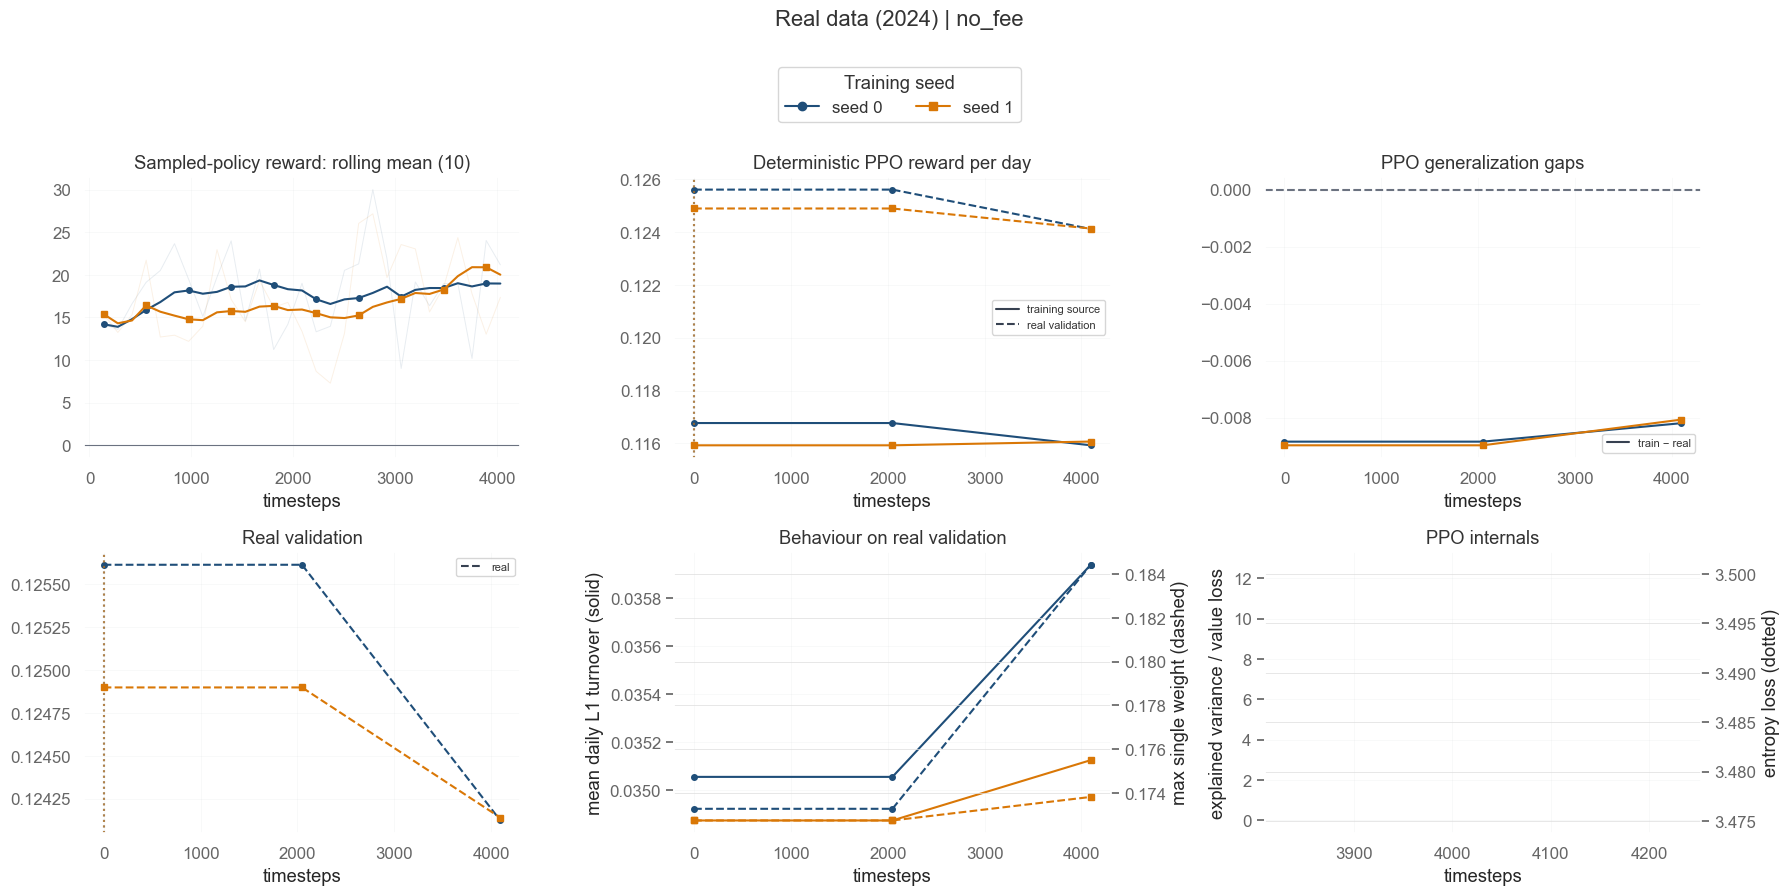

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/real_trained_e3add3a6__no_fee__learning_curves_all_seeds.png


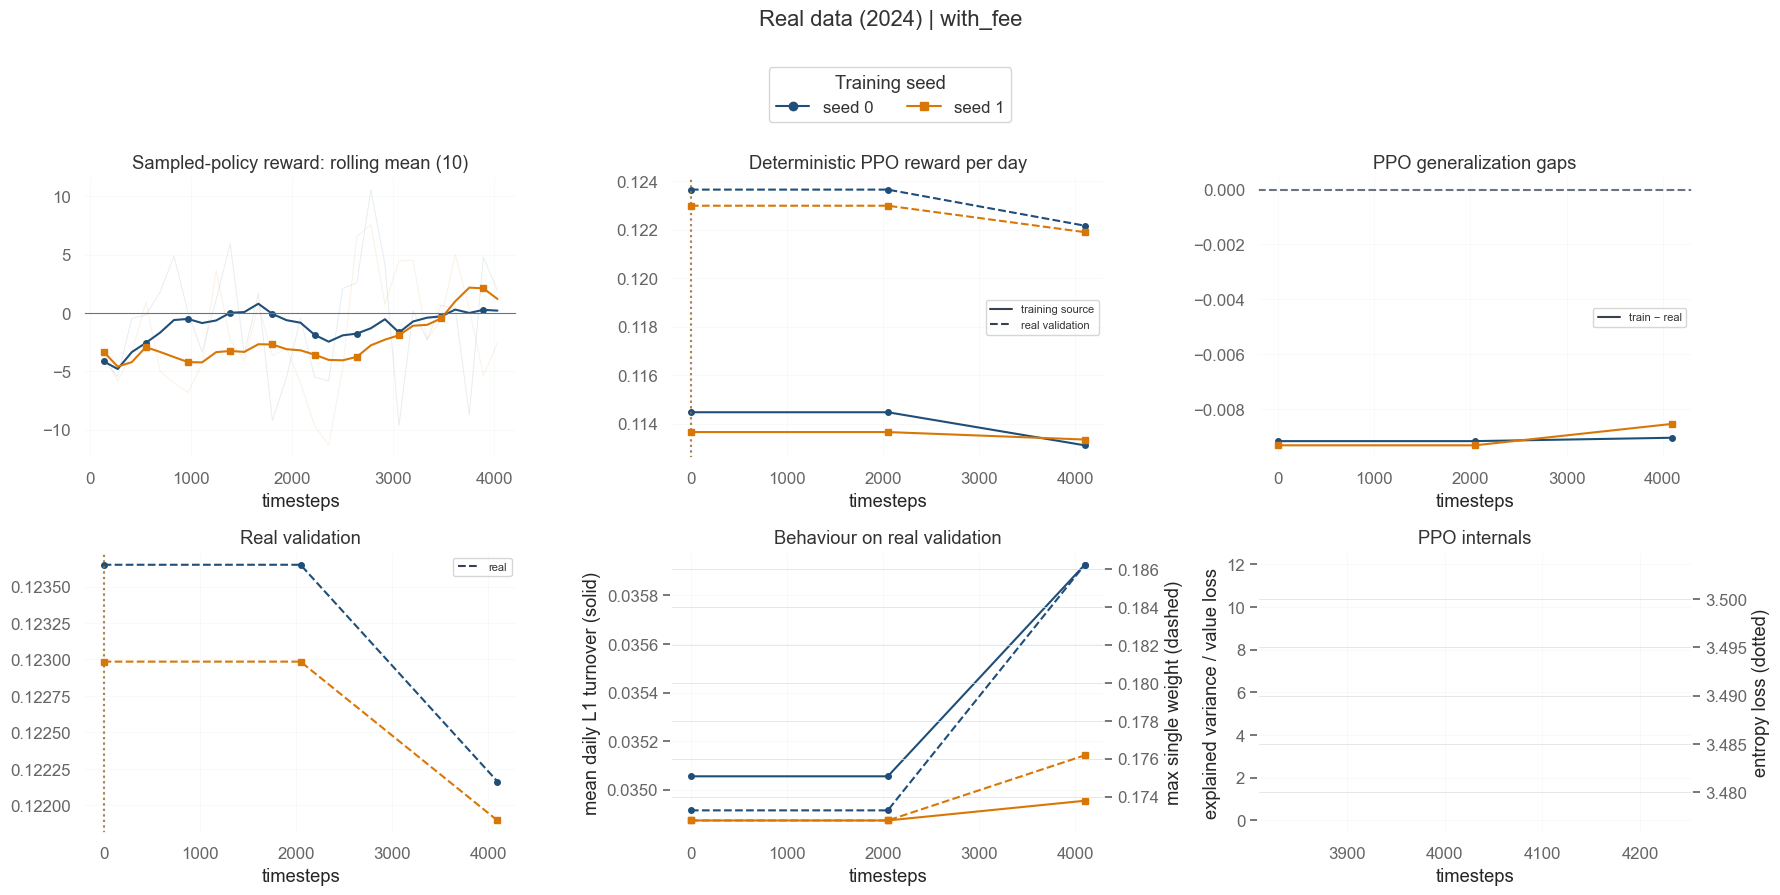

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/real_trained_e3add3a6__with_fee__learning_curves_all_seeds.png


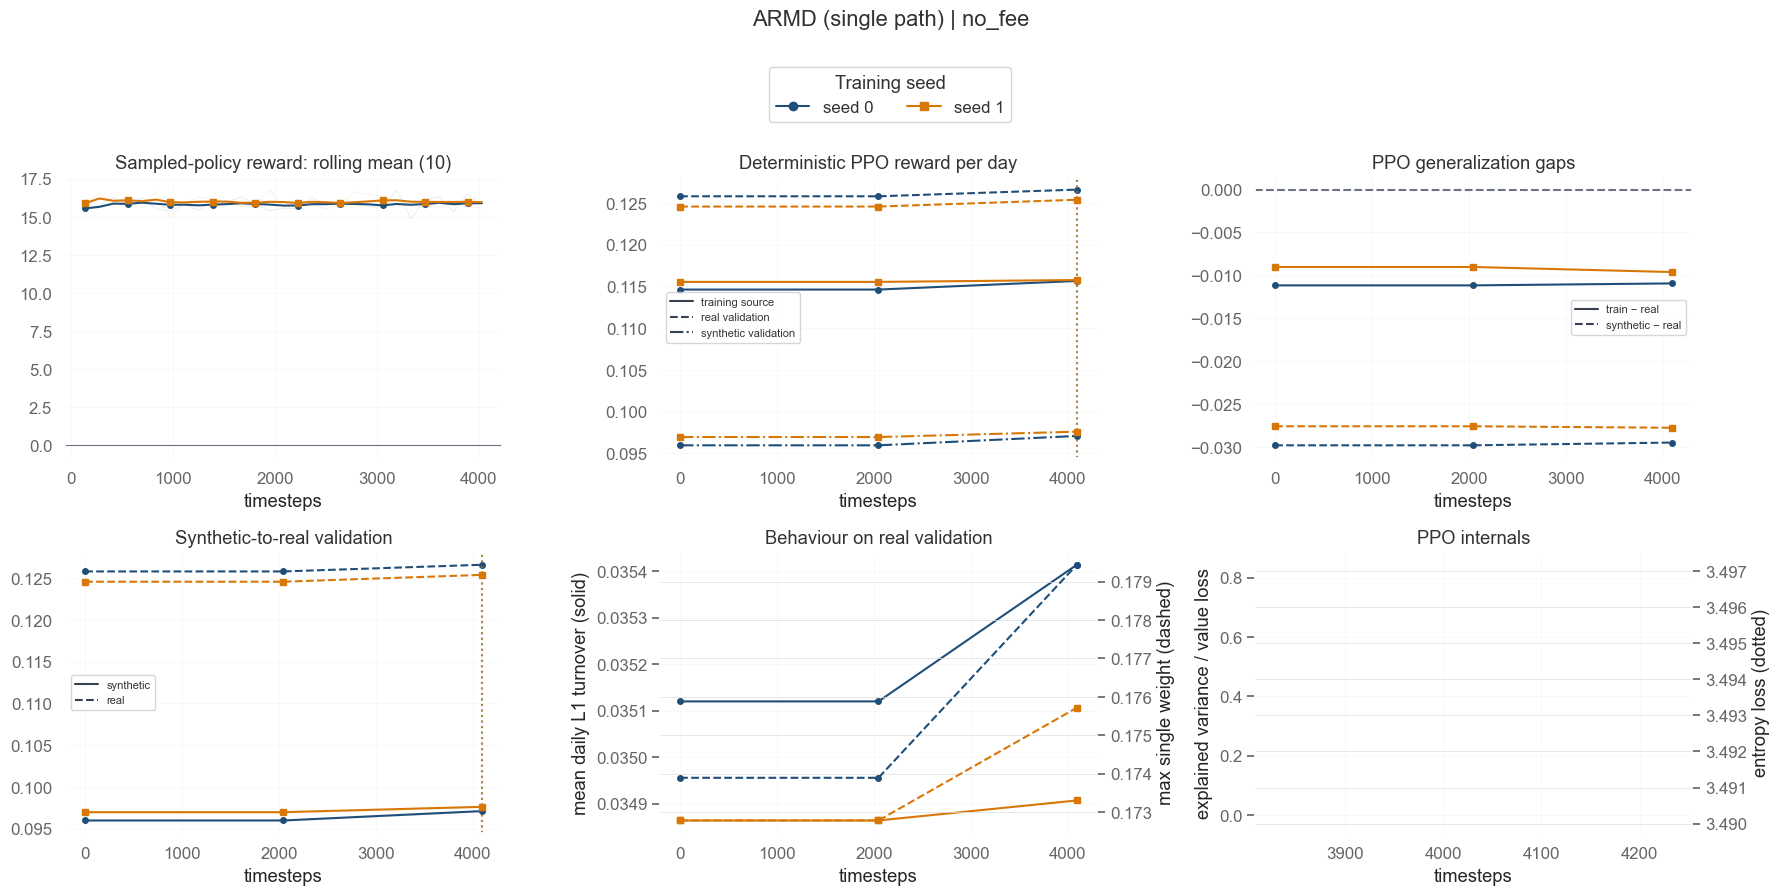

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/synthetic_armd__single_path_84ed9010__no_fee__learning_curves_all_seeds.png


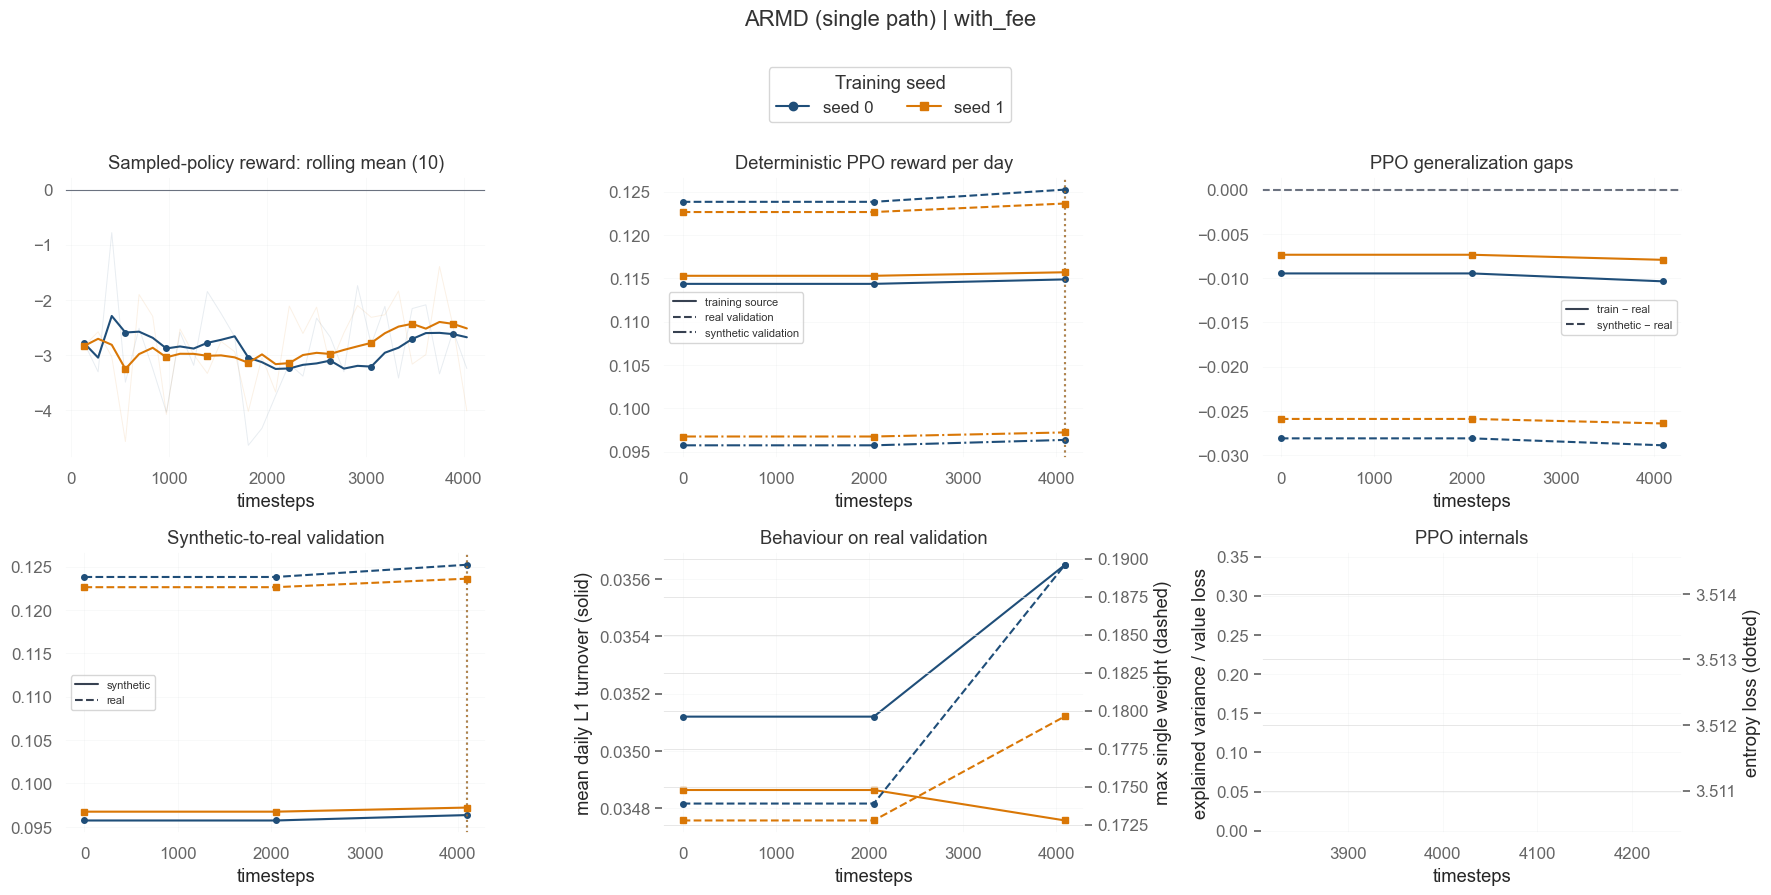

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/synthetic_armd__single_path_84ed9010__with_fee__learning_curves_all_seeds.png


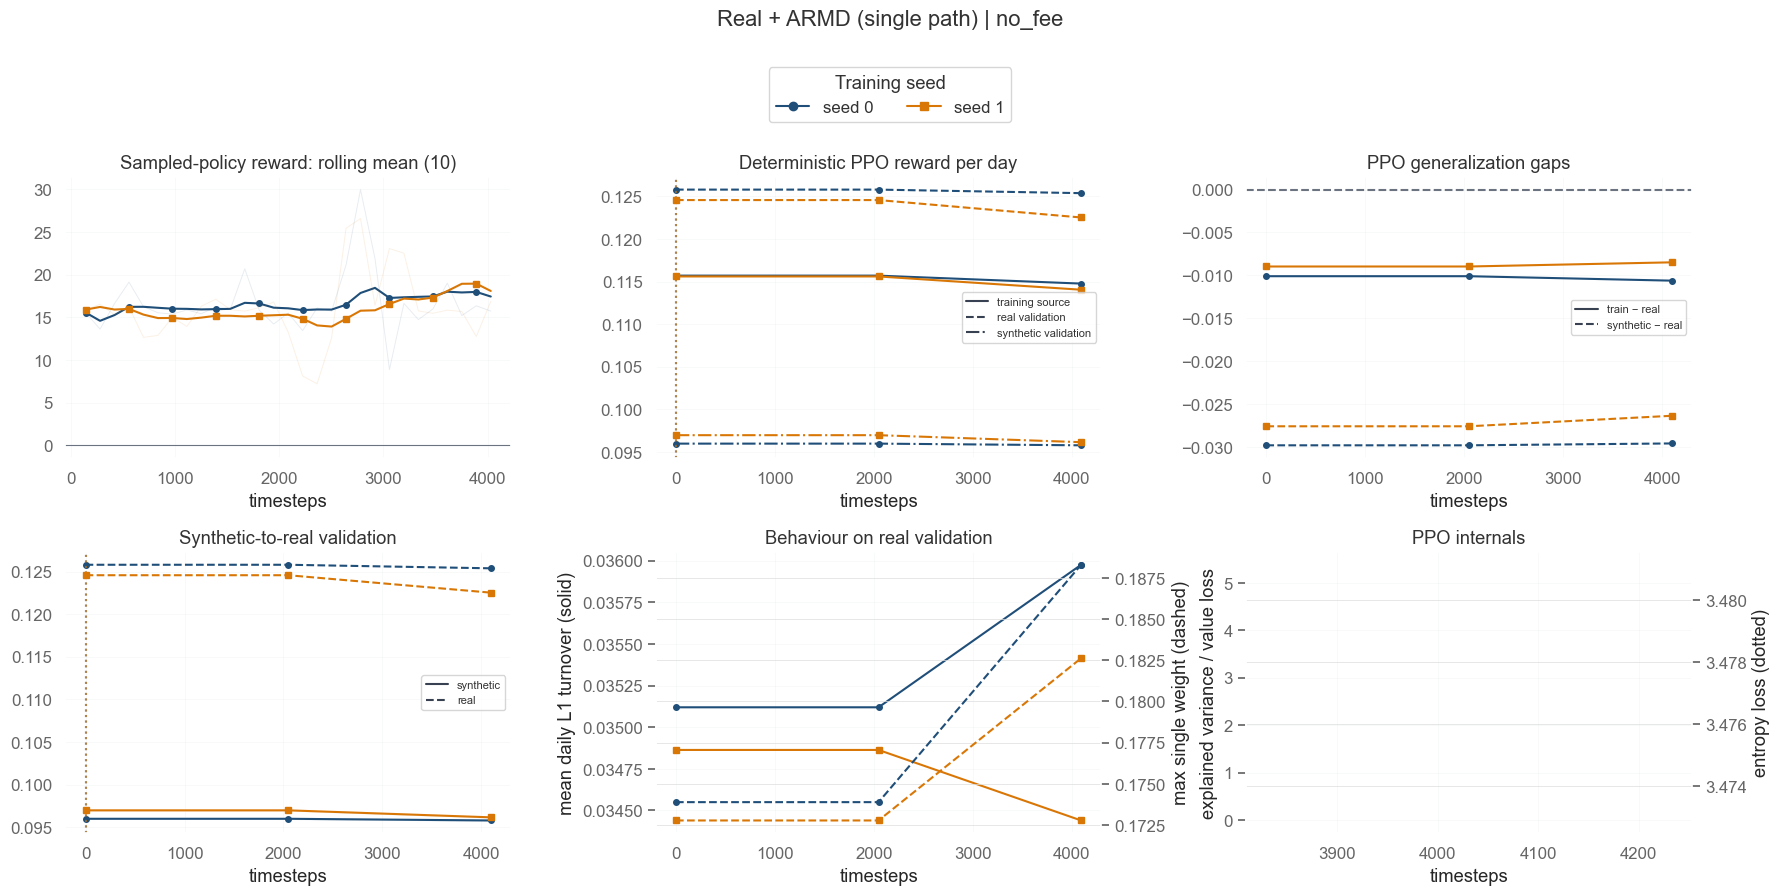

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/real_synthetic_armd__single_path_74afc164__no_fee__learning_curves_all_seeds.png


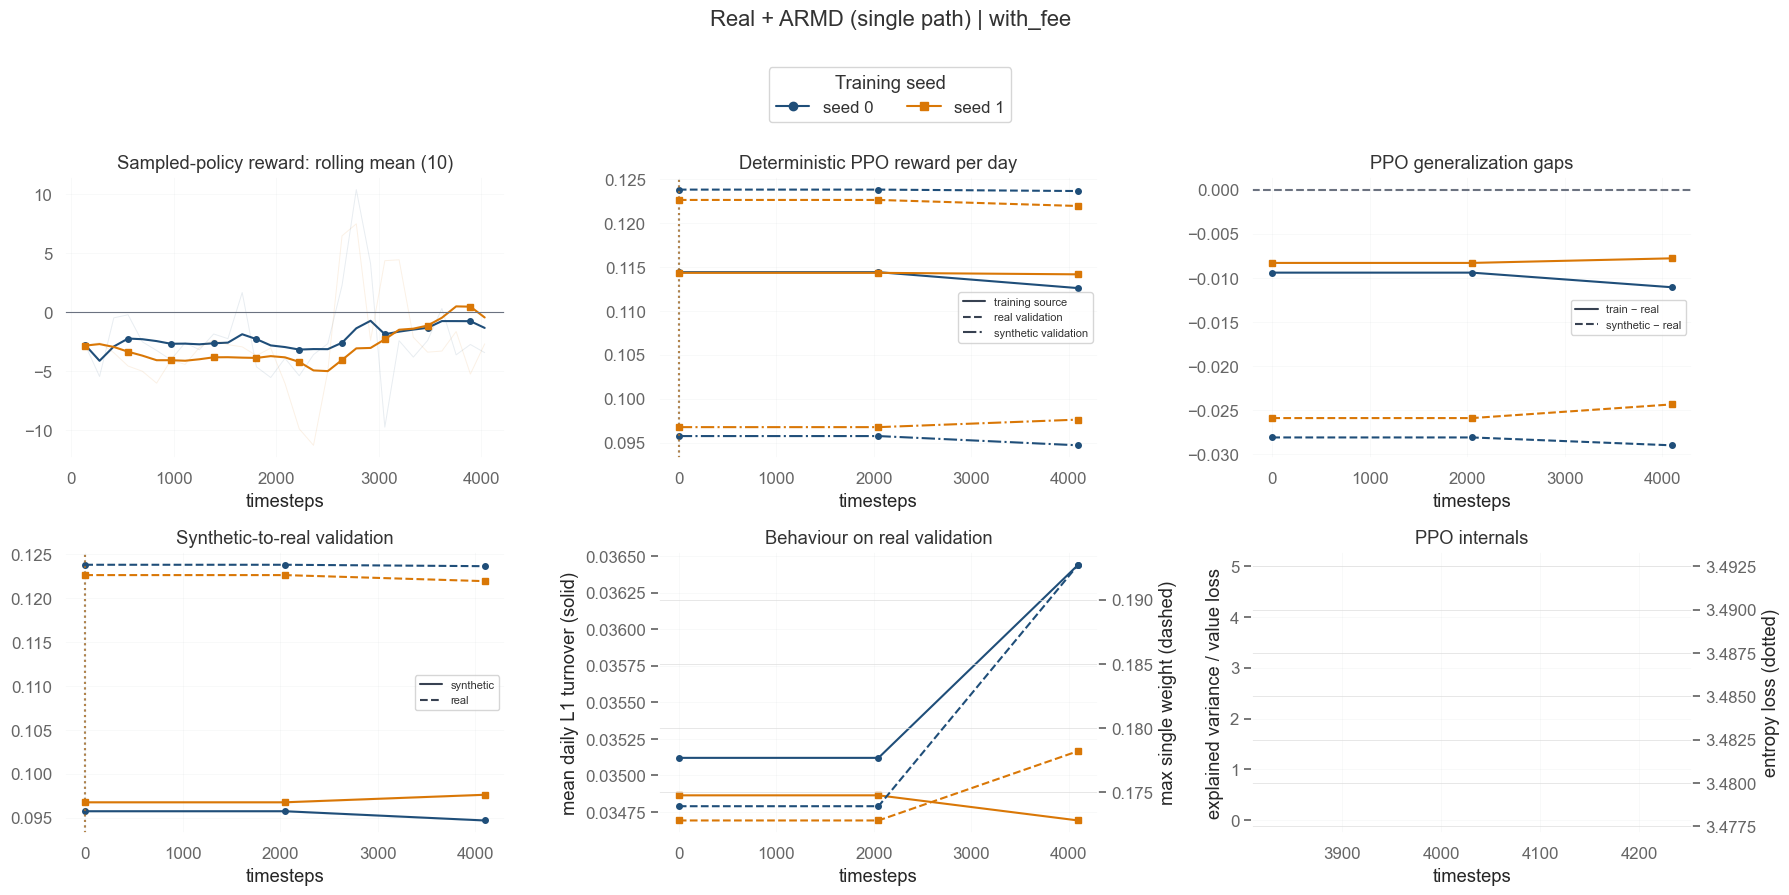

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/real_synthetic_armd__single_path_74afc164__with_fee__learning_curves_all_seeds.png


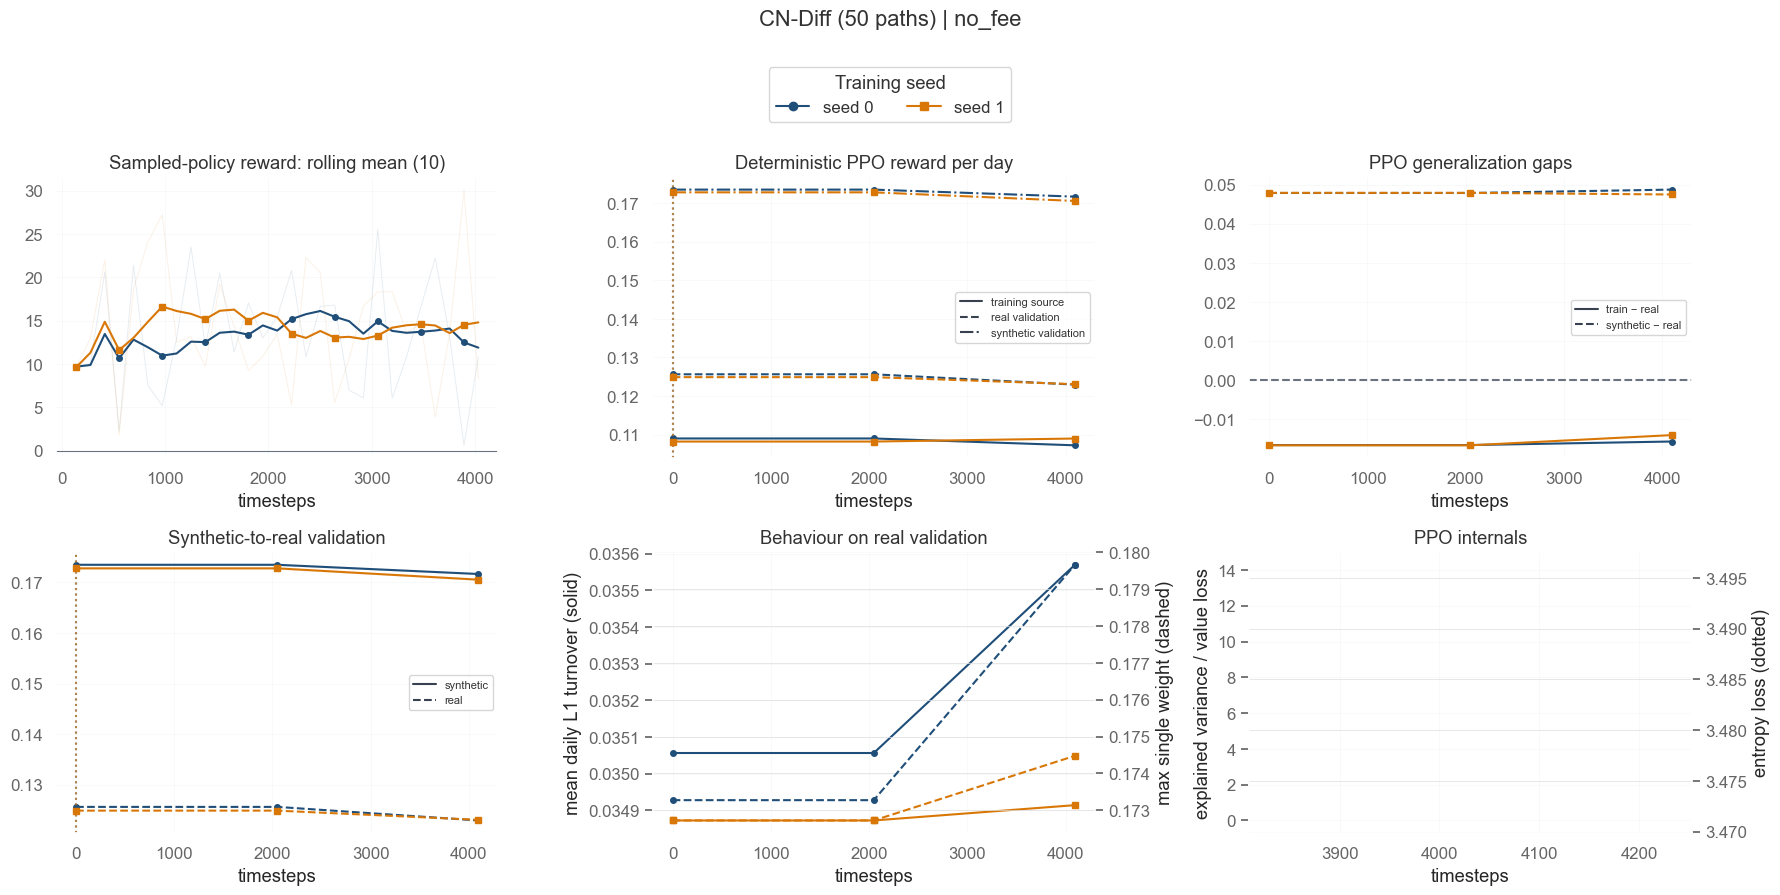

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/synthetic_cndiff__50_paths_c6bf8db5__no_fee__learning_curves_all_seeds.png


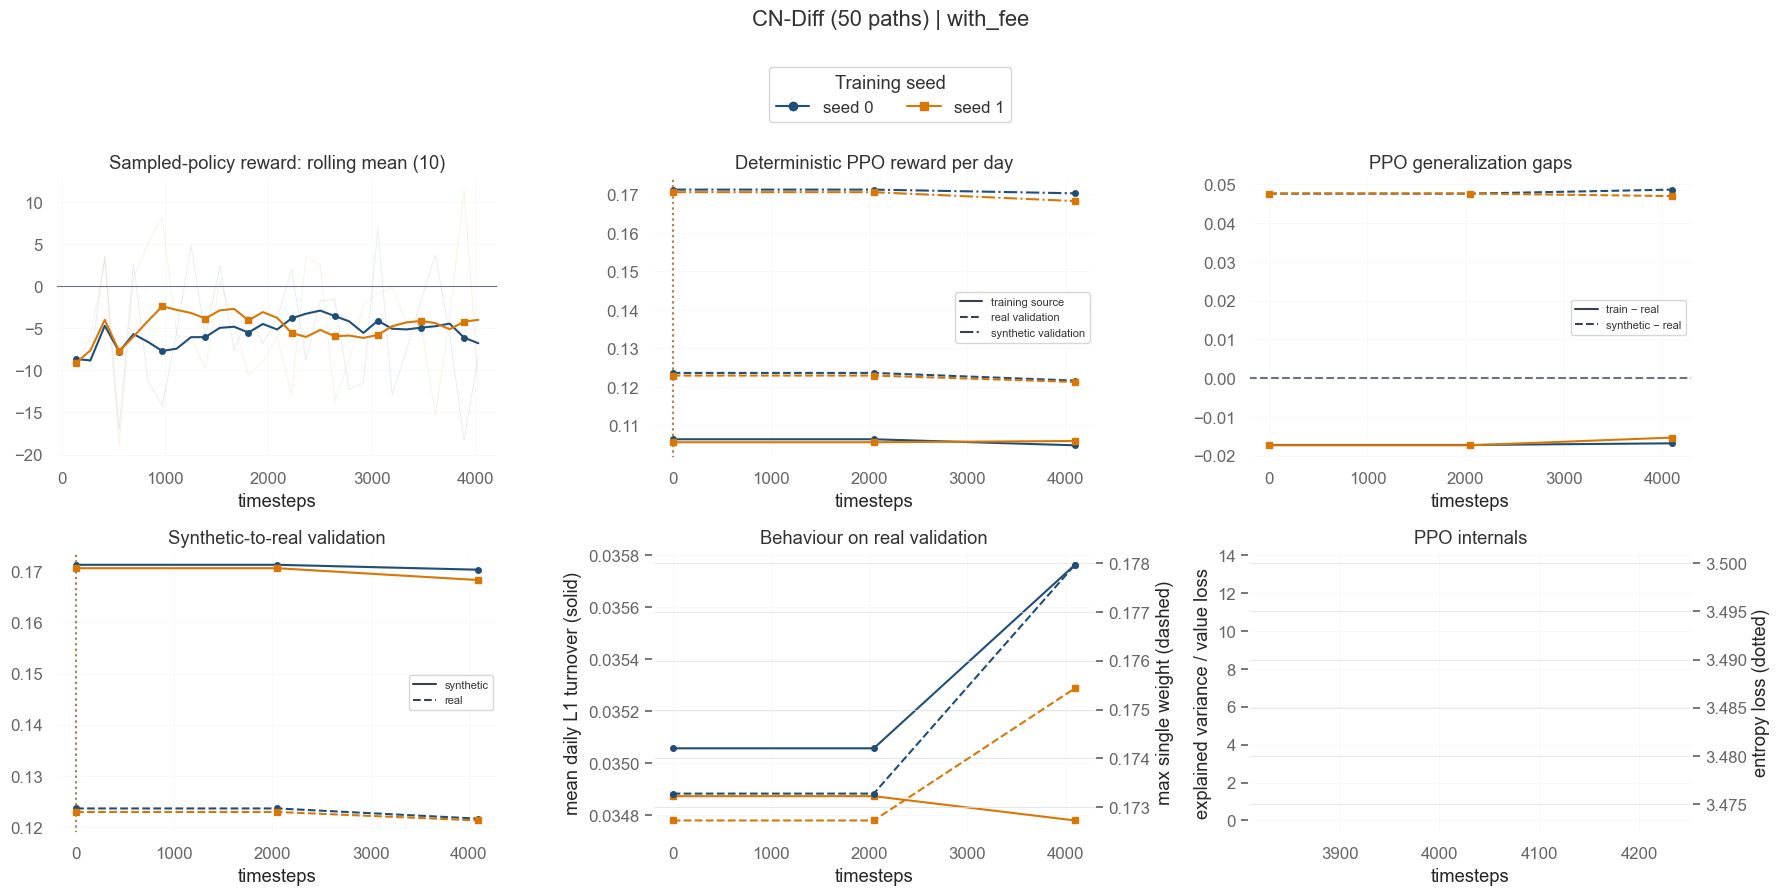

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/synthetic_cndiff__50_paths_c6bf8db5__with_fee__learning_curves_all_seeds.png


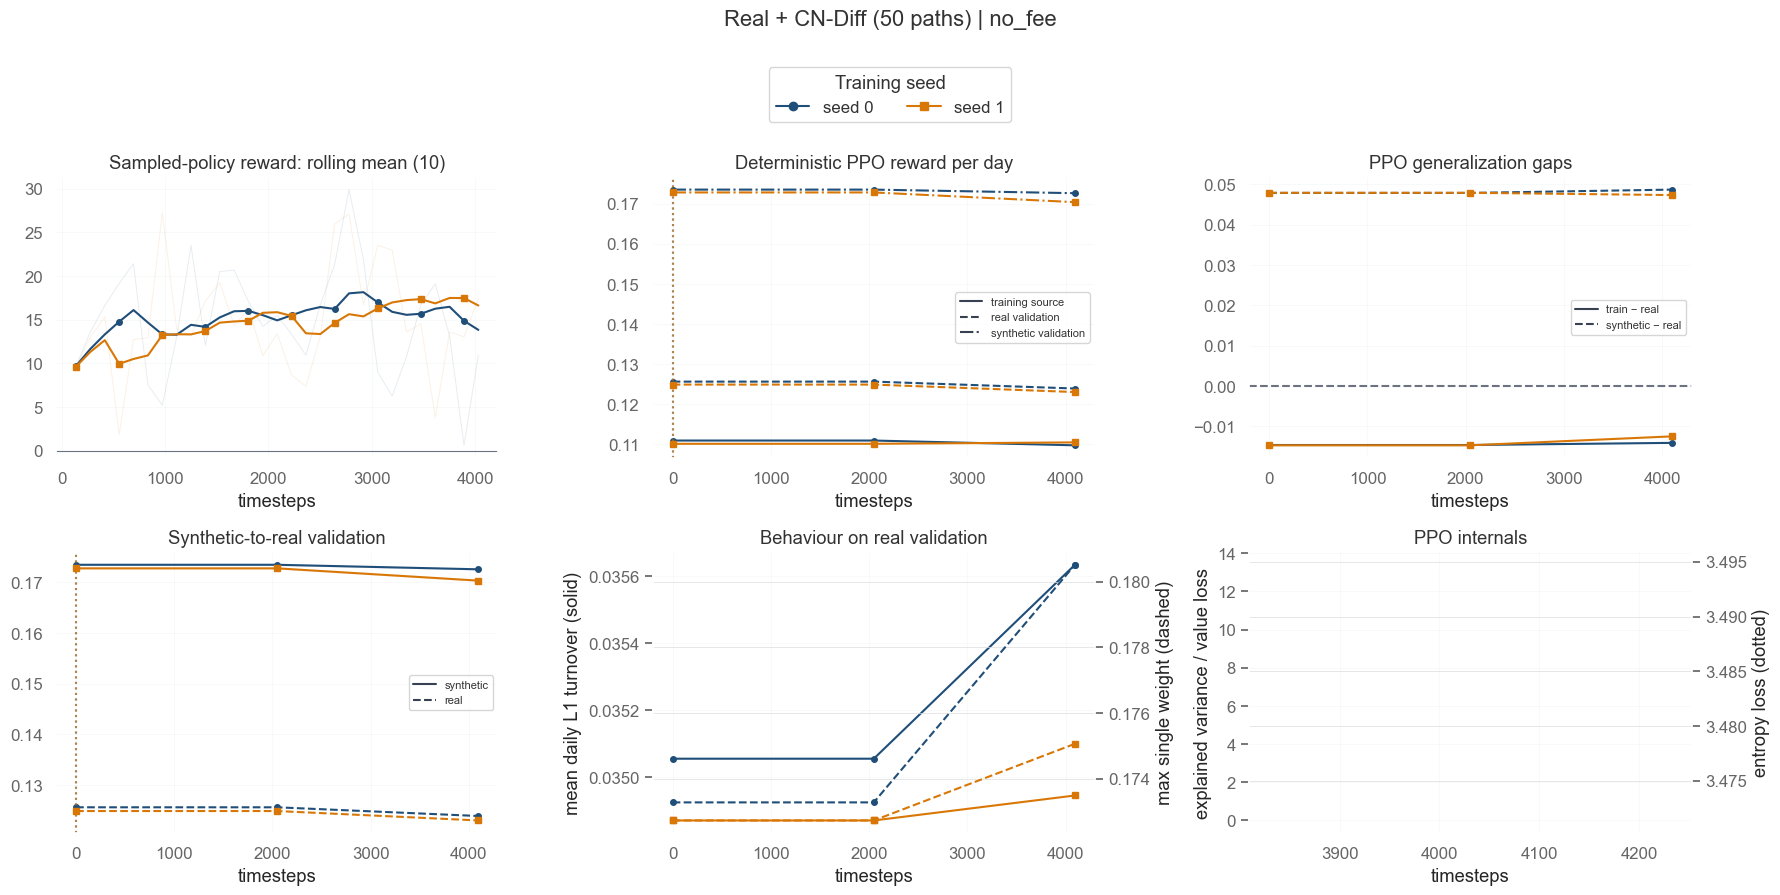

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/real_synthetic_cndiff__50_paths_a028dc0c__no_fee__learning_curves_all_seeds.png


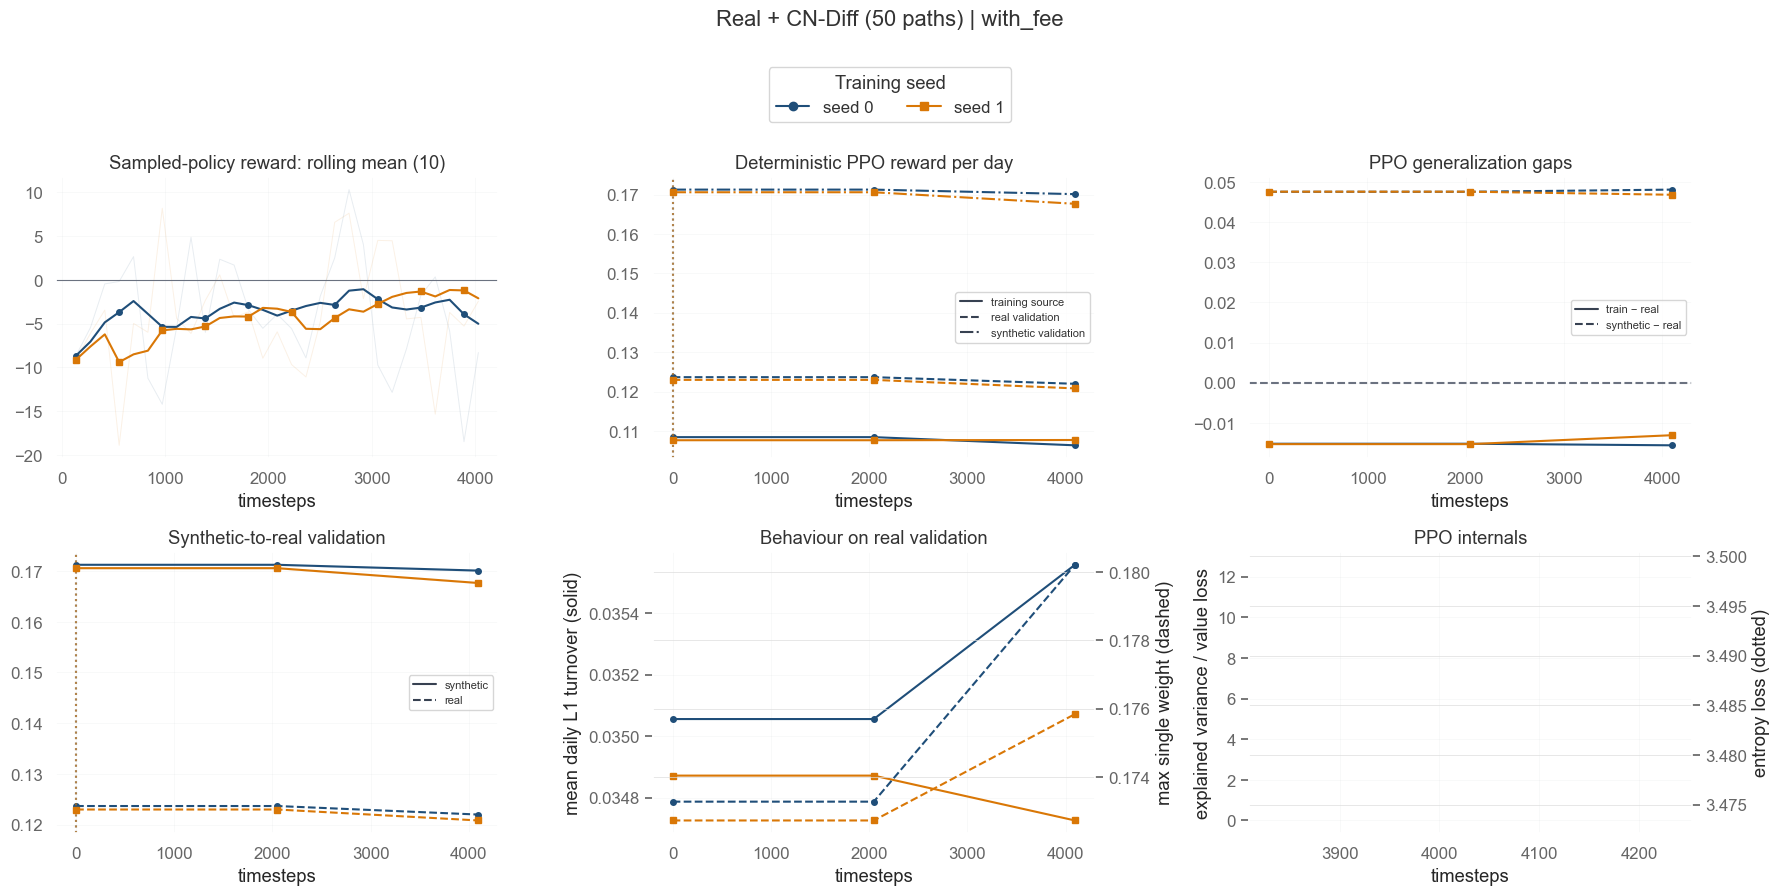

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/real_synthetic_cndiff__50_paths_a028dc0c__with_fee__learning_curves_all_seeds.png


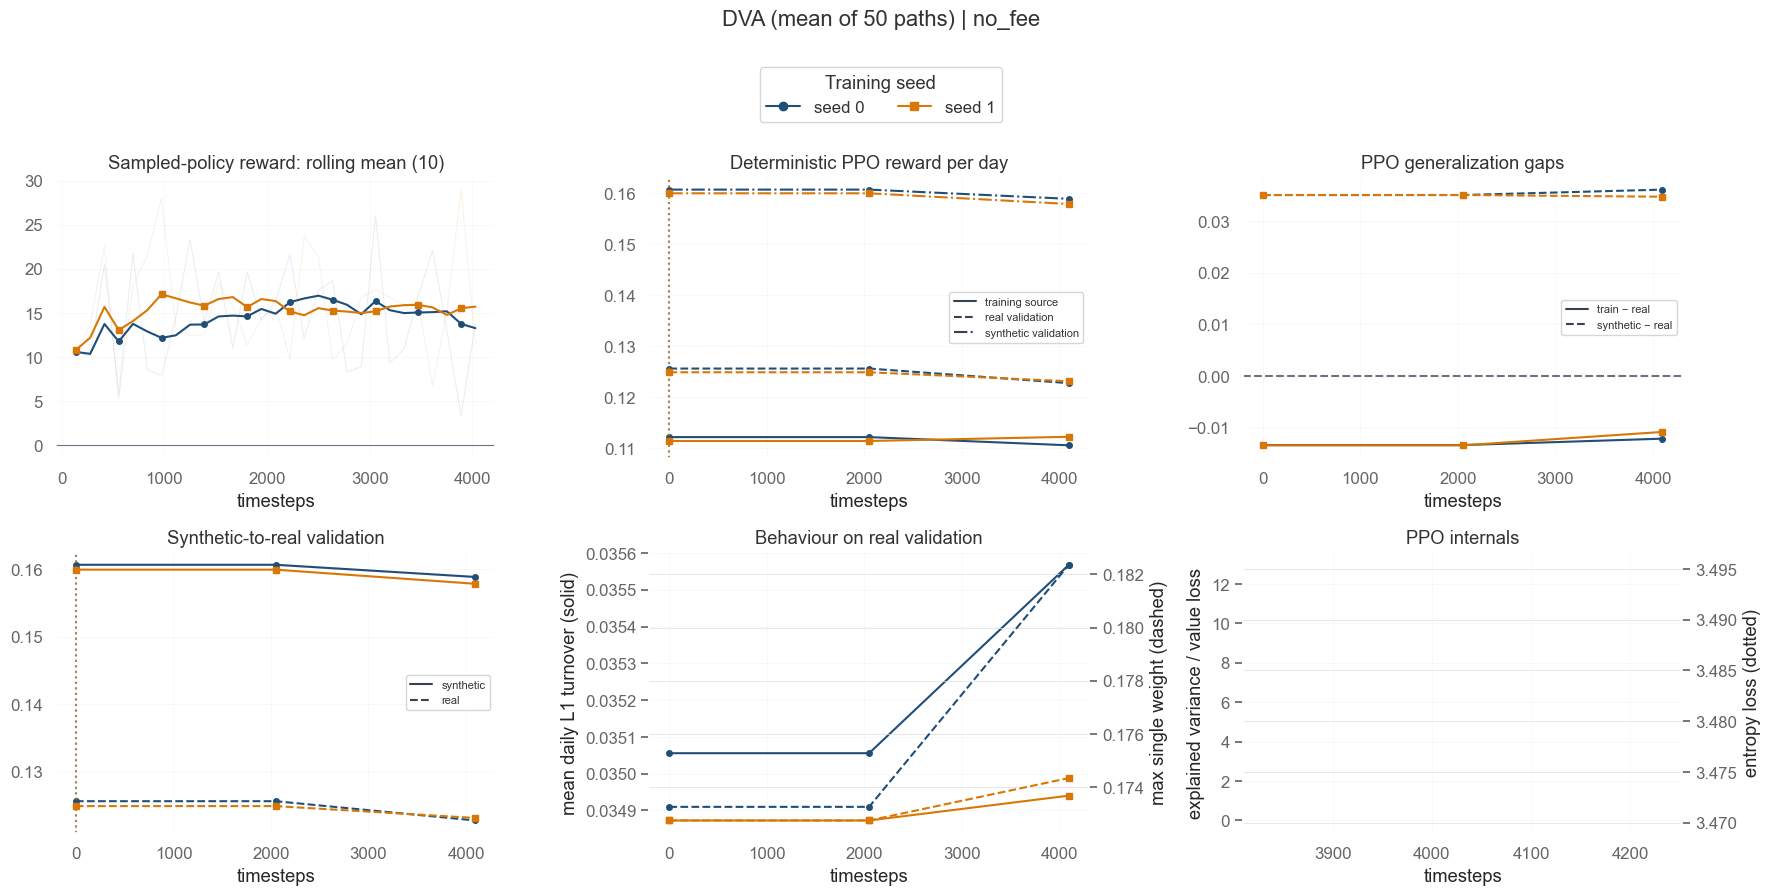

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/synthetic_dva__mean_of_50_paths_eb38f0e4__no_fee__learning_curves_all_seeds.png


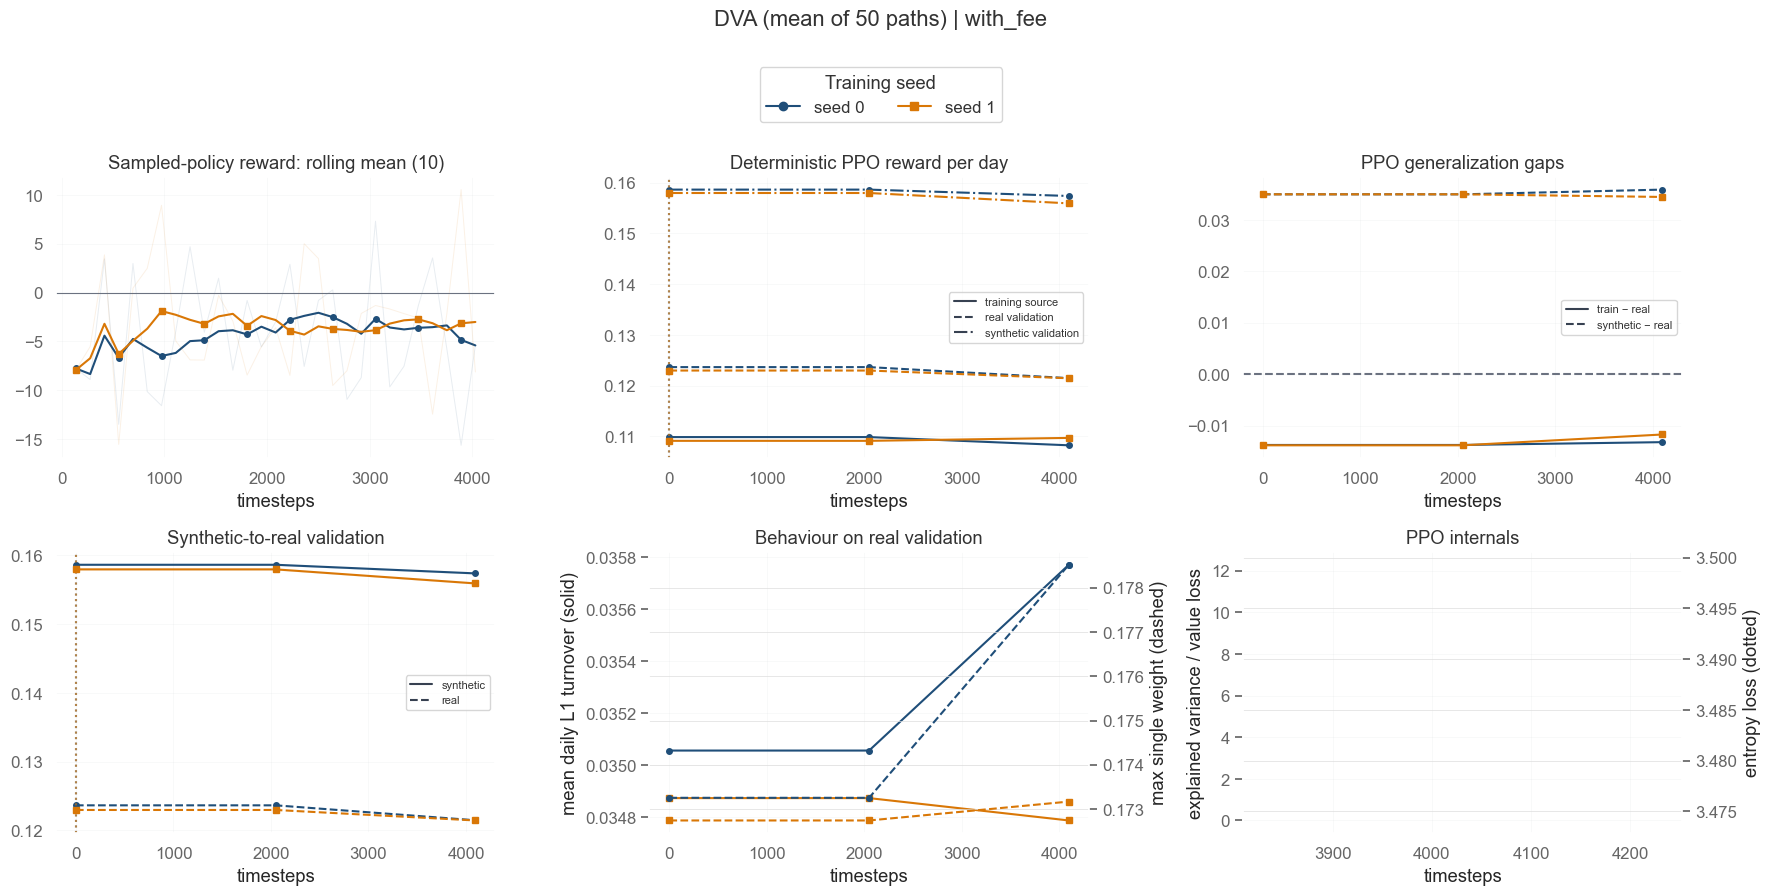

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/synthetic_dva__mean_of_50_paths_eb38f0e4__with_fee__learning_curves_all_seeds.png


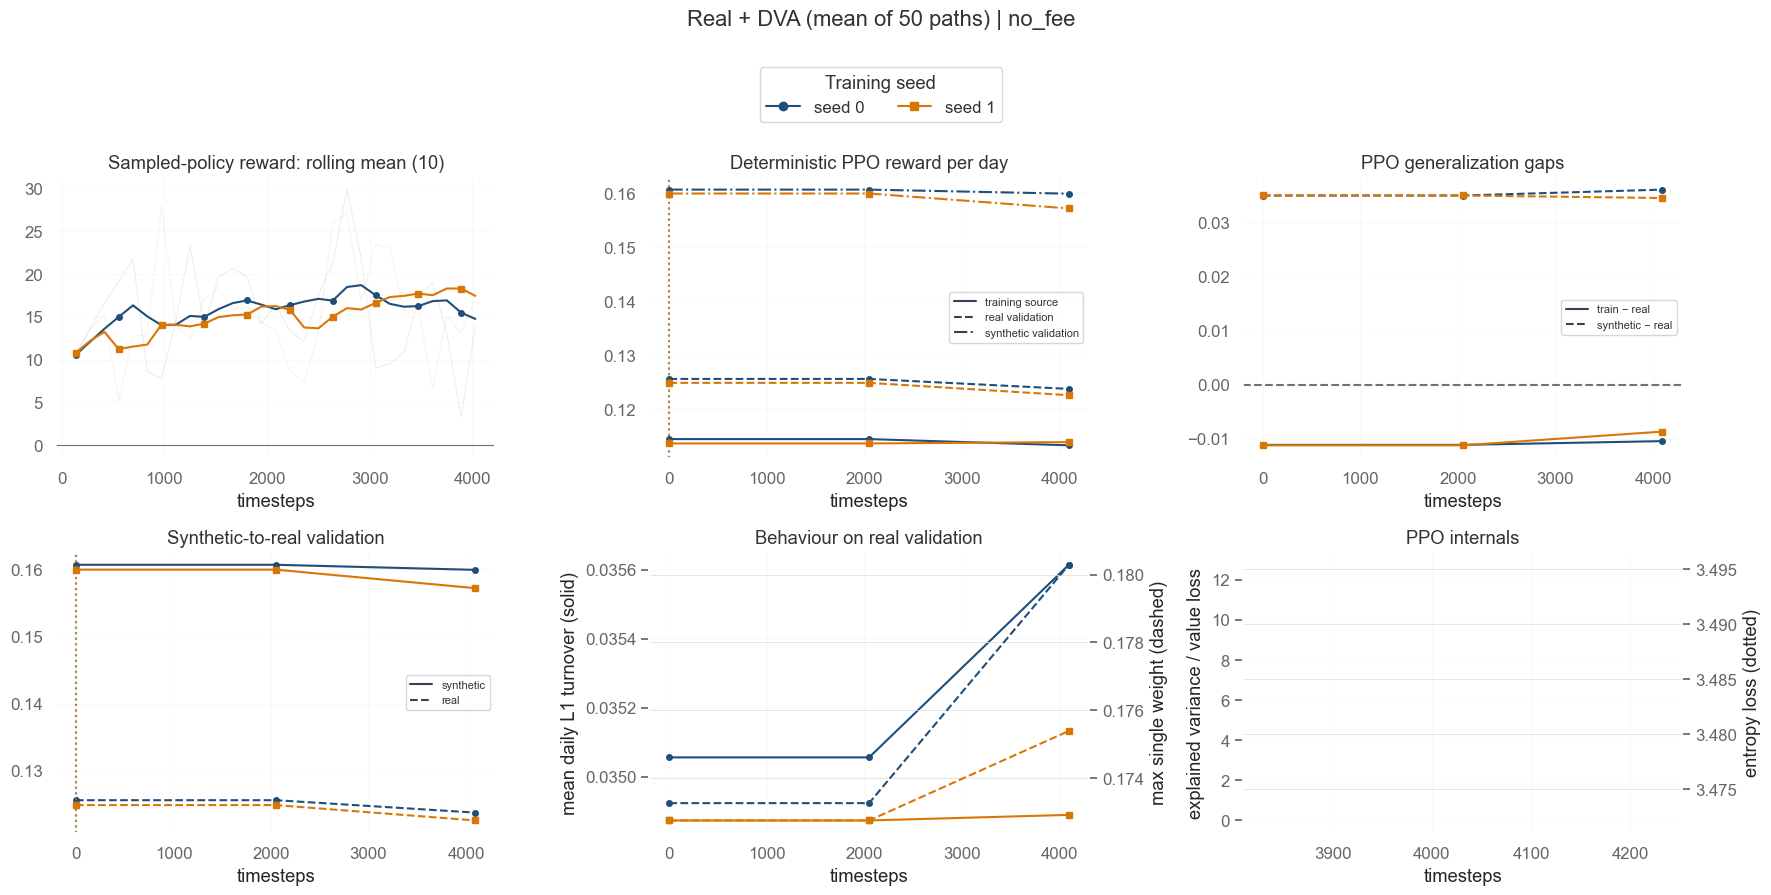

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/real_synthetic_dva__mean_of_50_paths_827679f1__no_fee__learning_curves_all_seeds.png


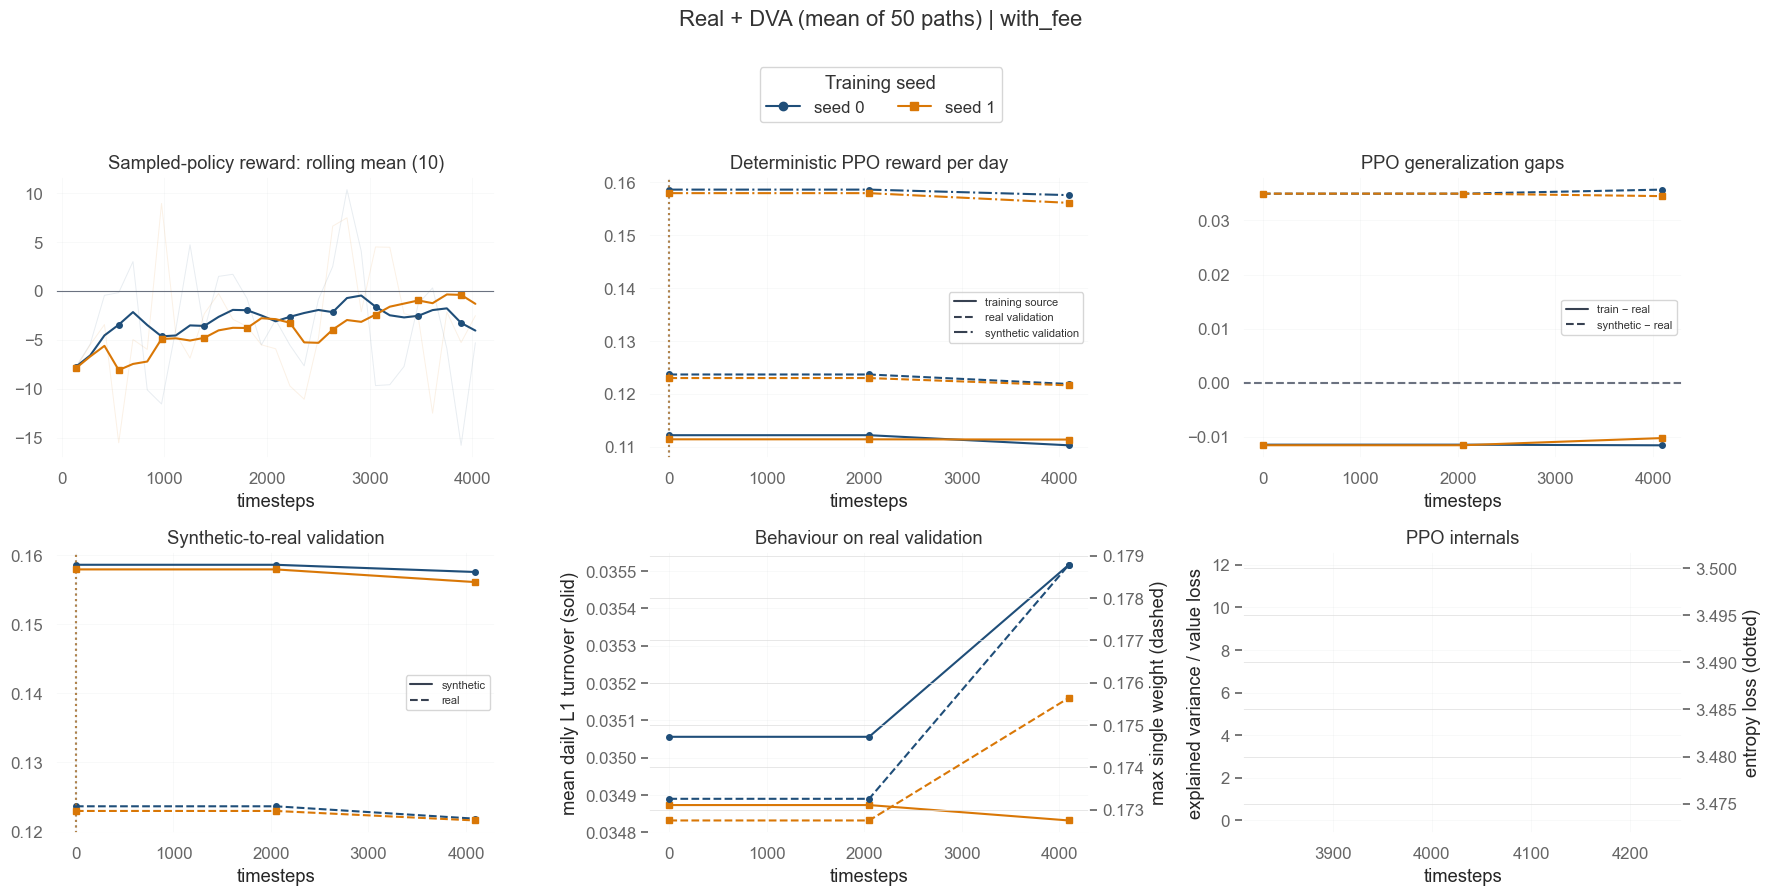

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/real_synthetic_dva__mean_of_50_paths_827679f1__with_fee__learning_curves_all_seeds.png


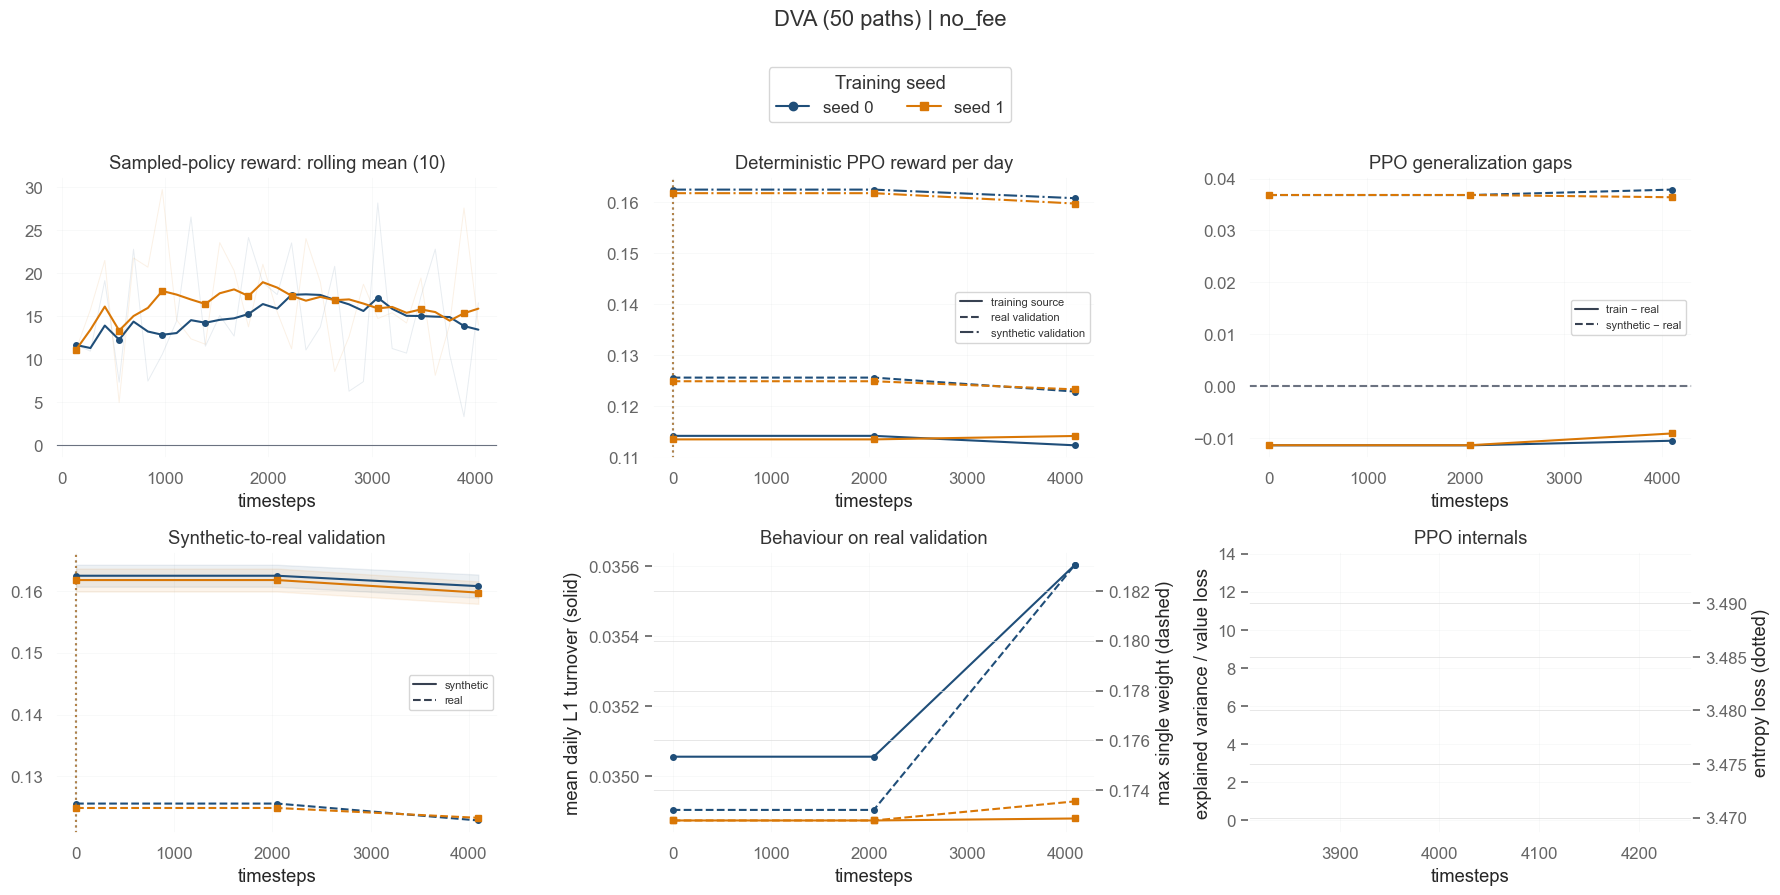

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/synthetic_dva__50_paths_f65c0613__no_fee__learning_curves_all_seeds.png


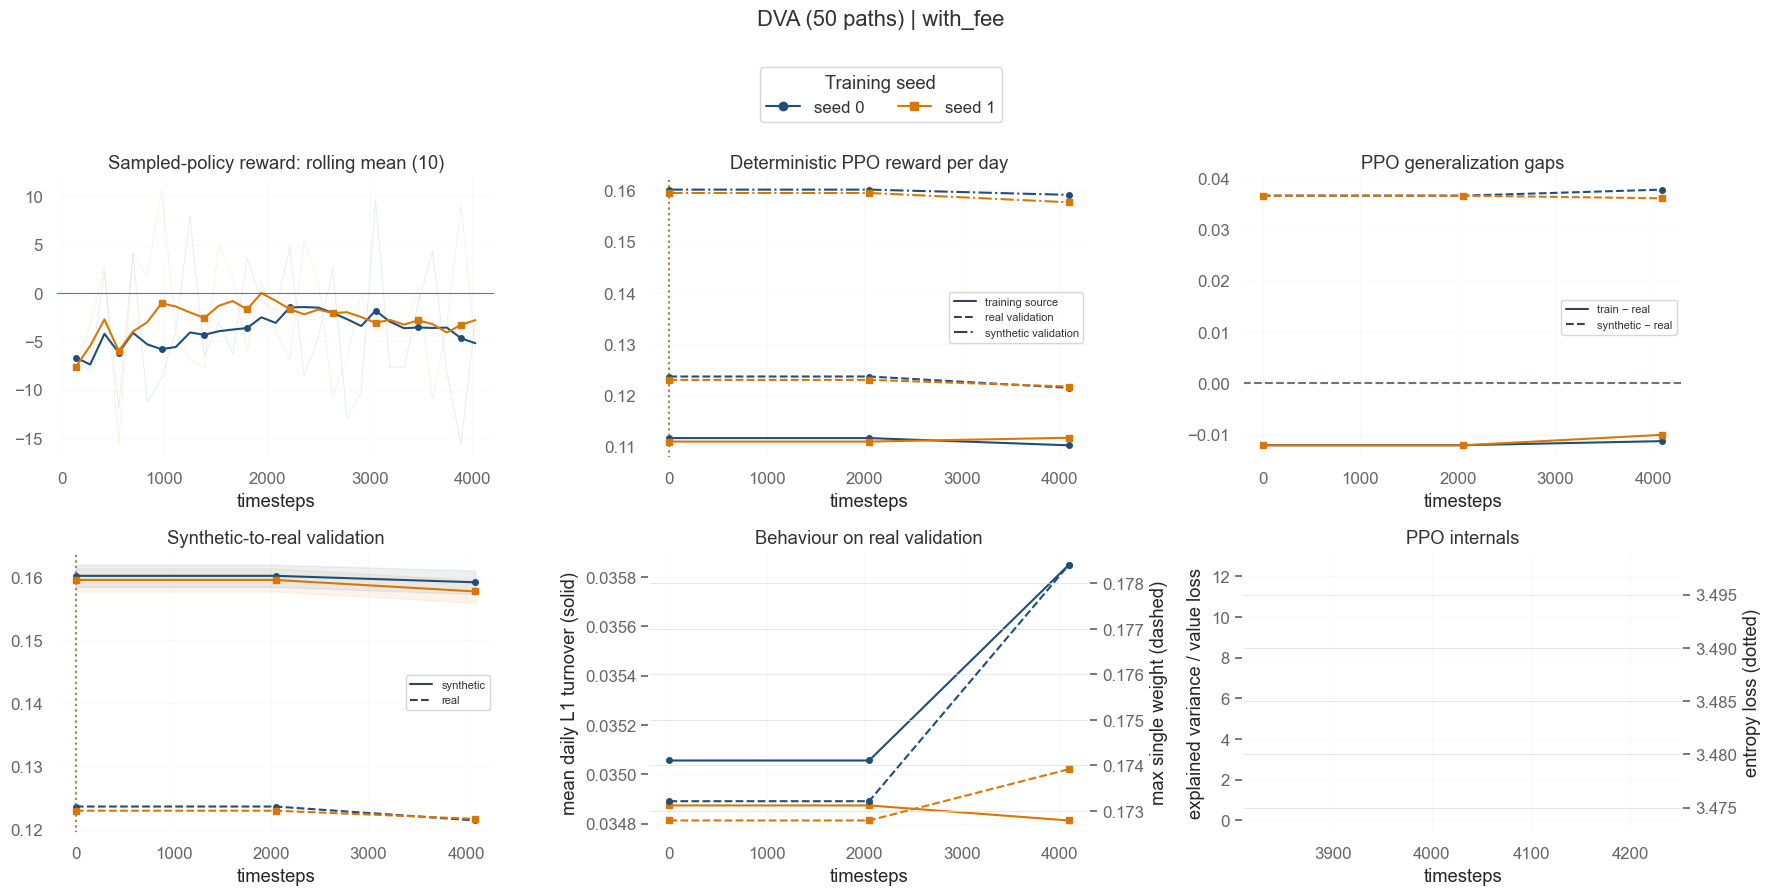

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/synthetic_dva__50_paths_f65c0613__with_fee__learning_curves_all_seeds.png


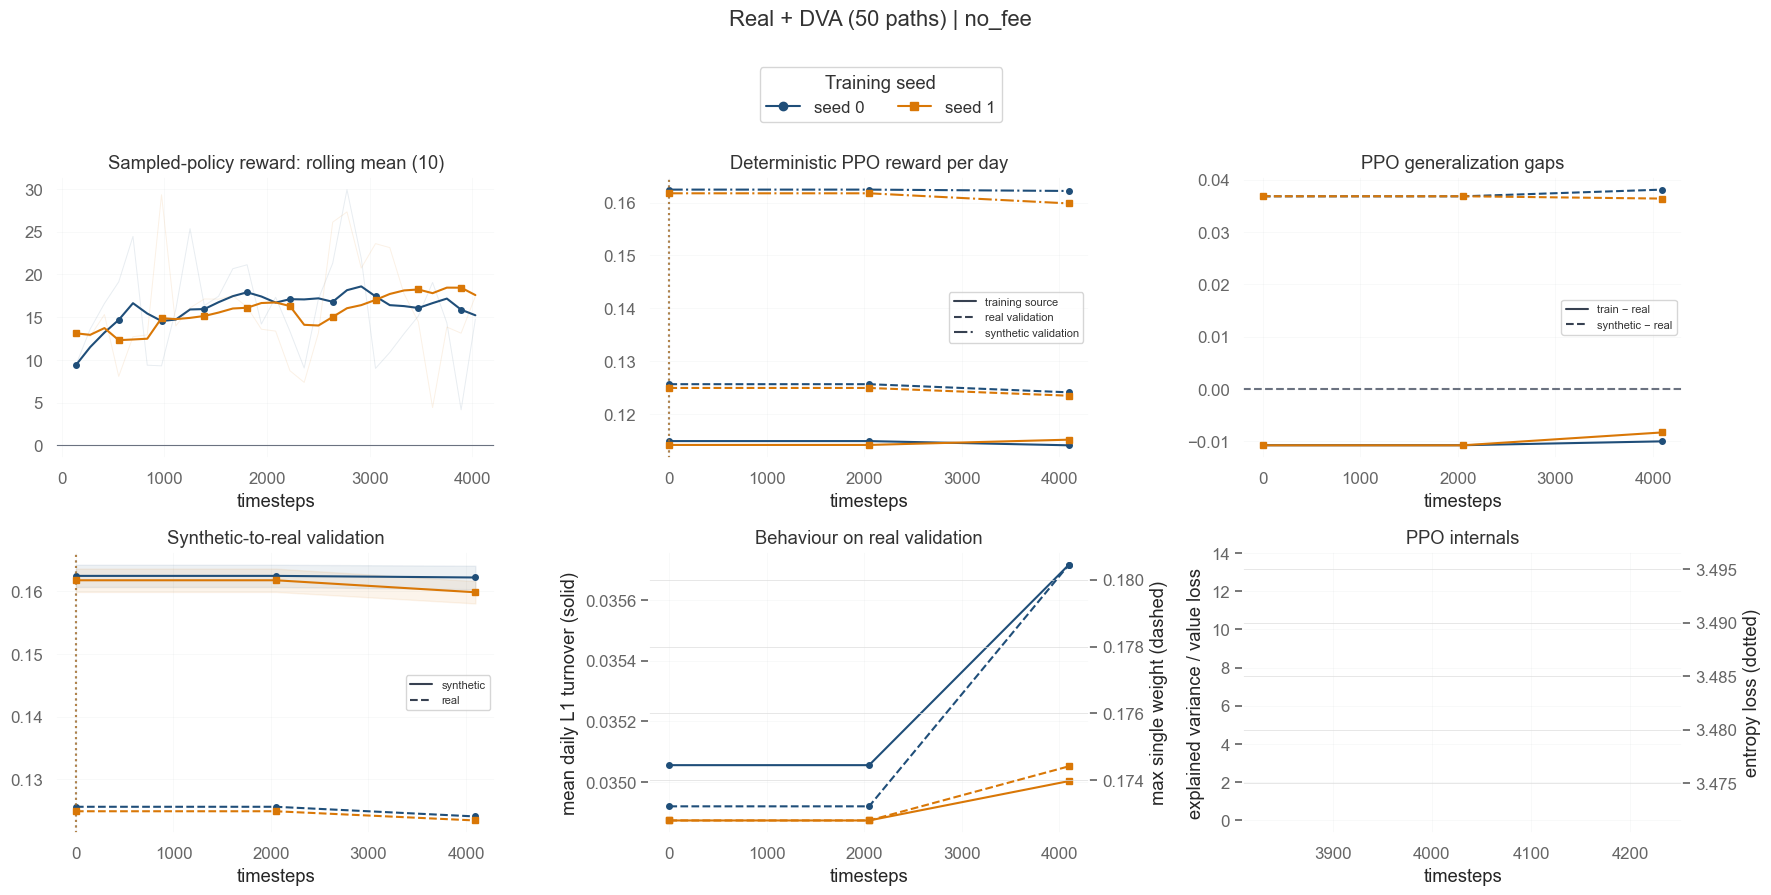

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/real_synthetic_dva__50_paths_d5ae4fdb__no_fee__learning_curves_all_seeds.png


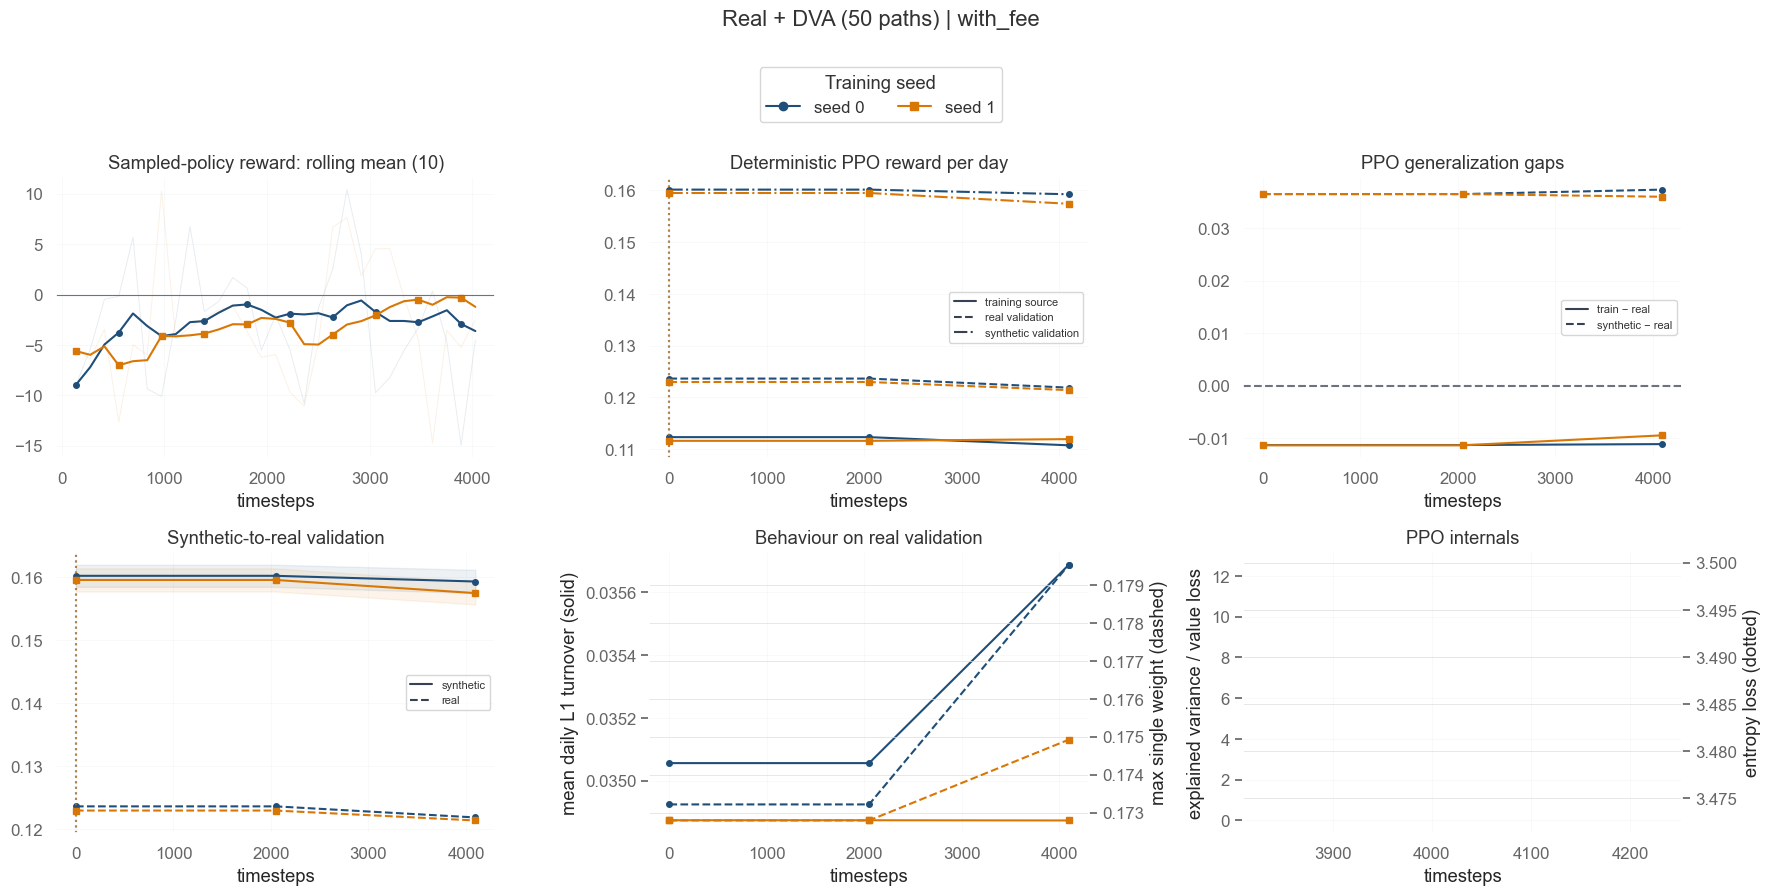

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/real_synthetic_dva__50_paths_d5ae4fdb__with_fee__learning_curves_all_seeds.png


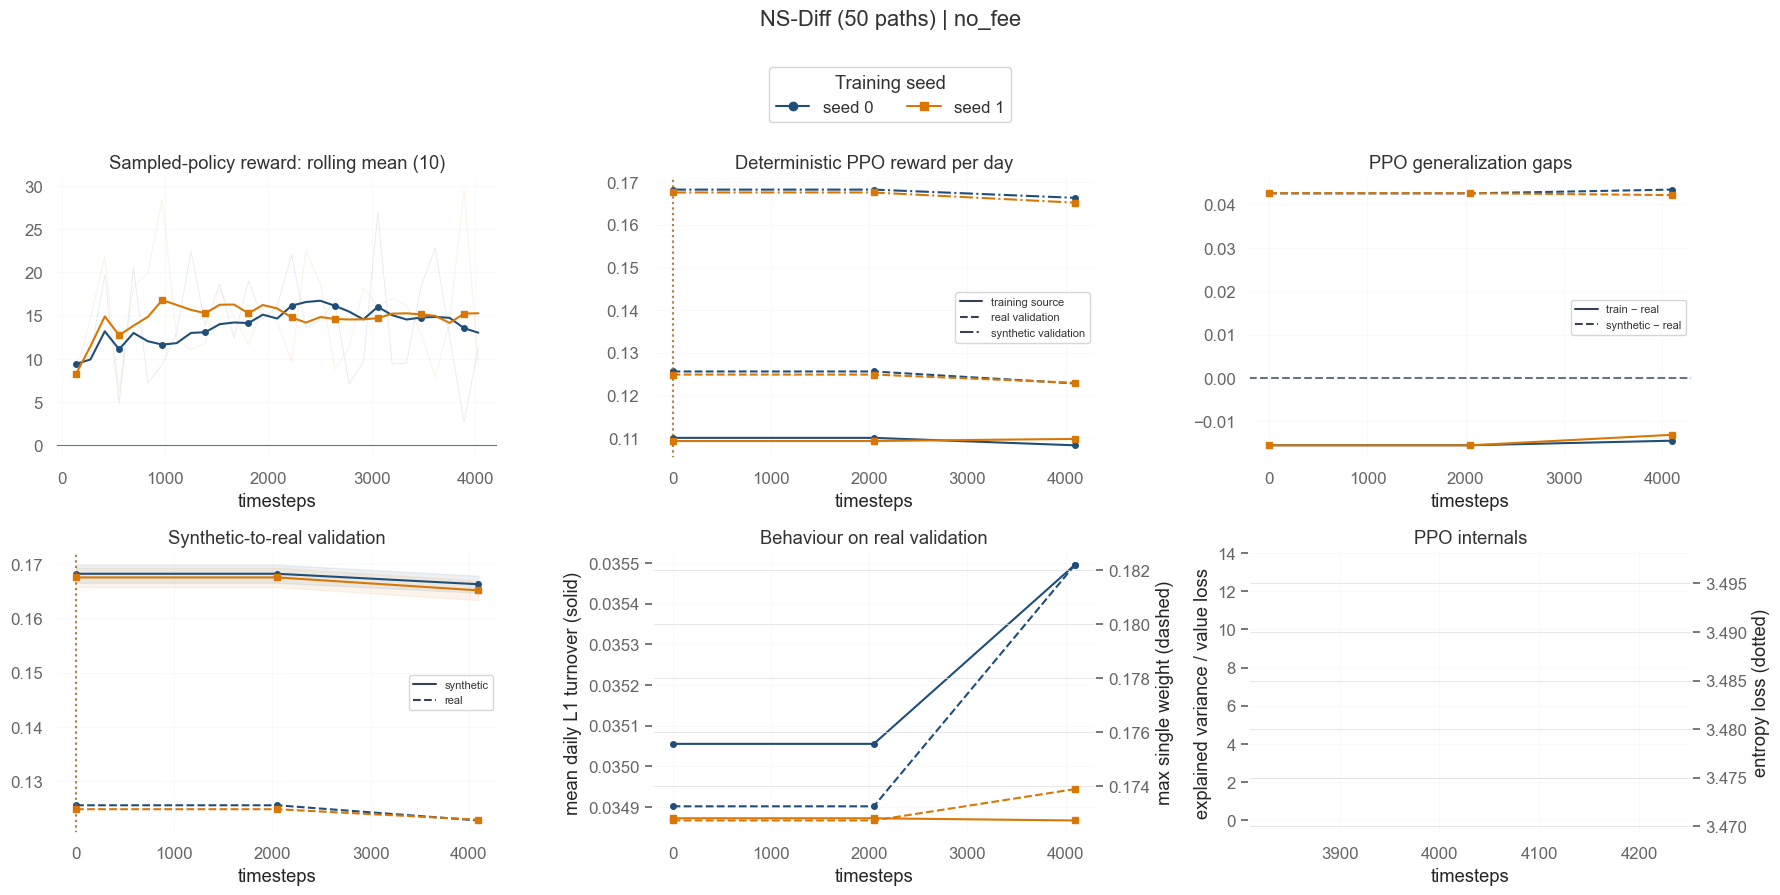

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/synthetic_nsdiff__50_paths_aab7f4e1__no_fee__learning_curves_all_seeds.png


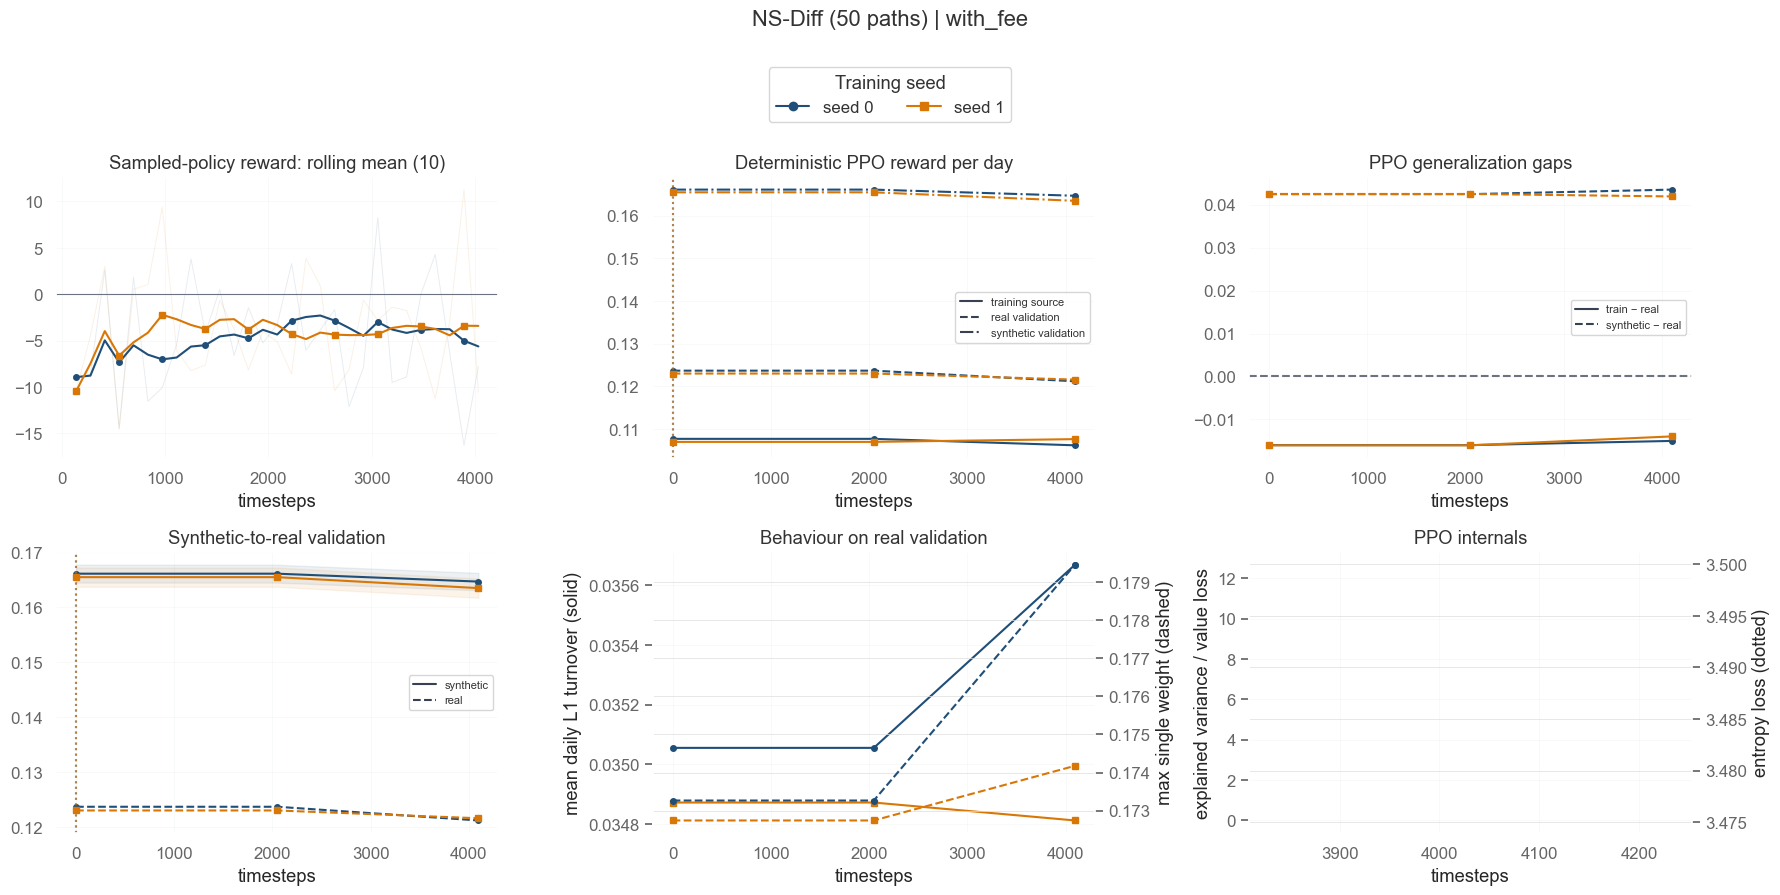

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/synthetic_nsdiff__50_paths_aab7f4e1__with_fee__learning_curves_all_seeds.png


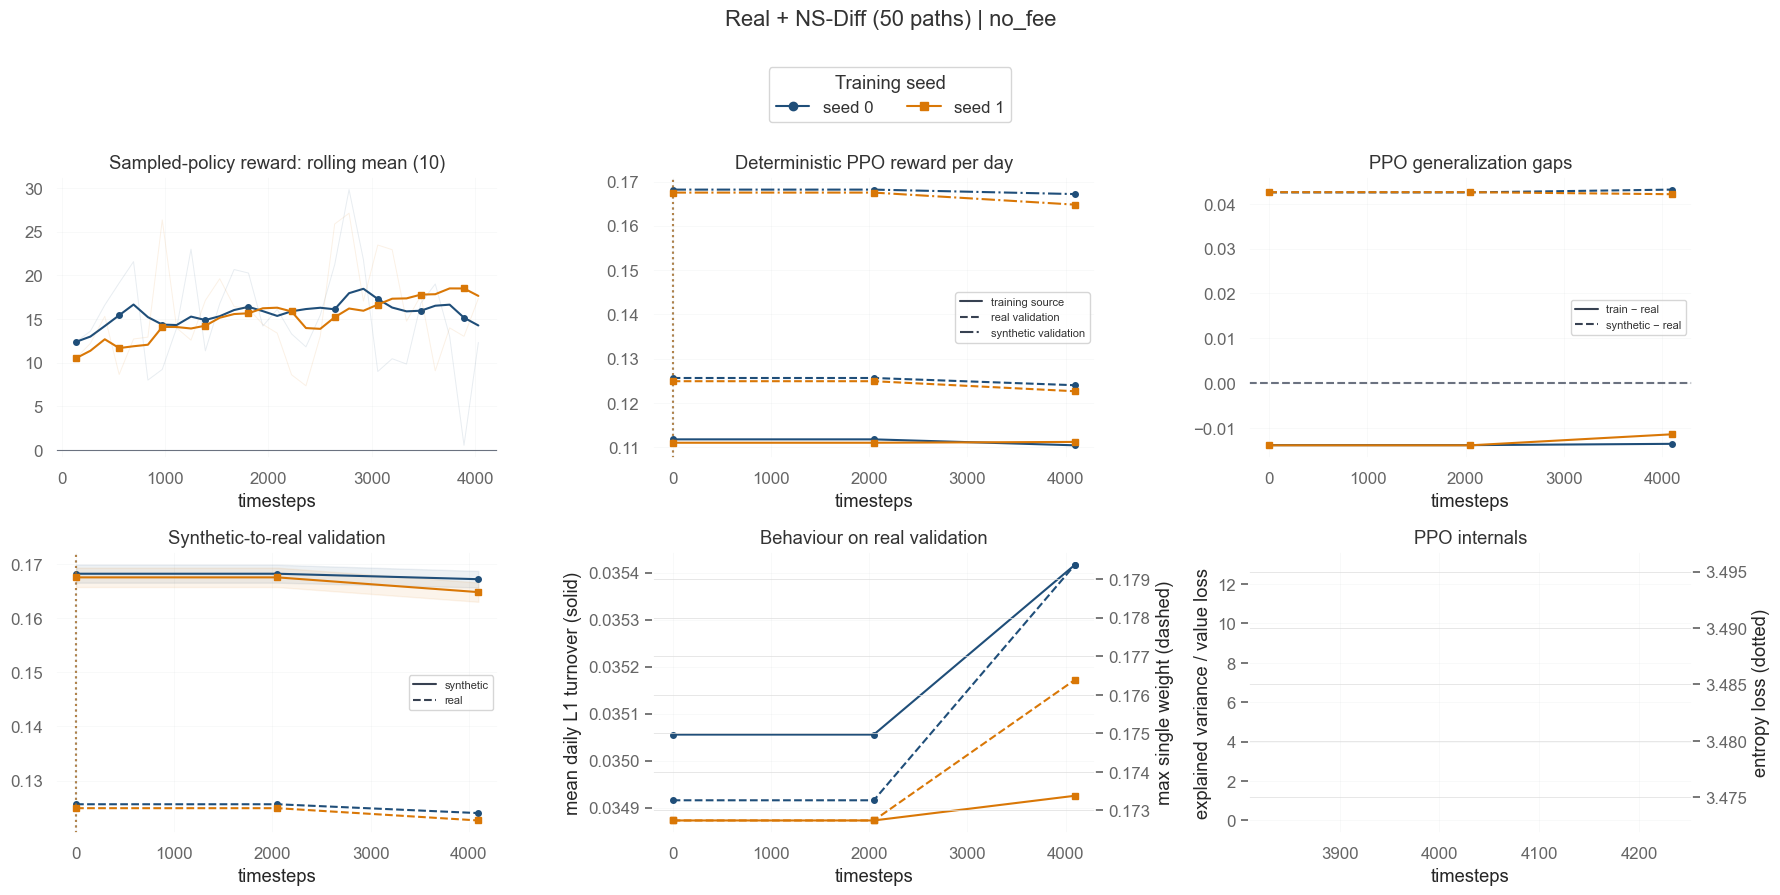

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/real_synthetic_nsdiff__50_paths_c63fbd5a__no_fee__learning_curves_all_seeds.png


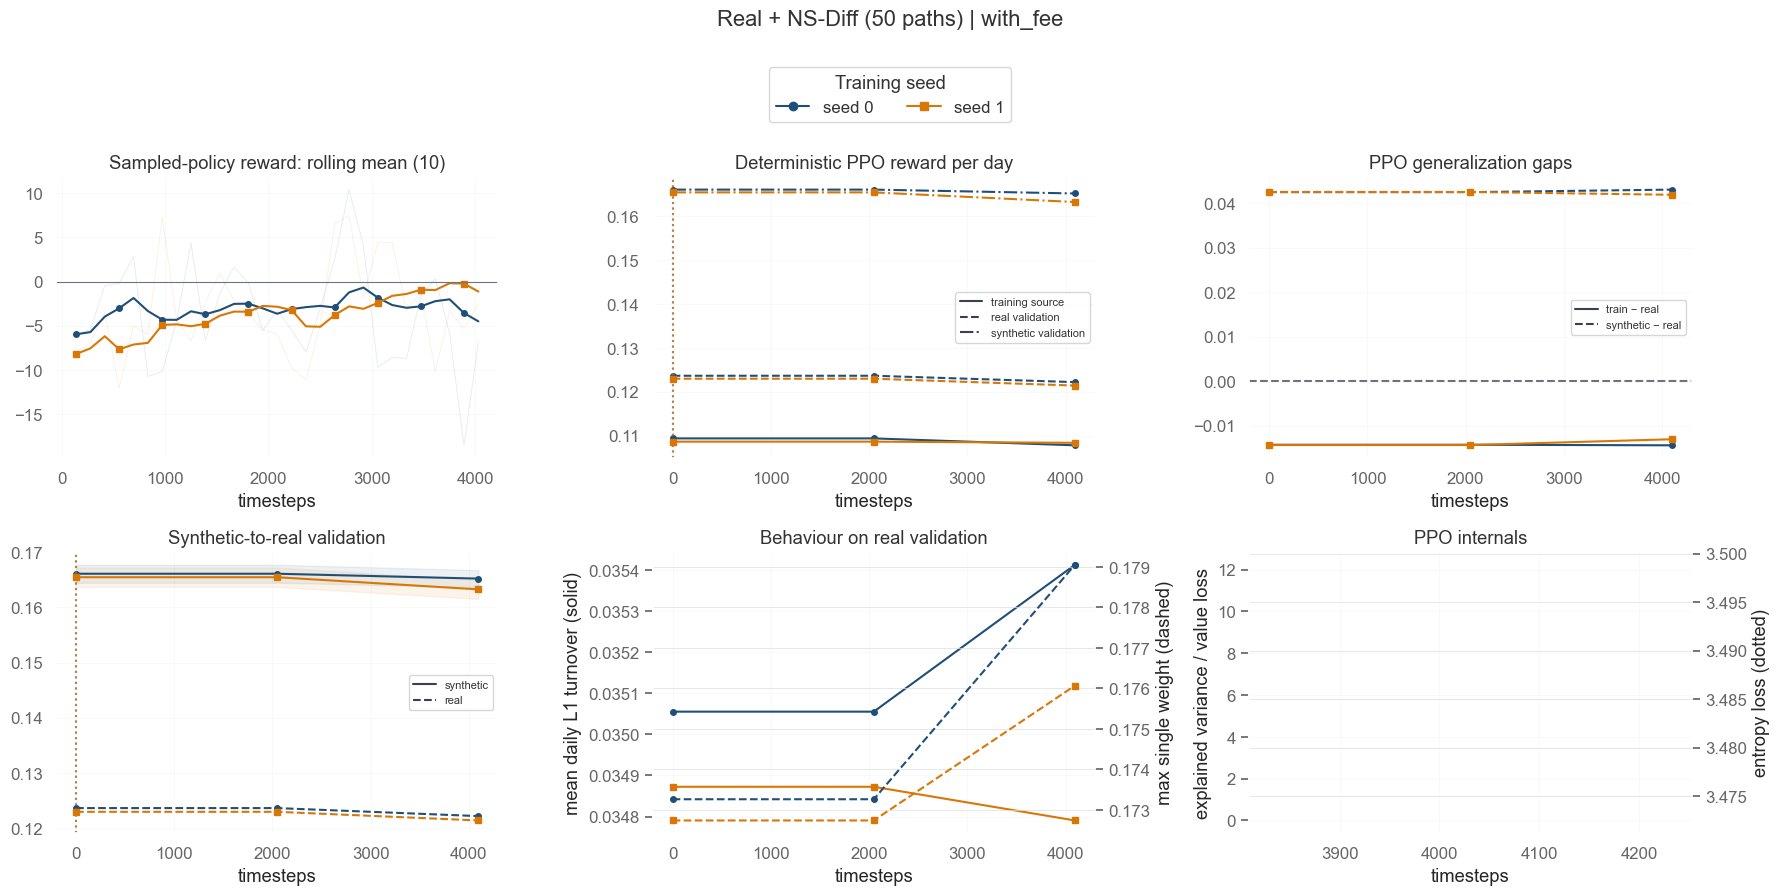

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/real_synthetic_nsdiff__50_paths_c63fbd5a__with_fee__learning_curves_all_seeds.png


In [11]:
GROUP_LABELS = {
    group: training_group_label(group) for group in TRAINING_GROUPS
}


def load_run_logs(record: dict) -> tuple[pd.DataFrame, pd.DataFrame]:
    run_dir = Path(record["best_model_path"]).parent
    return (
        pd.read_csv(run_dir / "training_log.csv"),
        pd.read_csv(run_dir / "validation_log.csv"),
    )


def plot_single_seed_learning_curves(record: dict) -> None:
    train_log, valid_log = load_run_logs(record)
    run_dir = Path(record["best_model_path"]).parent
    label = GROUP_LABELS[record["group"]]
    best_timestep = int(record["best_timestep"])
    fig, axes = plt.subplots(2, 3, figsize=(17, 8))

    axis = axes[0, 0]
    if not train_log.empty:
        axis.plot(
            train_log["timesteps"],
            train_log["episode_reward"],
            alpha=0.3,
            label="episode",
        )
        axis.plot(
            train_log["timesteps"],
            train_log["episode_reward"].rolling(10, min_periods=1).mean(),
            label="rolling mean (10)",
        )
    axis.axhline(0, color="grey", linewidth=0.8)
    axis.set_title("Sampled-policy episode reward")
    axis.set_xlabel("timesteps")
    axis.legend(fontsize=8)

    axis = axes[0, 1]
    axis.plot(
        valid_log["timesteps"],
        valid_log["train_reward_mean"],
        "o-",
        label="training-source mean",
    )
    axis.plot(
        valid_log["timesteps"],
        valid_log["real_valid_reward"],
        "o-",
        label="real validation",
    )
    if valid_log["synthetic_valid_reward_mean"].notna().any():
        axis.plot(
            valid_log["timesteps"],
            valid_log["synthetic_valid_reward_mean"],
            "o-",
            label="synthetic validation mean",
        )
    axis.axvline(best_timestep, color="green", linestyle=":", label="best")
    axis.set_title("Deterministic PPO reward per day")
    axis.set_xlabel("timesteps")
    axis.legend(fontsize=8)

    axis = axes[0, 2]
    axis.plot(
        valid_log["timesteps"],
        valid_log["train_reward_mean"] - valid_log["real_valid_reward"],
        "o-",
        label="train − real validation",
    )
    if valid_log["synthetic_valid_reward_mean"].notna().any():
        axis.plot(
            valid_log["timesteps"],
            valid_log["synthetic_valid_reward_mean"]
            - valid_log["real_valid_reward"],
            "o-",
            label="synthetic − real validation",
        )
    axis.axhline(0, color="grey", linestyle="--")
    axis.axvline(best_timestep, color="green", linestyle=":")
    axis.set_title("PPO generalization gaps")
    axis.set_xlabel("timesteps")
    axis.legend(fontsize=8)

    axis = axes[1, 0]
    if valid_log["synthetic_valid_reward_mean"].notna().any():
        mean = valid_log["synthetic_valid_reward_mean"]
        std = valid_log["synthetic_valid_reward_std"].fillna(0)
        axis.plot(valid_log["timesteps"], mean, "o-", label="synthetic mean")
        axis.fill_between(valid_log["timesteps"], mean - std, mean + std, alpha=0.2)
        axis.plot(
            valid_log["timesteps"],
            valid_log["real_valid_reward"],
            "o-",
            label="real validation",
        )
        axis.set_title("Synthetic-to-real validation")
    else:
        axis.plot(
            valid_log["timesteps"],
            valid_log["real_valid_reward"],
            "o-",
            color="C1",
            label="real validation",
        )
        axis.set_title("Real validation")
    axis.axvline(best_timestep, color="green", linestyle=":")
    axis.set_xlabel("timesteps")
    axis.legend(fontsize=8)

    axis = axes[1, 1]
    axis.plot(
        valid_log["timesteps"],
        valid_log["real_valid_turnover"],
        "o-",
        color="C2",
        label="turnover",
    )
    axis.set_ylabel("mean daily L1 turnover")
    axis.set_xlabel("timesteps")
    twin = axis.twinx()
    twin.plot(
        valid_log["timesteps"],
        valid_log["real_valid_max_weight"],
        "o-",
        color="C4",
        label="max weight",
    )
    twin.set_ylabel("max single weight")
    axis.set_title("Behaviour on real validation")
    axis.legend(loc="upper left", fontsize=8)
    twin.legend(loc="upper right", fontsize=8)

    axis = axes[1, 2]
    for column, color in [("explained_variance", "C0"), ("value_loss", "C2")]:
        if column in train_log and train_log[column].notna().any():
            axis.plot(train_log["timesteps"], train_log[column], color=color, label=column)
    axis.set_xlabel("timesteps")
    twin = axis.twinx()
    if "entropy_loss" in train_log and train_log["entropy_loss"].notna().any():
        twin.plot(
            train_log["timesteps"],
            train_log["entropy_loss"],
            color="C3",
            label="entropy_loss",
        )
    axis.set_title("PPO internals")
    axis.legend(loc="upper left", fontsize=8)
    twin.legend(loc="upper right", fontsize=8)

    fig.suptitle(
        f"{label} | {record['commission_name']} | seed {record['seed']}"
    )
    fig.tight_layout()
    figure_path = run_dir / "learning_curves.png"
    fig.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("saved:", figure_path)


SEED_COLORS = ["#1F4E79", "#D97706", "#708238", "#C2416C", "#B58900"]
SEED_MARKERS = ["o", "s", "^", "D", "P"]


def plot_learning_curves(records: list[dict]) -> None:
    """Overlay all seeds for one training source and commission setting."""
    if not records:
        return
    records = sorted(records, key=lambda item: int(item["seed"]))
    group = records[0]["group"]
    commission_name = records[0]["commission_name"]
    if any(
        record["group"] != group
        or record["commission_name"] != commission_name
        for record in records
    ):
        raise ValueError("Records must share a training source and fee config")

    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    behaviour_twin = axes[1, 1].twinx()
    internals_twin = axes[1, 2].twinx()
    has_synthetic_validation = False
    seed_handles = []

    for index, record in enumerate(records):
        train_log, valid_log = load_run_logs(record)
        seed = int(record["seed"])
        color = SEED_COLORS[index % len(SEED_COLORS)]
        marker = SEED_MARKERS[index % len(SEED_MARKERS)]
        marker_stride = max(len(valid_log) // 8, 1)
        best_timestep = int(record["best_timestep"])
        line_kwargs = {
            "color": color,
            "marker": marker,
            "markevery": marker_stride,
            "markersize": 4,
            "linewidth": 1.5,
        }
        seed_handles.append(
            Line2D(
                [0], [0], color=color, marker=marker, label=f"seed {seed}"
            )
        )

        if not train_log.empty:
            axes[0, 0].plot(
                train_log["timesteps"],
                train_log["episode_reward"],
                color=color,
                alpha=0.1,
                linewidth=0.7,
            )
            rolling_reward = train_log["episode_reward"].rolling(
                10, min_periods=1
            ).mean()
            train_stride = max(len(train_log) // 8, 1)
            axes[0, 0].plot(
                train_log["timesteps"],
                rolling_reward,
                color=color,
                marker=marker,
                markevery=train_stride,
                markersize=4,
                linewidth=1.5,
            )

        reward_specs = [
            ("train_reward_mean", "training source", "-"),
            ("real_valid_reward", "real validation", "--"),
            ("synthetic_valid_reward_mean", "synthetic validation", "-."),
        ]
        for column, _, linestyle in reward_specs:
            if column in valid_log and valid_log[column].notna().any():
                axes[0, 1].plot(
                    valid_log["timesteps"],
                    valid_log[column],
                    linestyle=linestyle,
                    **line_kwargs,
                )
        synthetic_available = (
            "synthetic_valid_reward_mean" in valid_log
            and valid_log["synthetic_valid_reward_mean"].notna().any()
        )
        has_synthetic_validation |= synthetic_available
        axes[0, 1].axvline(
            best_timestep, color=color, linestyle=":", alpha=0.6
        )

        axes[0, 2].plot(
            valid_log["timesteps"],
            valid_log["train_reward_mean"] - valid_log["real_valid_reward"],
            linestyle="-",
            **line_kwargs,
        )
        if synthetic_available:
            axes[0, 2].plot(
                valid_log["timesteps"],
                valid_log["synthetic_valid_reward_mean"]
                - valid_log["real_valid_reward"],
                linestyle="--",
                **line_kwargs,
            )

        if synthetic_available:
            synthetic_mean = valid_log["synthetic_valid_reward_mean"]
            synthetic_std = valid_log[
                "synthetic_valid_reward_std"
            ].fillna(0)
            axes[1, 0].plot(
                valid_log["timesteps"],
                synthetic_mean,
                linestyle="-",
                **line_kwargs,
            )
            axes[1, 0].fill_between(
                valid_log["timesteps"],
                synthetic_mean - synthetic_std,
                synthetic_mean + synthetic_std,
                color=color,
                alpha=0.08,
            )
        axes[1, 0].plot(
            valid_log["timesteps"],
            valid_log["real_valid_reward"],
            linestyle="--",
            **line_kwargs,
        )
        axes[1, 0].axvline(
            best_timestep, color=color, linestyle=":", alpha=0.6
        )

        axes[1, 1].plot(
            valid_log["timesteps"],
            valid_log["real_valid_turnover"],
            linestyle="-",
            **line_kwargs,
        )
        behaviour_twin.plot(
            valid_log["timesteps"],
            valid_log["real_valid_max_weight"],
            linestyle="--",
            **line_kwargs,
        )

        for column, linestyle in [
            ("explained_variance", "-"),
            ("value_loss", "--"),
        ]:
            if column in train_log and train_log[column].notna().any():
                axes[1, 2].plot(
                    train_log["timesteps"],
                    train_log[column],
                    color=color,
                    linestyle=linestyle,
                    linewidth=1.5,
                )
        if "entropy_loss" in train_log and train_log["entropy_loss"].notna().any():
            internals_twin.plot(
                train_log["timesteps"],
                train_log["entropy_loss"],
                color=color,
                linestyle=":",
                linewidth=1.5,
            )

    axes[0, 0].axhline(0, color="#6B7280", linewidth=0.8)
    axes[0, 0].set_title("Sampled-policy reward: rolling mean (10)")
    axes[0, 1].set_title("Deterministic PPO reward per day")
    axes[0, 1].legend(
        handles=[
            Line2D([0], [0], color="#374151", linestyle=style, label=label)
            for _, label, style in reward_specs
            if label != "synthetic validation" or has_synthetic_validation
        ],
        fontsize=8,
    )
    axes[0, 2].axhline(0, color="#6B7280", linestyle="--")
    axes[0, 2].set_title("PPO generalization gaps")
    axes[0, 2].legend(
        handles=[
            Line2D([0], [0], color="#374151", linestyle="-", label="train − real"),
            Line2D([0], [0], color="#374151", linestyle="--", label="synthetic − real"),
        ][: 2 if has_synthetic_validation else 1],
        fontsize=8,
    )
    axes[1, 0].set_title(
        "Synthetic-to-real validation"
        if has_synthetic_validation
        else "Real validation"
    )
    axes[1, 0].legend(
        handles=(
            [
                Line2D([0], [0], color="#374151", linestyle="-", label="synthetic"),
                Line2D([0], [0], color="#374151", linestyle="--", label="real"),
            ]
            if has_synthetic_validation
            else [Line2D([0], [0], color="#374151", linestyle="--", label="real")]
        ),
        fontsize=8,
    )
    axes[1, 1].set_title("Behaviour on real validation")
    axes[1, 1].set_ylabel("mean daily L1 turnover (solid)")
    behaviour_twin.set_ylabel("max single weight (dashed)")
    axes[1, 2].set_title("PPO internals")
    axes[1, 2].set_ylabel("explained variance / value loss")
    internals_twin.set_ylabel("entropy loss (dotted)")

    for axis in axes.ravel():
        axis.set_xlabel("timesteps")
        axis.grid(alpha=0.2, color="#D1D5DB")
    fig.legend(
        handles=seed_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.94),
        ncol=len(seed_handles),
        title="Training seed",
    )
    fig.suptitle(f"{GROUP_LABELS[group]} | {commission_name}", y=0.995)
    fig.tight_layout(rect=(0, 0, 1, 0.9))
    figure_path = EXPERIMENT_ROOT / (
        f"{run_id(group, commission_name, 0).rsplit('__seed_', 1)[0]}"
        "__learning_curves_all_seeds.png"
    )
    fig.savefig(figure_path, dpi=160, bbox_inches="tight")
    plt.show()
    print("saved:", figure_path)


for group in TRAINING_GROUPS:
    for commission_name in COMMISSION_CONFIGS:
        plot_learning_curves(
            [
                record
                for record in run_records
                if record["group"] == group
                and record["commission_name"] == commission_name
            ]
        )


### How to read these

- The deterministic reward panel shows whether training-source reward keeps improving
  while common real-validation reward stalls or falls.
- A widening positive generalization gap is evidence of source-specific overfitting.
- For synthetic runs, divergence between synthetic and real validation suggests a
  distribution mismatch.
- Rising turnover without a real-validation improvement suggests noise trading;
  maximum weight near one indicates concentration in a single asset.
- As in the Demo notebook, sampled-policy episode reward is a training diagnostic,
  not deterministic investment performance.


## 8. Backtest

Following the Demo notebook, this section loads each best validation checkpoint—not
the final model—and evaluates it separately on the common real train, validation,
and test periods. Each period restarts from the initial capital, while the test period
remains continuous within 2025. Every PPO uses its source-fitted scaler. A common
uniform buy-and-hold baseline is evaluated on the same real dates.


In [12]:
REAL_BACKTEST_PERIODS = {
    "train": {"real": "train", "synthetic": "real_train"},
    "validation": {"real": "real_valid", "synthetic": "real_valid"},
    "test": {"real": "real_test", "synthetic": "real_test"},
}

ppo_period_rows = []
benchmark_rows = []
equity_rows = []

for record in run_records:
    group = record["group"]
    model_name = record["model_name"]
    commission_name = record["commission_name"]
    commission = float(record["commission"])
    seed = int(record["seed"])
    model = PPO.load(record["best_model_path"], device=DEVICE)

    for period, keys in REAL_BACKTEST_PERIODS.items():
        period_frame = (
            real_pipeline[keys["real"]]
            if group == "real_trained"
            else synthetic_pipelines[model_name][keys["synthetic"]]
        )
        result = rollout(period_frame, model, env_kwargs(commission), seed)
        ppo_period_rows.append(
            {
                "run_id": record["run_id"],
                "period": period,
                "agent": GROUP_LABELS[group],
                "agent_type": "PPO",
                "group": group,
                "model_name": model_name,
                "commission_name": commission_name,
                "commission": commission,
                "seed": seed,
                "best_timestep": int(record["best_timestep"]),
                **performance_metrics(result),
            }
        )
        normalized_values = result["values"] / result["values"][0]
        for date, value in zip(result["dates"], normalized_values):
            equity_rows.append(
                {
                    "date": pd.Timestamp(date),
                    "period": period,
                    "agent": GROUP_LABELS[group],
                    "agent_type": "PPO",
                    "group": group,
                    "model_name": model_name,
                    "commission_name": commission_name,
                    "seed": seed,
                    "growth_of_one": float(value),
                }
            )

# Buy-and-hold is deterministic, so evaluate it once per period and fee.
for period, keys in REAL_BACKTEST_PERIODS.items():
    for commission_name, commission in COMMISSION_CONFIGS.items():
        result = rollout(
            real_pipeline[keys["real"]],
            model=None,
            kwargs=env_kwargs(commission),
            seed=SEEDS[0],
        )
        benchmark_rows.append(
            {
                "run_id": f"buy_and_hold__{period}__{commission_name}",
                "period": period,
                "agent": "Buy & Hold",
                "agent_type": "Buy & Hold",
                "group": "buy_and_hold",
                "model_name": None,
                "commission_name": commission_name,
                "commission": commission,
                "seed": pd.NA,
                "best_timestep": np.nan,
                **performance_metrics(result),
            }
        )
        normalized_values = result["values"] / result["values"][0]
        for date, value in zip(result["dates"], normalized_values):
            equity_rows.append(
                {
                    "date": pd.Timestamp(date),
                    "period": period,
                    "agent": "Buy & Hold",
                    "agent_type": "Buy & Hold",
                    "group": "buy_and_hold",
                    "model_name": None,
                    "commission_name": commission_name,
                    "seed": pd.NA,
                    "growth_of_one": float(value),
                }
            )

ppo_period_results = pd.DataFrame(ppo_period_rows)
test_results = ppo_period_results.loc[
    ppo_period_results["period"] == "test"
].reset_index(drop=True)
benchmark_results = pd.DataFrame(benchmark_rows)
backtest_results = pd.concat(
    [ppo_period_results, benchmark_results], ignore_index=True
)
equity_curves = pd.DataFrame(equity_rows)
EXPERIMENT_ROOT.mkdir(parents=True, exist_ok=True)
ppo_period_results.to_csv(
    EXPERIMENT_ROOT / "ppo_period_metrics.csv", index=False
)
test_results.to_csv(EXPERIMENT_ROOT / "test_metrics.csv", index=False)
benchmark_results.to_csv(
    EXPERIMENT_ROOT / "buy_and_hold_metrics.csv", index=False
)
backtest_results.to_csv(
    EXPERIMENT_ROOT / "backtest_results.csv", index=False
)
equity_curves.to_csv(EXPERIMENT_ROOT / "equity_curves.csv", index=False)

print(
    "saved backtest data:",
    f"{len(ppo_period_results)} PPO period rows and "
    f"{len(equity_curves):,} equity observations",
)


saved backtest data: 132 PPO period rows and 20,930 equity observations


### Median-Sharpe representative backtests

For each training source and fee configuration, the representative run is the seed
whose **test Sharpe is closest to the within-group median**. The charts show both the
seed-level Sharpe distribution and the selected run. This is a descriptive, post-hoc
summary—not a model-selection rule or significance test. Full numerical results are
still exported to CSV for auditability.


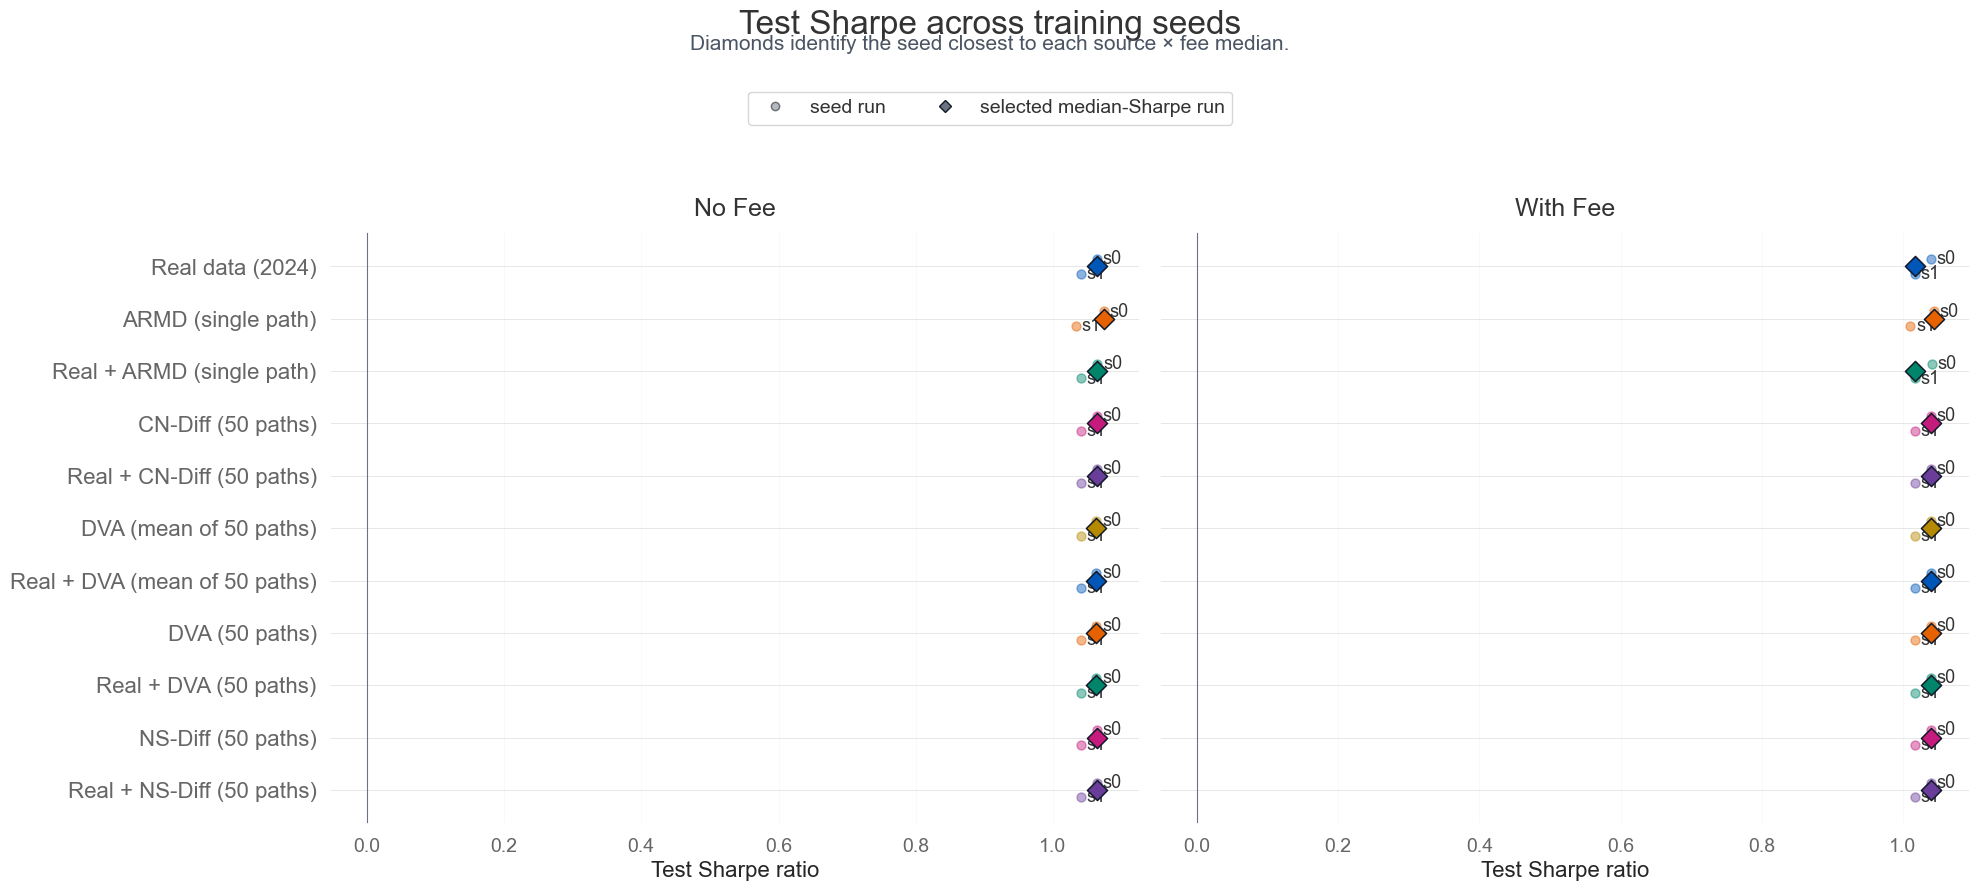

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/median_sharpe_seed_selection.png


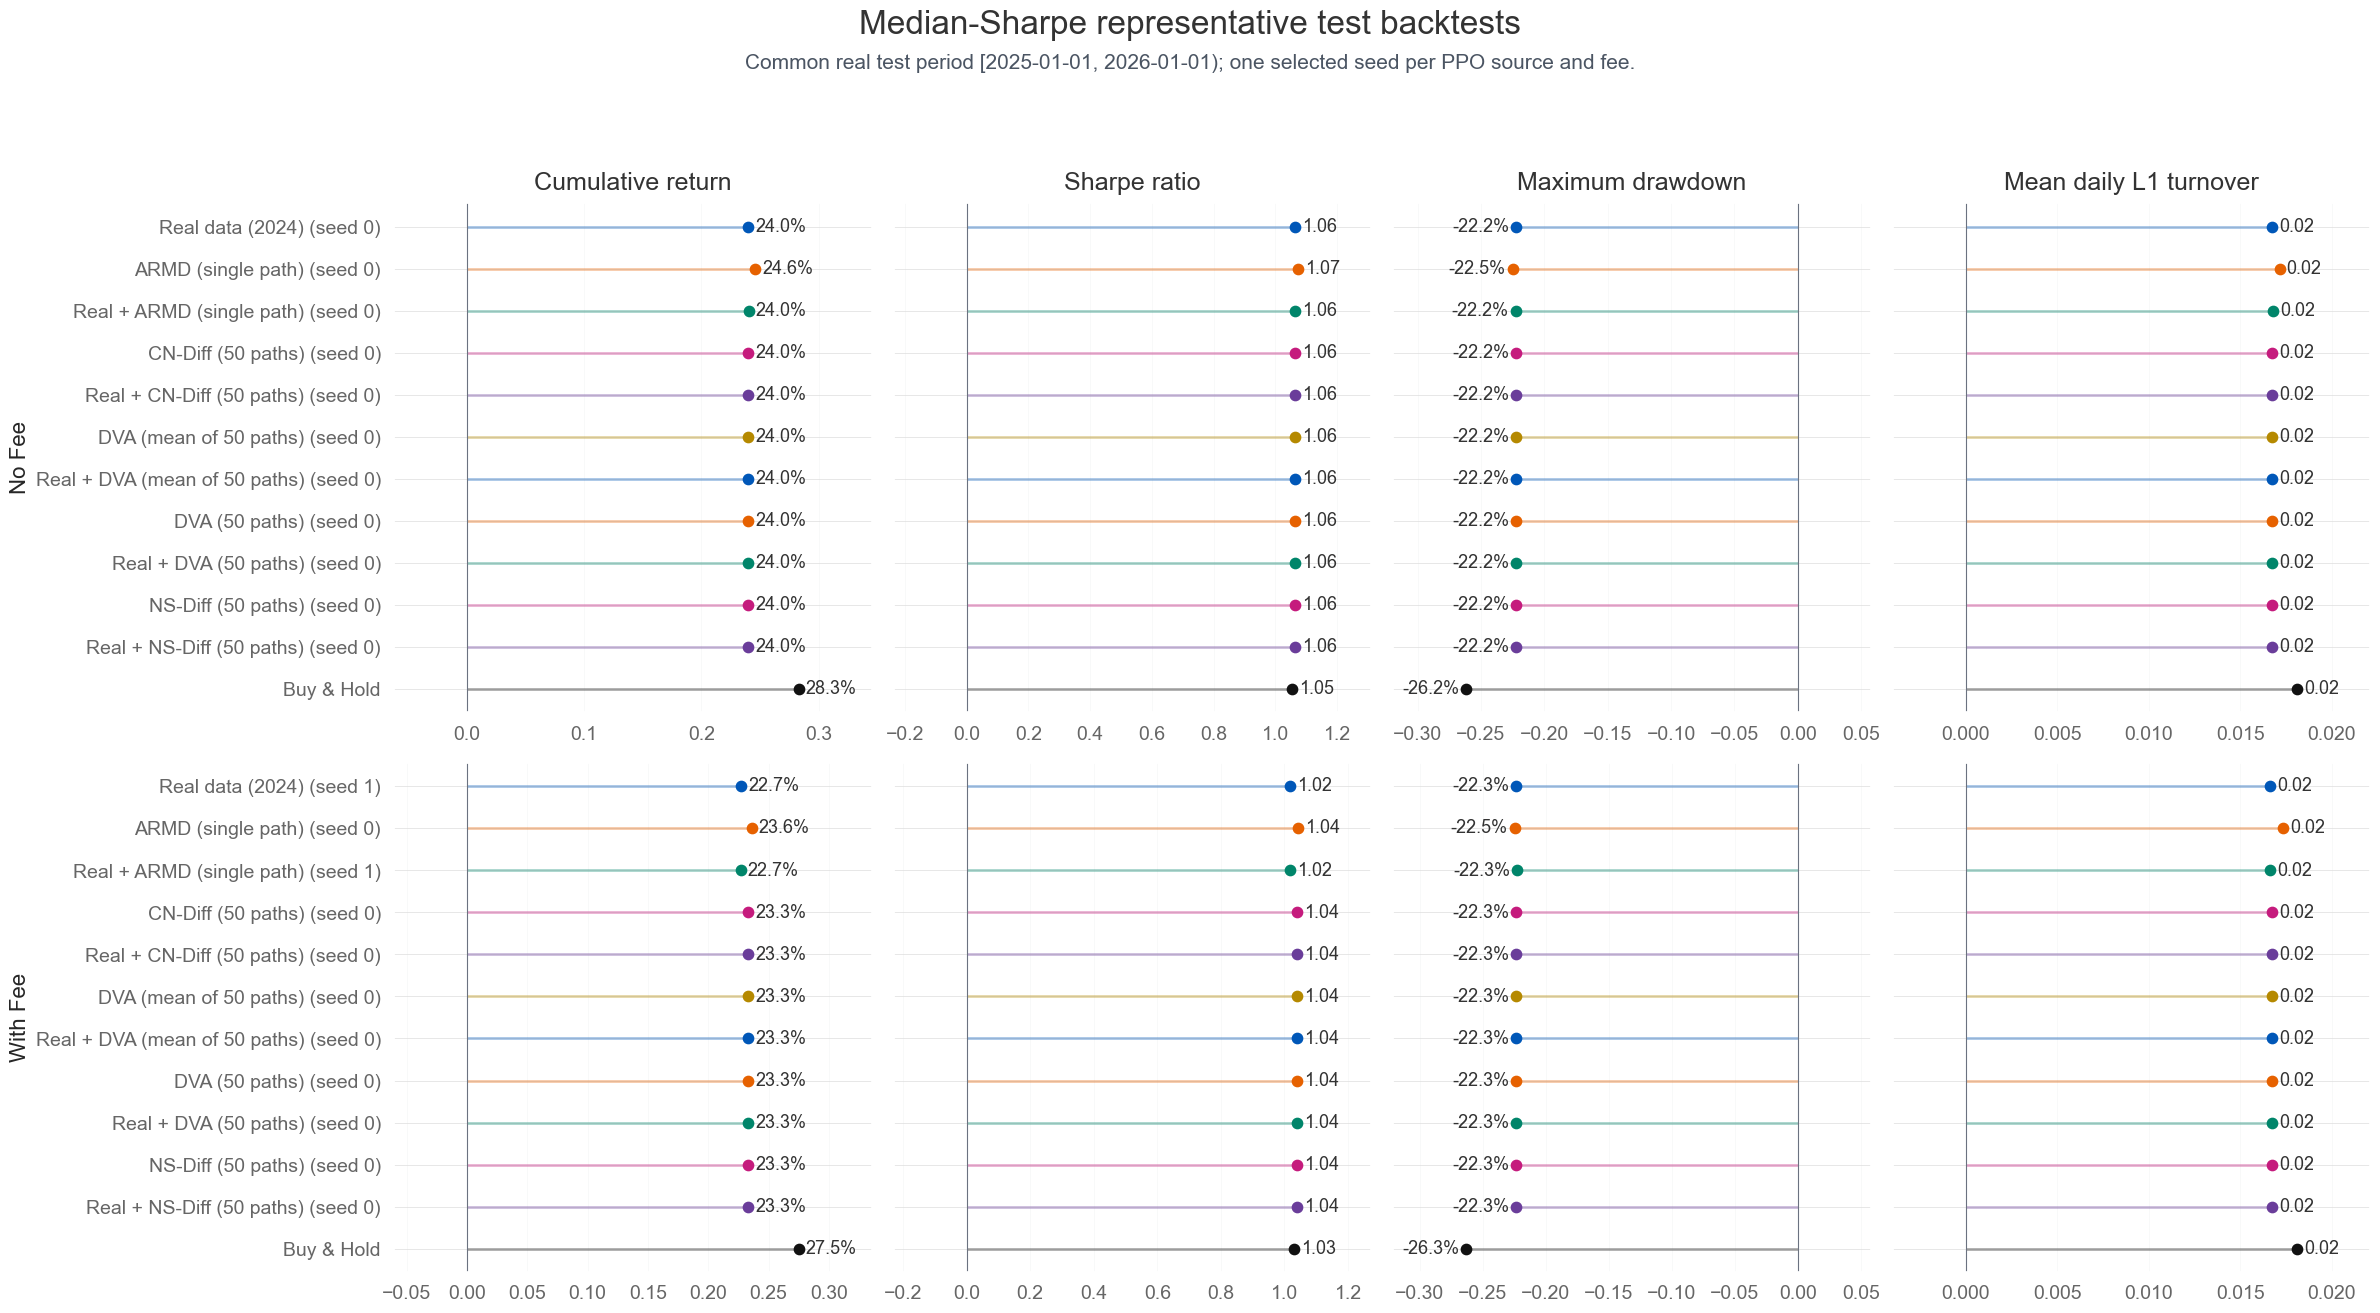

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/median_sharpe_test_metrics.png


In [13]:
METRIC_COLUMNS = [
    "cumulative_return",
    "cagr",
    "sharpe",
    "annualized_volatility",
    "max_drawdown",
    "turnover",
    "best_timestep",
]

aggregate_summary = test_results.groupby(
    ["commission_name", "group"]
)[METRIC_COLUMNS].agg(["mean", "std"])
aggregate_summary.columns = [
    f"{metric}_{stat}" for metric, stat in aggregate_summary.columns
]
aggregate_summary = aggregate_summary.reset_index()
aggregate_summary["agent"] = aggregate_summary["group"].map(GROUP_LABELS)
aggregate_summary.to_csv(
    EXPERIMENT_ROOT / "aggregate_summary.csv", index=False
)

paired_rows = []
for commission_name in COMMISSION_CONFIGS:
    subset = test_results[
        test_results["commission_name"] == commission_name
    ]
    for seed in SEEDS:
        pair = subset[subset["seed"] == seed].set_index("group")
        if "real_trained" not in pair.index:
            continue
        for model_name in SYNTHETIC_MODEL_NAMES:
            comparison_groups = [
                synthetic_group(model_name),
                real_synthetic_group(model_name),
            ]
            for group in comparison_groups:
                if group not in pair.index:
                    continue
                row = {
                    "commission_name": commission_name,
                    "seed": seed,
                    "model_name": model_name,
                    "model_label": synthetic_model_label(model_name),
                    "training_group": group,
                    "training_group_label": training_group_label(group),
                }
                for metric in METRIC_COLUMNS:
                    row[f"delta_{metric}"] = float(
                        pair.loc[group, metric]
                        - pair.loc["real_trained", metric]
                    )
                paired_rows.append(row)

paired_deltas = pd.DataFrame(paired_rows)
paired_deltas.to_csv(EXPERIMENT_ROOT / "paired_deltas.csv", index=False)

# Select the seed nearest the median test Sharpe for each source × fee pair.
representative_rows = []
for (commission_name, group), subset in test_results.groupby(
    ["commission_name", "group"], sort=False
):
    candidates = subset.dropna(subset=["sharpe"]).copy()
    if candidates.empty:
        ordered = subset.sort_values("seed").reset_index(drop=True)
        selected = ordered.iloc[len(ordered) // 2].copy()
        median_sharpe = np.nan
        sharpe_distance = np.nan
    else:
        median_sharpe = float(candidates["sharpe"].median())
        candidates["_sharpe_distance"] = (
            candidates["sharpe"] - median_sharpe
        ).abs()
        selected = candidates.sort_values(
            ["_sharpe_distance", "seed"]
        ).iloc[0].copy()
        sharpe_distance = float(selected["_sharpe_distance"])
    selected["median_test_sharpe"] = median_sharpe
    selected["sharpe_distance_to_median"] = sharpe_distance
    representative_rows.append(selected.drop(labels=["_sharpe_distance"], errors="ignore"))

representative_test_runs = pd.DataFrame(representative_rows).reset_index(drop=True)
representative_test_runs.to_csv(
    EXPERIMENT_ROOT / "median_sharpe_representatives.csv", index=False
)

# Retain aggregate and benchmark comparison CSVs for auditability.
COMPARISON_METRICS = [metric for metric in METRIC_COLUMNS if metric != "best_timestep"]
ppo_comparison = aggregate_summary[
    ["commission_name", "agent"]
    + [
        f"{metric}_{stat}"
        for metric in COMPARISON_METRICS
        for stat in ["mean", "std"]
    ]
].copy()

benchmark_comparison_rows = []
test_benchmark_results = benchmark_results.loc[
    benchmark_results["period"] == "test"
]
for _, row in test_benchmark_results.iterrows():
    output = {
        "commission_name": row["commission_name"],
        "agent": row["agent"],
    }
    for metric in COMPARISON_METRICS:
        output[f"{metric}_mean"] = row[metric]
        output[f"{metric}_std"] = np.nan
    benchmark_comparison_rows.append(output)

comparison_summary = pd.concat(
    [ppo_comparison, pd.DataFrame(benchmark_comparison_rows)],
    ignore_index=True,
)
comparison_summary.to_csv(
    EXPERIMENT_ROOT / "ppo_vs_buy_and_hold_summary.csv", index=False
)

AGENT_COLOR_PALETTE = [
    "#0057B8",
    "#E66100",
    "#00856A",
    "#C51B7D",
    "#6A3D9A",
    "#B58900",
]
AGENT_COLORS = {
    group: AGENT_COLOR_PALETTE[index % len(AGENT_COLOR_PALETTE)]
    for index, group in enumerate(TRAINING_GROUPS)
}
AGENT_COLORS["buy_and_hold"] = "#111111"
AGENT_MARKER_PALETTE = ["o", "s", "^", "D", "P", "X"]
AGENT_MARKERS = {
    group: AGENT_MARKER_PALETTE[index % len(AGENT_MARKER_PALETTE)]
    for index, group in enumerate(TRAINING_GROUPS)
}
COMPARISON_ORDER = [*TRAINING_GROUPS, "buy_and_hold"]
BACKTEST_SUPTITLE_FONTSIZE = 24
BACKTEST_TITLE_FONTSIZE = 18
BACKTEST_LABEL_FONTSIZE = 16
BACKTEST_TICK_FONTSIZE = 14
BACKTEST_ANNOTATION_FONTSIZE = 13
BACKTEST_LEGEND_FONTSIZE = 14
BACKTEST_SUBTITLE_FONTSIZE = 15

# Show every seed's test Sharpe and highlight the median-Sharpe representative.
fig, axes = plt.subplots(
    1, len(COMMISSION_CONFIGS), figsize=(20, 9), sharey=True, squeeze=False
)
for axis, commission_name in zip(axes.ravel(), COMMISSION_CONFIGS):
    for y_position, group in enumerate(TRAINING_GROUPS):
        seed_rows = test_results.loc[
            (test_results["commission_name"] == commission_name)
            & (test_results["group"] == group)
        ].sort_values("seed")
        offsets = np.linspace(-0.14, 0.14, max(len(seed_rows), 1))
        for offset, (_, row) in zip(offsets, seed_rows.iterrows()):
            if pd.isna(row["sharpe"]):
                continue
            axis.scatter(
                row["sharpe"],
                y_position + offset,
                s=42,
                color=AGENT_COLORS[group],
                alpha=0.45,
            )
            axis.annotate(
                f"s{int(row['seed'])}",
                (row["sharpe"], y_position + offset),
                xytext=(4, 0),
                textcoords="offset points",
                fontsize=BACKTEST_ANNOTATION_FONTSIZE,
                va="center",
            )
        selected = representative_test_runs.loc[
            (representative_test_runs["commission_name"] == commission_name)
            & (representative_test_runs["group"] == group)
        ].iloc[0]
        axis.scatter(
            selected["sharpe"],
            y_position,
            s=105,
            marker="D",
            color=AGENT_COLORS[group],
            edgecolor="#111827",
            linewidth=1.1,
            zorder=4,
        )
    axis.axvline(0, color="#6B7280", linewidth=0.8)
    axis.set_title(
        f"{commission_name.replace('_', ' ').title()}",
        fontsize=BACKTEST_TITLE_FONTSIZE,
        pad=12,
    )
    axis.set_xlabel("Test Sharpe ratio", fontsize=BACKTEST_LABEL_FONTSIZE)
    axis.tick_params(axis="both", labelsize=BACKTEST_TICK_FONTSIZE)
    axis.grid(axis="x", alpha=0.2, color="#D1D5DB")
axes.ravel()[0].set_yticks(
    range(len(TRAINING_GROUPS)),
    [GROUP_LABELS[group] for group in TRAINING_GROUPS],
    fontsize=BACKTEST_LABEL_FONTSIZE,
)
axes.ravel()[0].invert_yaxis()
fig.legend(
    handles=[
        Line2D([0], [0], marker="o", color="none", markerfacecolor="#6B7280", alpha=0.5, label="seed run"),
        Line2D([0], [0], marker="D", color="none", markerfacecolor="#6B7280", markeredgecolor="#111827", label="selected median-Sharpe run"),
    ],
    loc="upper center",
    bbox_to_anchor=(0.5, 0.91),
    ncol=2,
    fontsize=BACKTEST_LEGEND_FONTSIZE,
)
fig.suptitle(
    "Test Sharpe across training seeds",
    y=0.99,
    fontsize=BACKTEST_SUPTITLE_FONTSIZE,
)
fig.text(
    0.5,
    0.945,
    "Diamonds identify the seed closest to each source × fee median.",
    ha="center",
    fontsize=BACKTEST_SUBTITLE_FONTSIZE,
    color="#4B5563",
)
fig.tight_layout(rect=(0, 0, 1, 0.86))
sharpe_selection_figure_path = (
    EXPERIMENT_ROOT / "median_sharpe_seed_selection.png"
)
fig.savefig(sharpe_selection_figure_path, dpi=160, bbox_inches="tight")
plt.show()
print("saved:", sharpe_selection_figure_path)

# Compare representative test outcomes without a wide numeric table.
test_benchmark_results = benchmark_results.loc[
    benchmark_results["period"] == "test"
]
representative_comparison = pd.concat(
    [representative_test_runs, test_benchmark_results], ignore_index=True
)
metric_plot_specs = [
    ("cumulative_return", "Cumulative return", lambda value: f"{value:.1%}"),
    ("sharpe", "Sharpe ratio", lambda value: f"{value:.2f}"),
    ("max_drawdown", "Maximum drawdown", lambda value: f"{value:.1%}"),
    ("turnover", "Mean daily L1 turnover", lambda value: f"{value:.2f}"),
]
fig, axes = plt.subplots(
    len(COMMISSION_CONFIGS),
    len(metric_plot_specs),
    figsize=(24, 13),
    squeeze=False,
)
for row_index, commission_name in enumerate(COMMISSION_CONFIGS):
    fee_rows = representative_comparison.loc[
        representative_comparison["commission_name"] == commission_name
    ].set_index("group").reindex(COMPARISON_ORDER)
    y_positions = np.arange(len(COMPARISON_ORDER))
    row_labels = []
    for group, row in fee_rows.iterrows():
        if group == "buy_and_hold":
            row_labels.append("Buy & Hold")
        else:
            row_labels.append(
                f"{GROUP_LABELS[group]} (seed {int(row['seed'])})"
            )
    for column_index, (metric, title, formatter) in enumerate(metric_plot_specs):
        axis = axes[row_index, column_index]
        values = fee_rows[metric].astype(float).to_numpy()
        for position, group, value in zip(y_positions, COMPARISON_ORDER, values):
            if np.isnan(value):
                continue
            color = AGENT_COLORS[group]
            axis.hlines(position, 0, value, color=color, alpha=0.35, linewidth=2)
            axis.scatter(value, position, color=color, s=55, zorder=3)
            axis.annotate(
                formatter(value),
                (value, position),
                xytext=(5 if value >= 0 else -5, 0),
                textcoords="offset points",
                ha="left" if value >= 0 else "right",
                va="center",
                fontsize=BACKTEST_ANNOTATION_FONTSIZE,
            )
        axis.axvline(0, color="#6B7280", linewidth=0.8)
        axis.set_title(
            title if row_index == 0 else "",
            fontsize=BACKTEST_TITLE_FONTSIZE,
            pad=10,
        )
        axis.tick_params(axis="x", labelsize=BACKTEST_TICK_FONTSIZE)
        axis.grid(axis="x", alpha=0.2, color="#D1D5DB")
        axis.margins(x=0.22)
        axis.set_yticks(y_positions)
        if column_index == 0:
            axis.set_yticklabels(
                row_labels, fontsize=BACKTEST_TICK_FONTSIZE
            )
            axis.set_ylabel(
                commission_name.replace("_", " ").title(),
                fontsize=BACKTEST_LABEL_FONTSIZE,
            )
        else:
            axis.set_yticklabels([])
        axis.invert_yaxis()
fig.suptitle(
    "Median-Sharpe representative test backtests",
    y=1.01,
    fontsize=BACKTEST_SUPTITLE_FONTSIZE,
)
fig.text(
    0.5,
    0.965,
    f"Common real test period [{TEST_START}, {TEST_END}); one selected seed per PPO source and fee.",
    ha="center",
    fontsize=BACKTEST_SUBTITLE_FONTSIZE,
    color="#4B5563",
)
fig.tight_layout(rect=(0, 0, 1, 0.94))
representative_metrics_figure_path = (
    EXPERIMENT_ROOT / "median_sharpe_test_metrics.png"
)
fig.savefig(representative_metrics_figure_path, dpi=160, bbox_inches="tight")
plt.show()
print("saved:", representative_metrics_figure_path)


## 9. Plots

Train, validation, and test are plotted separately. Each panel overlays the
median-test-Sharpe representative selected above for every PPO training source,
together with deterministic buy-and-hold. The same selected seed is carried across
all three periods so its path remains comparable. A compact table under each
panel reports the selected seed and ending value, ranked by ending growth of $1.


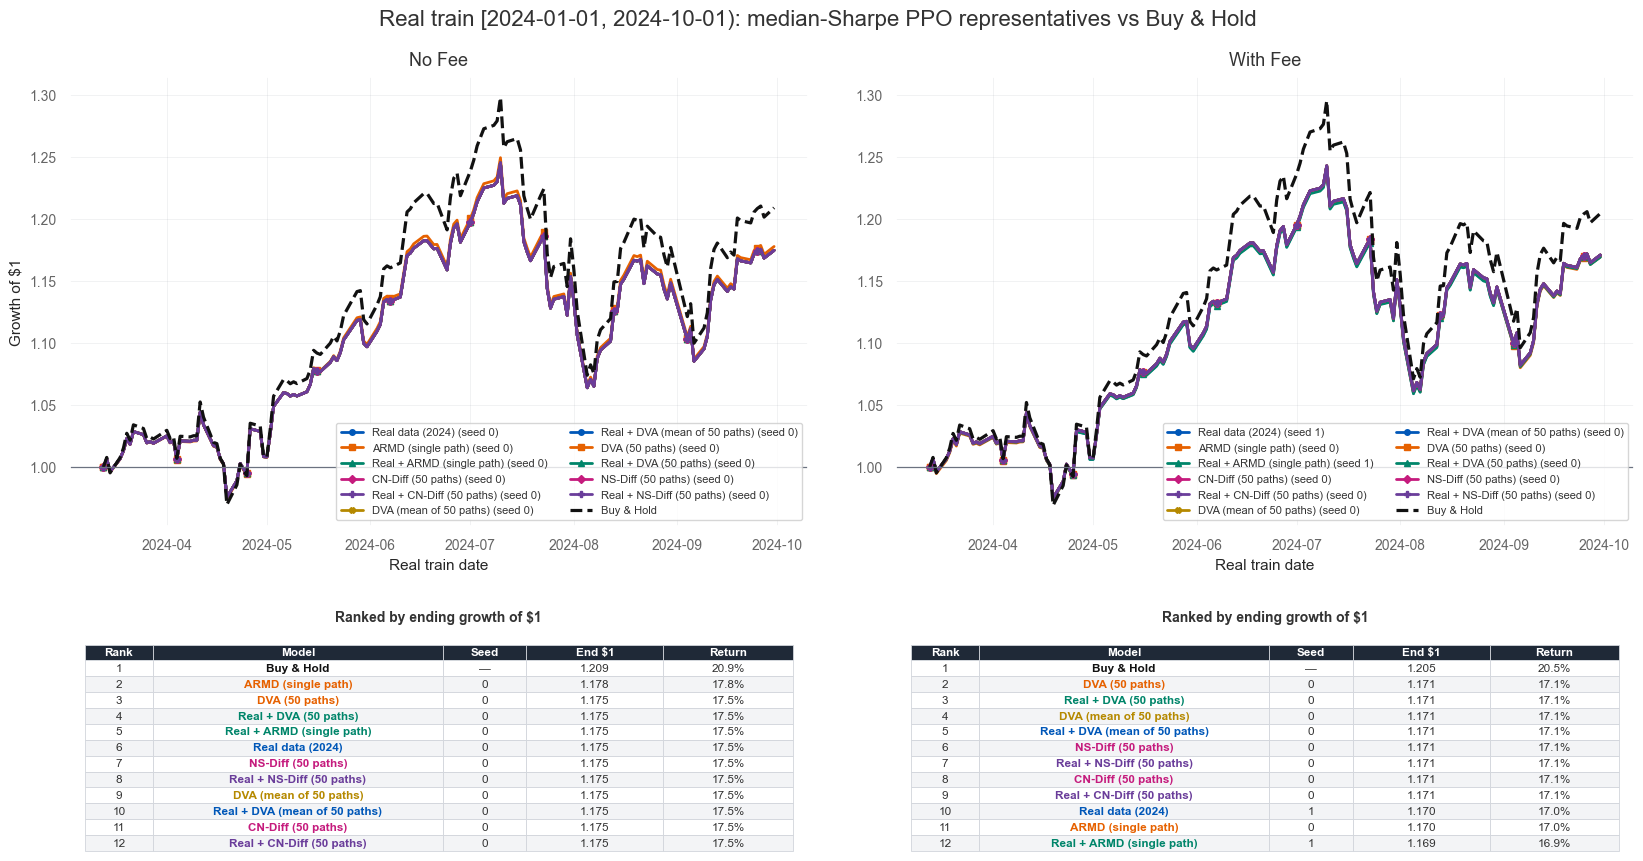

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/median_sharpe_ppo_vs_buy_and_hold_train_equity_curves.png


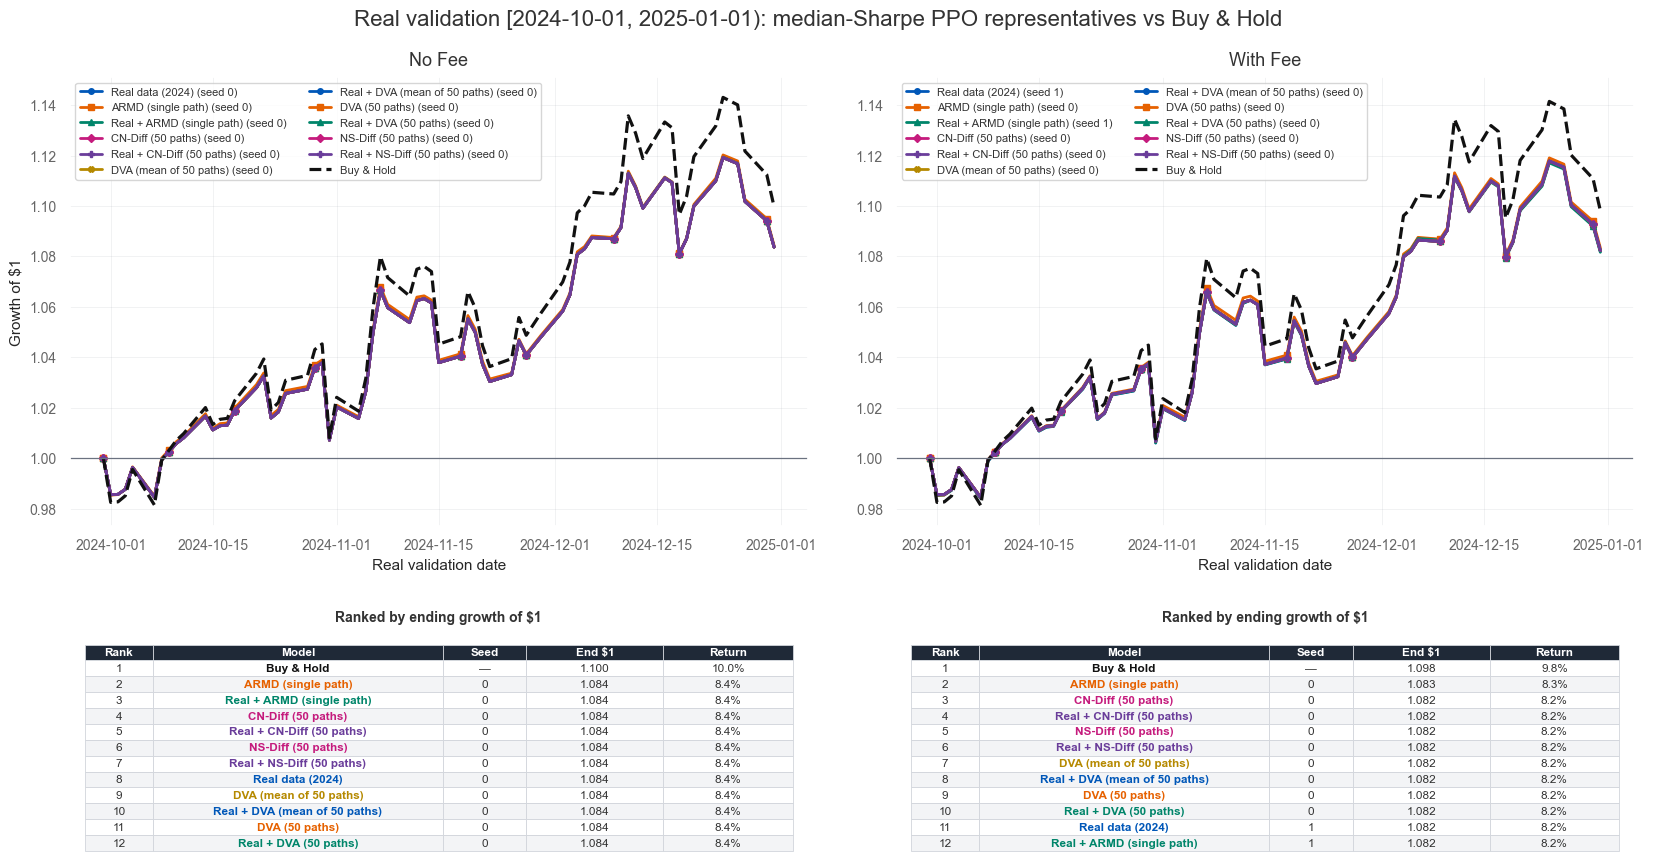

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/median_sharpe_ppo_vs_buy_and_hold_validation_equity_curves.png


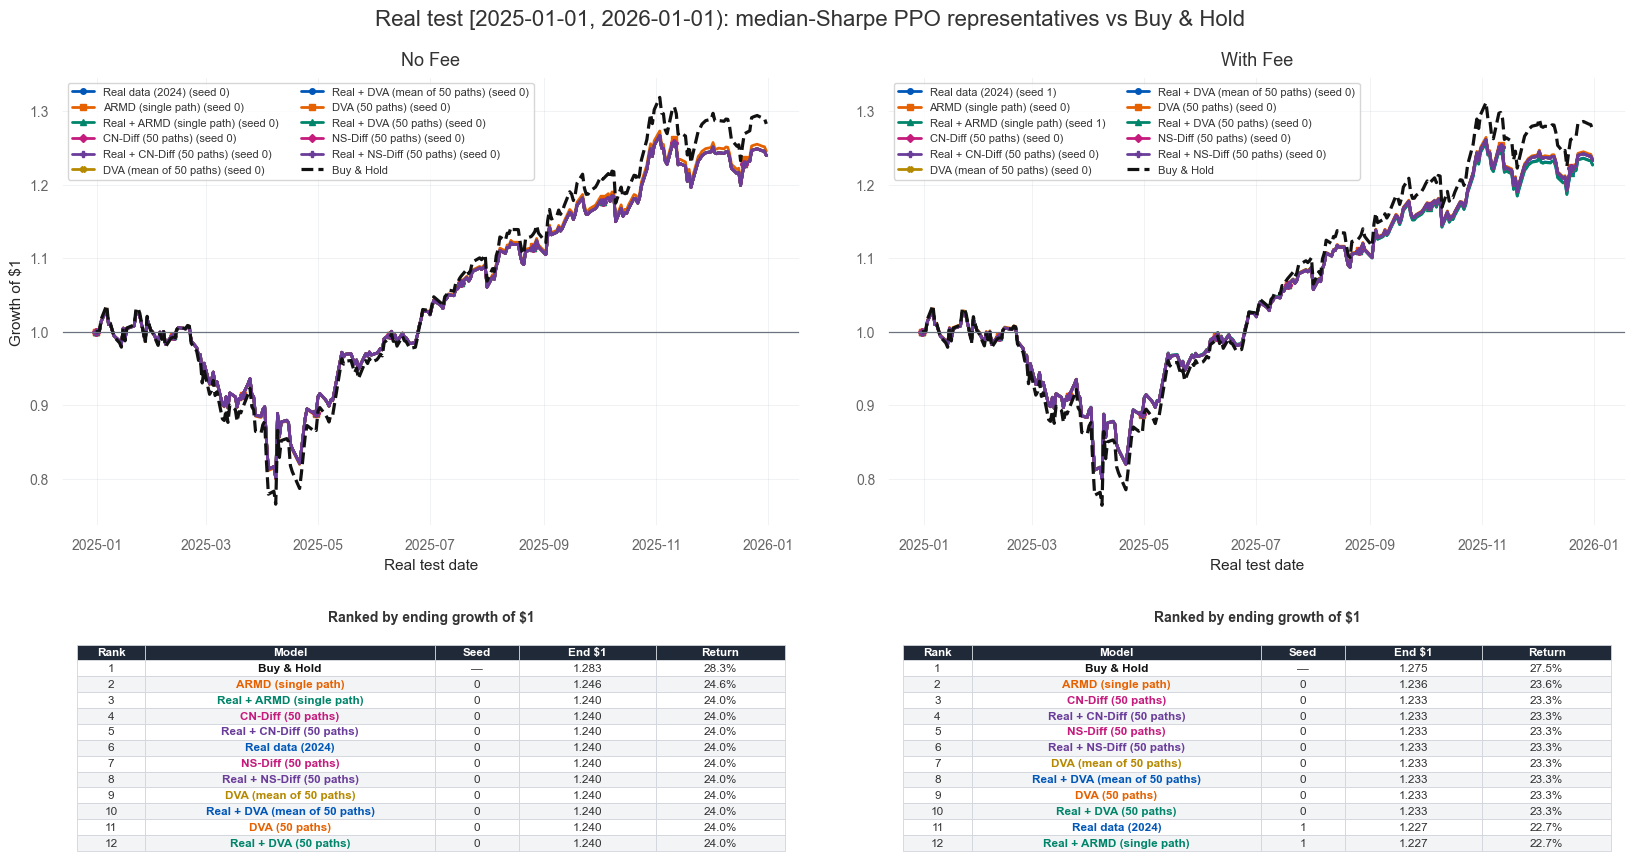

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/median_sharpe_ppo_vs_buy_and_hold_test_equity_curves.png


In [14]:
PERIOD_TITLES = {
    "train": f"Real train [{TRAIN_START}, {TRAIN_END})",
    "validation": f"Real validation [{VAL_START}, {VAL_END})",
    "test": f"Real test [{TEST_START}, {TEST_END})",
}
figure_paths = {}

for period in REAL_BACKTEST_PERIODS:
    fig = plt.figure(figsize=(17, 9))
    grid = fig.add_gridspec(
        2,
        len(COMMISSION_CONFIGS),
        height_ratios=(3.4, 1.7),
        hspace=0.30,
        wspace=0.12,
    )
    plot_axes = []
    table_axes = []
    for column_index in range(len(COMMISSION_CONFIGS)):
        shared_axis = plot_axes[0] if plot_axes else None
        plot_axes.append(
            fig.add_subplot(grid[0, column_index], sharey=shared_axis)
        )
        table_axes.append(fig.add_subplot(grid[1, column_index]))

    for axis, table_axis, commission_name in zip(
        plot_axes, table_axes, COMMISSION_CONFIGS
    ):
        subset = equity_curves.loc[
            (equity_curves["period"] == period)
            & (equity_curves["commission_name"] == commission_name)
        ]
        ranking_rows = []
        for group, label in GROUP_LABELS.items():
            selection = representative_test_runs.loc[
                (representative_test_runs["group"] == group)
                & (representative_test_runs["commission_name"] == commission_name)
            ].iloc[0]
            selected_seed = int(selection["seed"])
            group_data = subset.loc[
                (subset["group"] == group)
                & (pd.to_numeric(subset["seed"]) == selected_seed)
            ].sort_values("date")
            if group_data.empty:
                raise ValueError(
                    f"Missing {period} equity curve for {group}, "
                    f"{commission_name}, seed {selected_seed}"
                )
            compact_label = label.replace("PPO — ", "").replace(
                "synthetic ", ""
            )
            axis.plot(
                group_data["date"],
                group_data["growth_of_one"],
                color=AGENT_COLORS[group],
                linewidth=2.0,
                marker=AGENT_MARKERS[group],
                markevery=max(len(group_data) // 9, 1),
                markersize=4,
                label=f"{compact_label} (seed {selected_seed})",
            )
            ending_growth = float(group_data["growth_of_one"].iloc[-1])
            ranking_rows.append(
                {
                    "group": group,
                    "model": compact_label,
                    "seed": str(selected_seed),
                    "ending_growth": ending_growth,
                }
            )
        benchmark = (
            subset.loc[subset["group"] == "buy_and_hold"]
            .sort_values("date")
        )
        if benchmark.empty:
            raise ValueError(
                f"Missing {period} Buy & Hold curve for {commission_name}"
            )
        axis.plot(
            benchmark["date"],
            benchmark["growth_of_one"],
            color=AGENT_COLORS["buy_and_hold"],
            linestyle="--",
            linewidth=2.3,
            label="Buy & Hold",
        )
        ranking_rows.append(
            {
                "group": "buy_and_hold",
                "model": "Buy & Hold",
                "seed": "—",
                "ending_growth": float(benchmark["growth_of_one"].iloc[-1]),
            }
        )

        ranking = (
            pd.DataFrame(ranking_rows)
            .sort_values(
                ["ending_growth", "model"],
                ascending=[False, True],
                kind="mergesort",
            )
            .reset_index(drop=True)
        )
        ranking.insert(0, "rank", np.arange(1, len(ranking) + 1))
        ranking["return"] = ranking["ending_growth"] - 1.0

        axis.axhline(1.0, color="#6B7280", linewidth=0.9)
        axis.set_title(
            commission_name.replace("_", " ").title(), fontsize=13, pad=8
        )
        axis.set_xlabel(f"Real {period} date", fontsize=11)
        axis.tick_params(axis="both", labelsize=10)
        axis.grid(alpha=0.2, color="#9CA3AF")
        axis.legend(fontsize=8, ncol=2, loc="best")

        table_axis.axis("off")
        table_axis.set_title(
            "Ranked by ending growth of $1", fontsize=10, fontweight="semibold", pad=4
        )
        cell_text = [
            [
                int(row["rank"]),
                row["model"],
                row["seed"],
                f"{row['ending_growth']:.3f}",
                f"{row['return']:.1%}",
            ]
            for _, row in ranking.iterrows()
        ]
        rank_table = table_axis.table(
            cellText=cell_text,
            colLabels=["Rank", "Model", "Seed", "End $1", "Return"],
            cellLoc="center",
            colLoc="center",
            colWidths=[0.09, 0.38, 0.11, 0.18, 0.17],
            bbox=[0.02, 0.00, 0.96, 0.92],
        )
        rank_table.auto_set_font_size(False)
        rank_table.set_fontsize(8.5)
        for (row_number, column_number), cell in rank_table.get_celld().items():
            cell.set_edgecolor("#D1D5DB")
            cell.set_linewidth(0.6)
            if row_number == 0:
                cell.set_facecolor("#1F2937")
                cell.get_text().set_color("white")
                cell.get_text().set_weight("bold")
            elif row_number % 2 == 0:
                cell.set_facecolor("#F3F4F6")
        for row_number, group in enumerate(ranking["group"], start=1):
            model_text = rank_table[(row_number, 1)].get_text()
            model_text.set_color(AGENT_COLORS[group])
            model_text.set_weight("bold")

    plot_axes[0].set_ylabel("Growth of $1", fontsize=11)
    fig.suptitle(
        f"{PERIOD_TITLES[period]}: median-Sharpe PPO representatives vs Buy & Hold",
        fontsize=16,
        y=0.985,
    )
    fig.subplots_adjust(top=0.91, bottom=0.05, left=0.06, right=0.98)
    figure_path = (
        EXPERIMENT_ROOT
        / f"median_sharpe_ppo_vs_buy_and_hold_{period}_equity_curves.png"
    )
    fig.savefig(figure_path, dpi=160, bbox_inches="tight")
    figure_paths[period] = figure_path
    plt.show()
    print("saved:", figure_path)


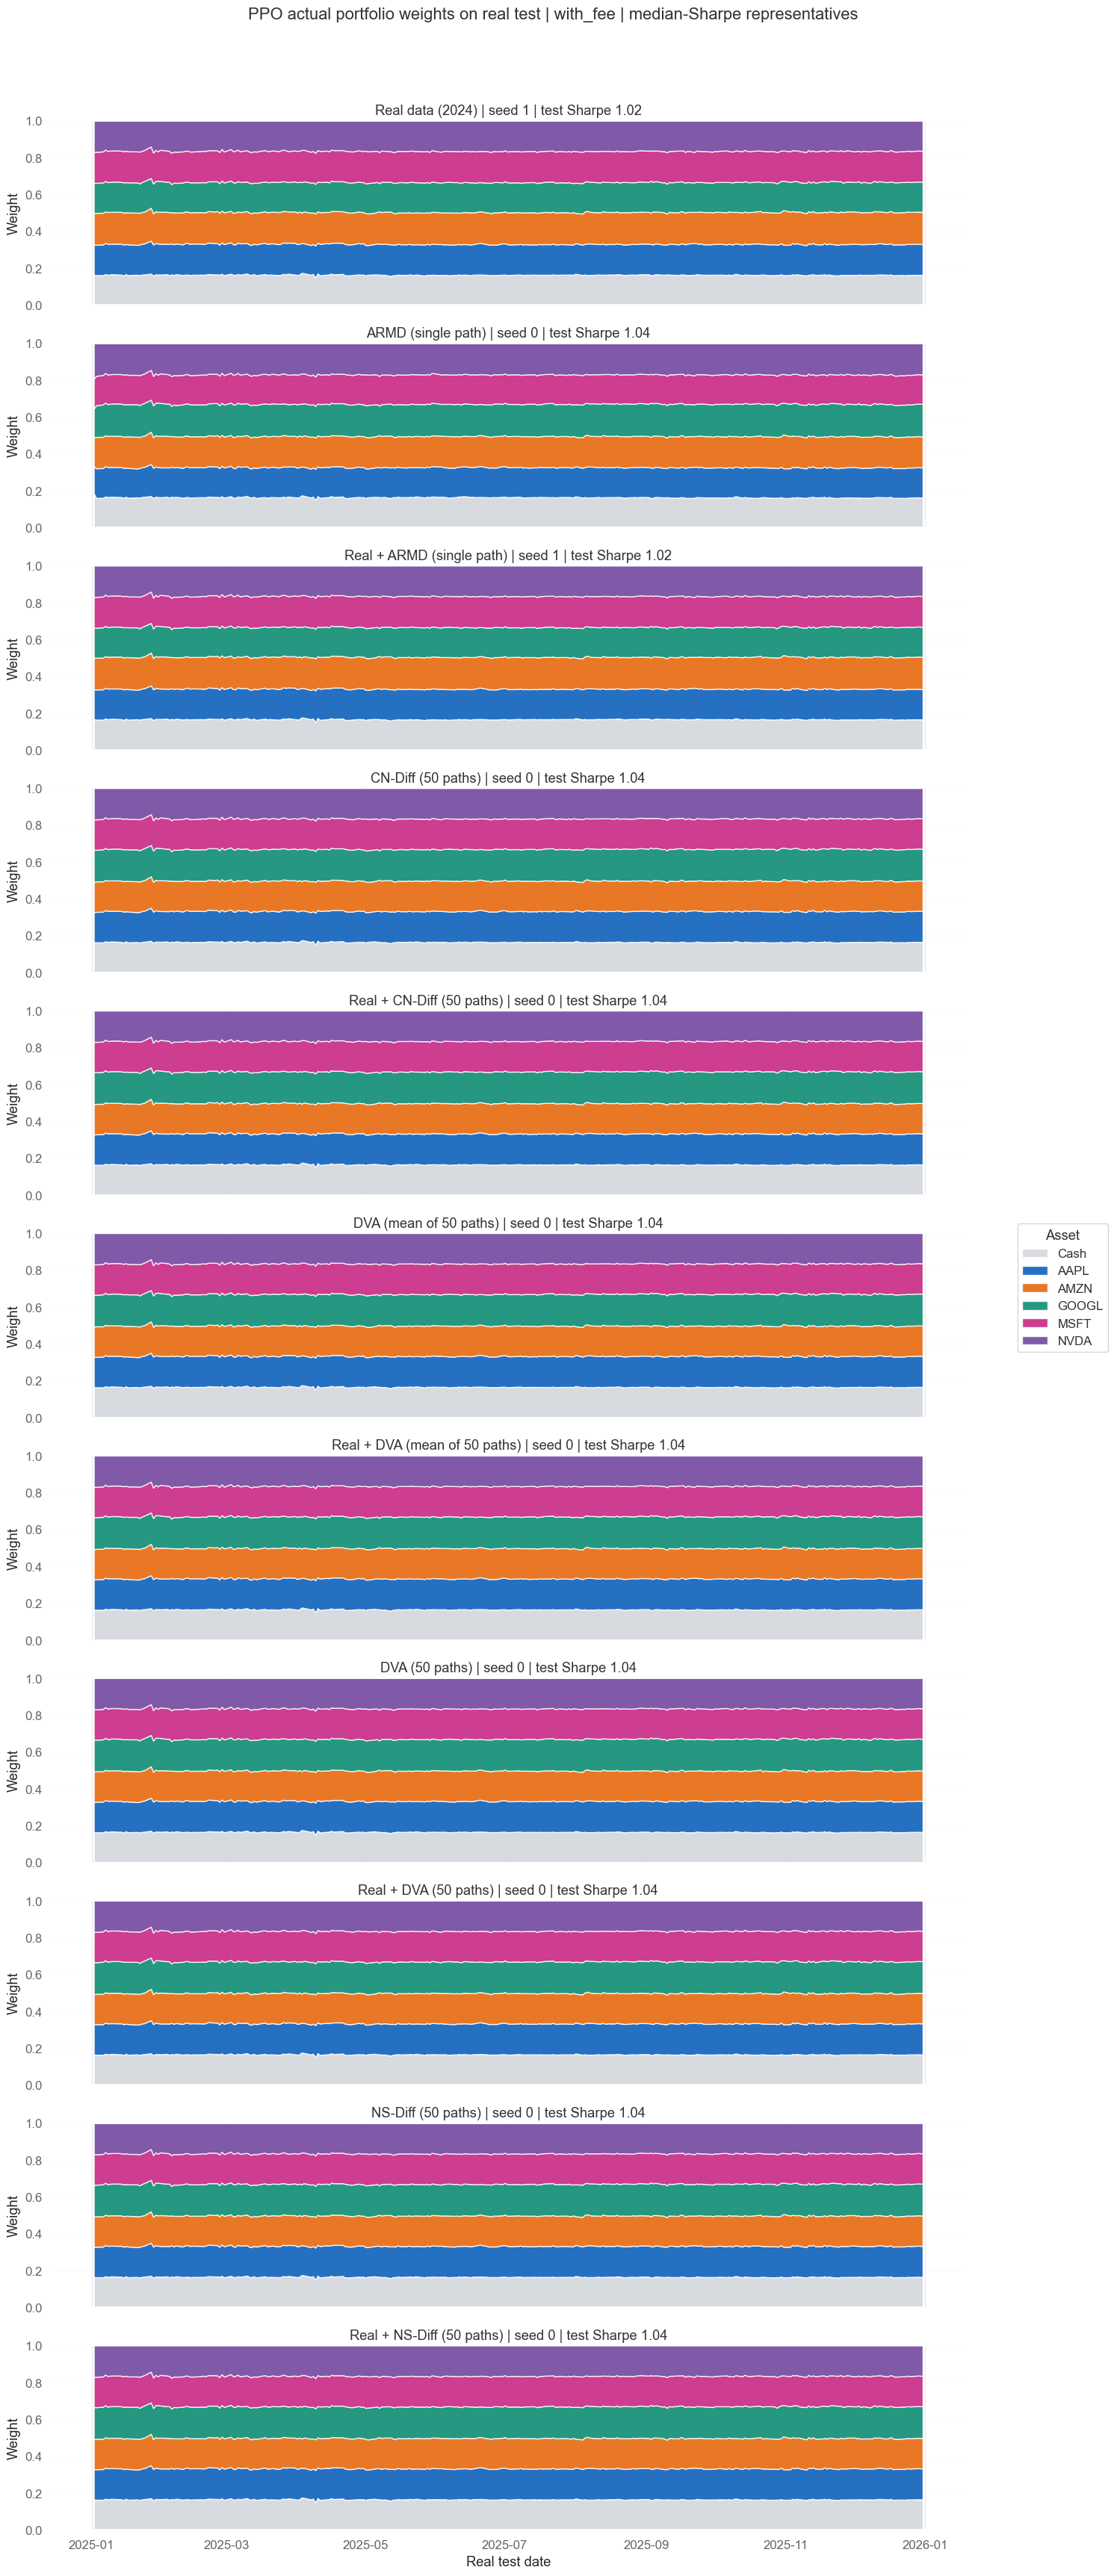

saved: /Users/chuanwei/Files/Projects/nycu_fintech/FinRL_Exp/results/ppo_synthetic_vs_real/smoke/32fc6838ca1d/median_sharpe_ppo_real_test_portfolio_weights_with_fee.png


In [15]:
# Compare actual end-of-day weights for every PPO training source on real test data.
WEIGHT_COMMISSION_NAME = "with_fee"
if WEIGHT_COMMISSION_NAME not in COMMISSION_CONFIGS:
    raise ValueError(f"Unknown commission setting: {WEIGHT_COMMISSION_NAME}")

weight_colors = [
    "#D1D5DB",  # cash
    "#0057B8",
    "#E66100",
    "#00856A",
    "#C51B7D",
    "#6A3D9A",
]
fig, axes = plt.subplots(
    len(TRAINING_GROUPS),
    1,
    figsize=(15, max(4, 3.2 * len(TRAINING_GROUPS))),
    sharex=True,
    sharey=True,
    squeeze=False,
)

weight_labels = None
for axis, group in zip(axes.ravel(), TRAINING_GROUPS):
    representative = representative_test_runs.loc[
        (representative_test_runs["group"] == group)
        & (
            representative_test_runs["commission_name"]
            == WEIGHT_COMMISSION_NAME
        )
    ].iloc[0]
    selected_seed = int(representative["seed"])
    record = next(
        (
            item
            for item in run_records
            if item["group"] == group
            and item["commission_name"] == WEIGHT_COMMISSION_NAME
            and int(item["seed"]) == selected_seed
        ),
        None,
    )
    if record is None:
        raise RuntimeError(
            f"No completed run for {group}, {WEIGHT_COMMISSION_NAME}, seed {selected_seed}"
        )

    model_name = model_from_group(group)
    test_frame = (
        real_pipeline["real_test"]
        if group == "real_trained"
        else synthetic_pipelines[model_name]["real_test"]
    )
    model = PPO.load(record["best_model_path"], device=DEVICE)
    environment = PortfolioOptimizationGymnasiumEnv(
        test_frame,
        **env_kwargs(float(record["commission"])),
    )
    observation, _ = environment.reset(seed=selected_seed)
    done = False
    while not done:
        action, _ = model.predict(observation, deterministic=True)
        observation, _, terminated, truncated, _ = environment.step(action)
        done = terminated or truncated

    weight_dates = pd.to_datetime(environment._date_memory[1:])
    actual_weights = np.asarray(environment._final_weights[1:], dtype=float)
    labels = ["Cash", *environment._tic_list.tolist()]
    if weight_labels is None:
        weight_labels = labels
    elif labels != weight_labels:
        raise ValueError(f"Asset order differs across training groups: {labels}")
    if not np.allclose(actual_weights.sum(axis=1), 1.0, atol=1e-6):
        raise ValueError(f"Portfolio weights do not sum to one for {group}")

    axis.stackplot(
        weight_dates,
        actual_weights.T,
        labels=labels,
        colors=weight_colors,
        alpha=0.85,
    )
    axis.set_title(
        f"{GROUP_LABELS[group]} | seed {selected_seed} | "
        f"test Sharpe {representative['sharpe']:.2f}"
    )
    axis.set_ylabel("Weight")
    axis.set_ylim(0, 1)
    axis.grid(axis="y", alpha=0.2)

axes.ravel()[-1].set_xlabel("Real test date")
handles, labels = axes.ravel()[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Asset", loc="center right")
fig.suptitle(
    "PPO actual portfolio weights on real test "
    f"| {WEIGHT_COMMISSION_NAME} | median-Sharpe representatives"
)
fig.tight_layout(rect=(0, 0, 0.88, 0.96))
weight_figure_path = EXPERIMENT_ROOT / (
    f"median_sharpe_ppo_real_test_portfolio_weights_{WEIGHT_COMMISSION_NAME}.png"
)
fig.savefig(weight_figure_path, dpi=160, bbox_inches="tight")
plt.show()
print("saved:", weight_figure_path)

## 10. Interpretation checklist

Before claiming that a generation model helps:

- Treat median-Sharpe representative plots as descriptive; inspect the seed-selection
  chart and exported all-seed CSVs before making robustness claims.
- Compare each model's paired delta against the real control for the same seed and fee.
- Require any advantage to appear across seeds, not only in one representative run.
- Check whether return improvements come with worse drawdown or turnover.
- Compare each model's synthetic-validation and real-validation curves for
  distribution mismatch.
- Treat smoke-mode numbers only as an execution check.

A positive synthetic-validation score alone is not evidence of real-market transfer;
the common real test is the controlling result.


## Next steps

- Keep one adjusted OHLCV CSV per ticker under `data/real/`.
- Add real 2025 rows before running the configured test period.
- Put each generated dataset under
  `data/synthetic/<dataset_slug>/path*.csv` and add its display label to
  `SYNTHETIC_MODEL_LABELS`.
- Run once in smoke mode and review model discovery, data, and scaling summaries.
- Confirm repeated runs report `training cache hit`; use
  `FINRL_FORCE_RETRAIN=1` only when a deliberate rebuild is required.
- Set `RUN_MODE="full"` and execute all cells for the formal comparison.
